# Human PD/AD Brain Analysis
## Dataset: Ping et al Nature, 2018
### Alex Maropakis

In [324]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy as sp
import re
from collections import Counter
from copy import deepcopy
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator
import os
import ast
from scipy.odr import Model, RealData, ODR
from scipy.stats import (
    gaussian_kde,
    ttest_ind,
    fisher_exact,
    kruskal,
    mannwhitneyu
)
from matplotlib import gridspec
from matplotlib_venn import venn3
import zipfile
from glob import glob
import gzip
import tarfile
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.patches as mpatches
from itertools import combinations
import pingouin as pg

print("packages have been successfully read in!")

packages have been successfully read in!


In [325]:
#Setting directories and reading in data 
#Reflect output from AAS pipeline (proj_dir), output folder (aa_subs_dir), and sample map for each sample 

print("loading directories...")
CODE_DIR        = '/Users/alexmaropakis/Projects/BrainDecode/'
PROJ_DIR        = '/Users/alexmaropakis/Projects/Project_BrainDecode/'
INDIR           = PROJ_DIR + 'Analysis_Inputs/Ping_2018/'
OUTDIR          = CODE_DIR + 'Dependencies/Analysis_Outputs/Ping_2018/'
DEPDIR          = CODE_DIR + 'Dependencies/Ping_2018/'
MQ_DIR          = PROJ_DIR + 'mq_output/Ping_2018/'
PLOT_DIR        = PROJ_DIR + 'Plots/Ping_2018/'
SAMPLE_MAPS_DIR = CODE_DIR + 'Dependencies/Sample_maps/'

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## ANTERIOR CINGULATE GYRUS 
# B1 
acgb1_proj_dir      = OUTDIR + 'acg/b1/'
acgb1_aa_subs_dir   = INDIR + 'acg/b1/'
acgb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb1.xlsx')
acgb1_samples       = ['S'+str(i) for i in list(set(acgb1_sample_map['TMT plex']))]
acgb1_mq            = MQ_DIR + 'acg/b1/'

# B2 
acgb2_proj_dir      = OUTDIR + 'acg/b2/'
acgb2_aa_subs_dir   = INDIR + 'acg/b2/'
acgb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb2.xlsx')
acgb2_samples       = ['S'+str(i) for i in list(set(acgb2_sample_map['TMT plex']))]
acgb2_mq            = MQ_DIR + 'acg/b2/'

# B3 
acgb3_proj_dir      = OUTDIR + 'acg/b3/'
acgb3_aa_subs_dir   = INDIR + 'acg/b3/'
acgb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb3.xlsx')
acgb3_samples       = ['S'+str(i) for i in list(set(acgb3_sample_map['TMT plex']))]
acgb3_mq            = MQ_DIR + 'acg/b3/'

# B4 
acgb4_proj_dir      = OUTDIR + 'acg/b4/'
acgb4_aa_subs_dir   = INDIR + 'acg/b4/'
acgb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb4.xlsx')
acgb4_samples       = ['S'+str(i) for i in list(set(acgb4_sample_map['TMT plex']))]
acgb4_mq            = MQ_DIR + 'acg/b4/'

# B5 
acgb5_proj_dir      = OUTDIR + 'acg/b5/'
acgb5_aa_subs_dir   = INDIR + 'acg/b5/'
acgb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_acgb5.xlsx')
acgb5_samples       = ['S'+str(i) for i in list(set(acgb5_sample_map['TMT plex']))]
acgb5_mq            = MQ_DIR + 'acg/b5/'


## FRONTAL CORTEX 
# B1 
# fcb1_proj_dir      = OUTDIR + 'fc/b1/'
# fcb1_aa_subs_dir   = INDIR + 'fc/b1/'
# fcb1_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb1.xlsx')
# fcb1_samples       = ['S'+str(i) for i in list(set(fcb1_sample_map['TMT plex']))]
# fcb1_mq            = MQ_DIR + 'fc/b1/'

# B2 
fcb2_proj_dir      = OUTDIR + 'fc/b2/'
fcb2_aa_subs_dir   = INDIR + 'fc/b2/'
fcb2_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb2.xlsx')
fcb2_samples       = ['S'+str(i) for i in list(set(fcb2_sample_map['TMT plex']))]
fcb2_mq            = MQ_DIR + 'fc/b2/'

# B3 
fcb3_proj_dir      = OUTDIR + 'fc/b3/'
fcb3_aa_subs_dir   = INDIR + 'fc/b3/'
fcb3_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb3.xlsx')
fcb3_samples       = ['S'+str(i) for i in list(set(fcb3_sample_map['TMT plex']))]
fcb3_mq            = MQ_DIR + 'fc/b3/'

# B4 
fcb4_proj_dir      = OUTDIR + 'fc/b4/'
fcb4_aa_subs_dir   = INDIR + 'fc/b4/'
fcb4_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb4.xlsx')
fcb4_samples       = ['S'+str(i) for i in list(set(fcb4_sample_map['TMT plex']))]
fcb4_mq            = MQ_DIR + 'fc/b4/'

# B5 
fcb5_proj_dir      = OUTDIR + 'fc/b5/'
fcb5_aa_subs_dir   = INDIR + 'fc/b5/'
fcb5_sample_map    = pd.read_excel(SAMPLE_MAPS_DIR + 'sample_map_fcb5.xlsx')
fcb5_samples       = ['S'+str(i) for i in list(set(fcb5_sample_map['TMT plex']))]
fcb5_mq            = MQ_DIR + 'fc/b5/'


#lists to quickly index dataset-specific sample maps from just the dataset name
datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5', 'fcb2', 'fcb3', 'fcb4', 'fcb5']
acg_datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5']
fc_datasets = ['fcb2','fcb3','fcb4','fcb5']

data_dir_list = [acgb1_aa_subs_dir, acgb2_aa_subs_dir, acgb3_aa_subs_dir, acgb4_aa_subs_dir, acgb5_aa_subs_dir, fcb2_aa_subs_dir, fcb3_aa_subs_dir, fcb4_aa_subs_dir, fcb5_aa_subs_dir]
proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]
acg_proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir]
fc_proj_dir_list = [fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]

samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]
sample_map_list = [acgb1_sample_map, acgb2_sample_map, acgb3_sample_map, acgb4_sample_map, acgb5_sample_map, fcb2_sample_map, fcb3_sample_map, fcb4_sample_map, fcb5_sample_map]
acg_samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples]
fc_samples_list = [fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]

mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]
acg_mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq]
fc_mq_dir_list = [fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]



### fcb1 commented out 
# datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5', 'fcb1', 'fcb2', 'fcb3', 'fcb4', 'fcb5']
# acg_datasets = ['acgb1', 'acgb2', 'acgb3', 'acgb4', 'acgb5']
# fc_datasets = ['fcb1','fcb2','fcb3','fcb4','fcb5']

# data_dir_list = [acgb1_aa_subs_dir, acgb2_aa_subs_dir, acgb3_aa_subs_dir, acgb4_aa_subs_dir, acgb5_aa_subs_dir, fcb1_aa_subs_dir, fcb2_aa_subs_dir, fcb3_aa_subs_dir, fcb4_aa_subs_dir, fcb5_aa_subs_dir]
# proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir, fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]
# acg_proj_dir_list = [acgb1_proj_dir, acgb2_proj_dir, acgb3_proj_dir, acgb4_proj_dir, acgb5_proj_dir]
# fc_proj_dir_list = [fcb1_proj_dir, fcb2_proj_dir, fcb3_proj_dir, fcb4_proj_dir, fcb5_proj_dir]

# samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples, fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]
# sample_map_list = [acgb1_sample_map, acgb2_sample_map, acgb3_sample_map, acgb4_sample_map, acgb5_sample_map, fcb1_sample_map, fcb2_sample_map, fcb3_sample_map, fcb4_sample_map, fcb5_sample_map]
# acg_samples_list = [acgb1_samples, acgb2_samples, acgb3_samples, acgb4_samples, acgb5_samples]
# fc_samples_list = [fcb1_samples, fcb2_samples, fcb3_samples, fcb4_samples, fcb5_samples]

# mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq, fcb1_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]
# acg_mq_dir_list = [acgb1_mq, acgb2_mq, acgb3_mq, acgb4_mq, acgb5_mq]
# fc_mq_dir_list = [fcb1_mq, fcb2_mq, fcb3_mq, fcb4_mq, fcb5_mq]

print("directories loaded successfully!")

loading directories...
directories loaded successfully!


In [361]:
""" 
Read in data generated from dependencies code
if dependencies have not been generated, go back and generate
""" 

pos_prob_df_acg = pd.read_csv(DEPDIR+'acg/Position_probability_fragment_ion_data.csv')
pos_prob_df_fc = pd.read_csv(DEPDIR+'fc/Position_probability_fragment_ion_data.csv')
pos_prob_df = pd.concat([pos_prob_df_acg, pos_prob_df_fc])

frag_dict_acg = pickle.load(open(DEPDIR+'acg/Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
# print(frag_dict_acg)
frag_dict_fc = pickle.load(open(DEPDIR+'fc/Fragment_ion_dict.p', 'rb')) ### keys of frag_dict refer to the index in pos_prob_df
# print(frag_dict_fc)
frag_dict = {
    'acg': frag_dict_acg,
    'fc': frag_dict_fc}

SAAP_quant_df_acg = pd.read_excel(DEPDIR+'acg/SAAP_precursor_reporter_quant.xlsx')
SAAP_quant_df_acg = SAAP_quant_df_acg[SAAP_quant_df_acg['Sample Type'] != 'Unknown']
SAAP_quant_df_acg_list = [SAAP_quant_df_acg.loc[SAAP_quant_df_acg['Dataset']==ds] for ds in datasets]
SAAP_quant_df_fc = pd.read_excel(DEPDIR+'fc/SAAP_precursor_reporter_quant.xlsx')
SAAP_quant_df_fc = SAAP_quant_df_fc[SAAP_quant_df_fc['Sample Type'] != 'Unknown']

SAAP_quant_df_fc_list = [SAAP_quant_df_fc.loc[SAAP_quant_df_fc['Dataset']==ds] for ds in datasets]
SAAP_quant_df_list = [SAAP_quant_df_acg, SAAP_quant_df_fc]
SAAP_quant_df = pd.concat([SAAP_quant_df_acg, SAAP_quant_df_fc])
SAAP_quant_df = SAAP_quant_df[SAAP_quant_df['Sample Type'] != 'Unknown'] # filter out GIS
print(SAAP_quant_df)

ds_metrics_acg = pd.read_excel(DEPDIR+'acg/dataset_metrics.xlsx')
ds_metrics_fc = pd.read_excel(DEPDIR+'fc/dataset_metrics.xlsx')
ds_metrics = pd.concat([ds_metrics_acg, ds_metrics_fc])
# print(ds_metrics)

frag_df_acg = pd.read_excel(DEPDIR+'acg/fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df_fc = pd.read_excel(DEPDIR+'fc/fragments_per_saap_4barplot_allDS.xlsx', index_col=0)
frag_df = pd.concat([frag_df_acg,frag_df_fc])

      Row Number Dataset           MTP_seq            BP_seq  aa_sub tmt_set  \
0              0   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
1              1   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
2              2   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
3              3   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
5              5   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
...          ...     ...               ...               ...     ...     ...   
3010        3010    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3011        3011    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3012        3012    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3013        3013    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3014        3014    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   

      Positional_probability  SAAP_PEP 

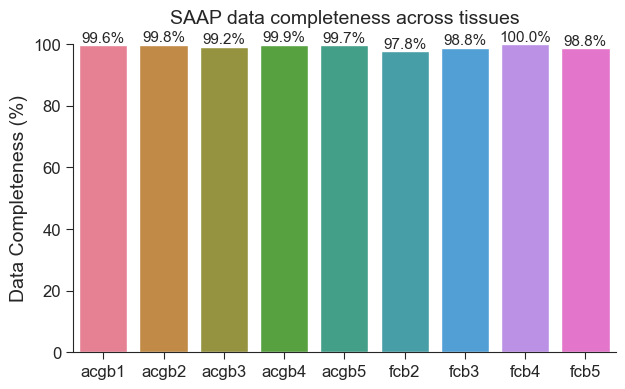

In [327]:
# plot original weighted SAAP data completeness per tissue
comp_cols=[
'Positional_probability',
'SAAP_PEP',
'BP_PEP',
'MTP_PrecInt',
'BP_PrecInt',
'Prec_RAAS',
'MTP_ReportInt',
'BP_ReportInt',
'Reporter_RAAS',
'BP_ReportInt_Norm',
'MTP_ReportInt_Norm'
]

comp_df=SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df=comp_df[comp_df['Dataset']==ds]
    total_values=len(ds_df)*len(comp_cols)
    nonmissing_values=sum(
        ds_df[c].notna().sum()
        for c in comp_cols
    )
    completeness=100*(nonmissing_values/total_values)
    plot_rows.append([ds,completeness])

plot_df=pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
fig,ax=plt.subplots(figsize=(7,4))
sns.barplot(data=plot_df,x='Dataset',y='Completeness',hue='Dataset',palette='husl',legend=False)
sns.despine()
ax.tick_params('both',labelsize=12)
plt.xlabel('')
plt.ylabel('Data Completeness (%)',fontsize=14)
plt.ylim(0,100)
plt.title('SAAP data completeness across tissues',fontsize=14,pad=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=11)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'SAAP_original_weighted_data_completeness_by_tissue.pdf', bbox_inches='tight')

In [328]:
# retain only SAAP observations with 100% data completeness across all columns
SAAP_quant_complete_df=SAAP_quant_df.dropna()
print(f'{len(SAAP_quant_complete_df):,} fully complete SAAP observations retained')
print(f'{100*(len(SAAP_quant_complete_df)/len(SAAP_quant_df)):.2f}% dataset completeness')
SAAP_quant_df = SAAP_quant_complete_df # replace read-in SAAP_quant_df with filtered version with complete data for downstream analyses

## if wanting SAAP_quant_df with missing values, skip this step and use original SAAP_quant_df read in from file above
# SAAP_quant_df = pd.read_excel(DEPDIR+'SAAP_precursor_reporter_quant_data.xlsx', index_col=0)
# #SAAP_precursor_reporter_quant_data.xlsx contains both precursor and reporter ion data for validated SAAPs
# print(SAAP_quant_df)
# SAAP_quant_df_grouped_grouped_list = [SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds] for ds in datasets]

9,465 fully complete SAAP observations retained
97.14% dataset completeness


# Helper Functions

## Data Processing

In [329]:
def get_filter_df(data_dir, samples):
    """ 
    function that reads in output from decode pipeline to get number of peptides in each category
    Input: directory with output files for dataset, dataset samples/TMT set names
    output: dataframe with the number of peptides in each category
    """
    dp_ev_dict = pickle.load(open(data_dir+'DP_search_evidence_dict.p', 'rb'))
    dp_dict = pickle.load(open(data_dir+'DP_dict.p', 'rb'))
    mtp_dict = pickle.load(open(data_dir+'MTP_dict.p', 'rb'))
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb')) # dictionary of putative substitutions that pass FDR correction
    substr_dict = pickle.load(open(data_dir+'genome_substr_dict.p', 'rb'))
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p','rb'))
    
    rows = []
    for s in samples:
        seqs = [[x for y in list(mtp_dict[s]['mistranslated sequence'].values()) for x in y] for s in samples]
        seqs = [x for y in seqs for x in y]
        if 'all_6frame_seqs' in substr_dict.keys():
            homolog_seqs = substr_dict['all_6frame_seqs']
        else:
            homolog_seqs = substr_dict['all_frame6_seqs']
        seqs_hom = [x for x in seqs if x in homolog_seqs]
        
        n_main = len(dp_ev_dict[s]['Raw file'])
        n_dp = len(dp_dict[s]['Raw file'])
        n_ptm = len(ptm_dict[s]['Raw file'])
        n_aas = len(mtp_dict[s]['Raw file'])
        n_nohom = len([i for i,x in mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_hc = len([i for i,x in hc_mtp_dict[s]['mistranslated sequence'].items() if all(y not in seqs_hom for y in x)])
        n_val = len(val_mtp_dict[s]['Raw file'])

        rows.append([s, n_main, n_dp, n_ptm, n_aas, n_nohom, n_hc, n_val])
    df = pd.DataFrame(rows, columns=['TMT set', 'Main peptides', 'DP', 'PTM', 'AAS', 'Non-homologous', 'High-confidence', 'Validated'])

    return(df)

In [330]:
# plotting PTMs found
def get_ptm_df(ptm_dict, ds):
    """
    function to get a dataframe of PTMS x datasets from the datasets' PTM_dict.p
    """
    master_ptm_list = []
    for s,v in ptm_dict.items():
        s_ptm_dict = v['PTM']
        for ptm_list in s_ptm_dict.values():
            new_ptm_list = [x for x in ptm_list if x not in master_ptm_list]
            new_ptm_list = list(set(new_ptm_list))
            master_ptm_list = master_ptm_list + new_ptm_list

    heatmap_df = pd.DataFrame(index=master_ptm_list, columns=list(range(1,24)))
    for s, v in ptm_dict.items():
        if ds !='Healthy':
            s_int = int(s[1:])
        else:
            s_int=s
        ptm_list = list(v['PTM'].values())
        ptm_list = [x for y in ptm_list for x in y]
        ptm_count = Counter(ptm_list)
        for ptm, count in ptm_count.items():
            heatmap_df.loc[ptm, s_int] = count
            #heatmap_df.loc[ptm, s_int] = np.log10(count)
    heatmap_df.fillna(0, inplace=True)
    return(heatmap_df)

In [331]:
# functions to get number of unique candidate substituted peptides and number of unique validated substituted peptides for each sample in each dataset
def get_n_unq_seqs(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique candidate substituted peptides
    """
    hc_mtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    s_seqs = [x for y in hc_mtp_dict[s]['mistranslated sequence'].values() for x in y]
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

def get_n_unq_val(data_dir, s):
    """ input: dataset directory, sample
        output: number of unique validated substituted peptides
    """
    val_mtp_dict = pickle.load(open(data_dir+'Ion_validated_MTP_dict.p', 'rb'))
    s_seqs = list(val_mtp_dict[s]['mistranslated sequence'].values())
    s_seqs = list(set(s_seqs))
    n_seqs = len(s_seqs)
    return(n_seqs)

In [332]:
# functions to process data for substitution-level analysis 
raas_col = 'Reporter_RAAS' # tmt level RAAS column to use for grouping
disease_order = ['CTRL', 'AD', 'PD', 'ADPD'] # 4 groups
patient = SAAP_quant_df['Sample'].str.split('_').str[0]

aa_order = [ # amino acid ordering for standardized plotting
    'G', 'A', 'V', 'L', 'I', 'M', 'P',
    'F', 'Y', 'W',
    'S', 'T', 'C', 'N', 'Q',
    'D', 'E',
    'K', 'R', 'H'
]

def replicate_cols(df):
    # add replicate columns to dataframe based on TMT set and disease state
    saap_df = df.copy()
    saap_df['Disease'] = saap_df['Sample Type']
    saap_df['Tissue'] = saap_df['Dataset']
    saap_df['Patient'] = saap_df['Sample'].str.split('_').str[0]
    return saap_df

def top_sub_order(df, n=15):
    # get top n most frequent substituted amino acids for standardized plotting order
    return df['aa_sub'].value_counts().head(n).index

In [333]:
print(SAAP_quant_df)

      Row Number Dataset           MTP_seq            BP_seq  aa_sub tmt_set  \
0              0   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
1              1   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
2              2   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
3              3   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
5              5   acgb1  LLGMVLVCVLAHHFGK  LLGNVLVCVLAHHFGK  N to M      S1   
...          ...     ...               ...               ...     ...     ...   
3010        3010    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3011        3011    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3012        3012    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3013        3013    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   
3014        3014    fcb5       AGEGDATIHLK       AGEQDATIHLK  Q to G      S5   

      Positional_probability  SAAP_PEP 

## Figure Formatting & Plotting

In [334]:
# Functions for figure formatting for bidirectional histograms 
class GridShader():
    """
    function used to create alternating vertical gray and white background in plots
    """
    def __init__(self, ax, first=True, **kwargs):
        self.spans = []
        self.sf = first
        self.ax = ax
        self.kw = kwargs
        self.ax.autoscale(False, axis="x")
        self.cid = self.ax.callbacks.connect('xlim_changed', self.shade)
        self.shade()
    def clear(self):
        for span in self.spans:
            try:
                span.remove()
            except:
                pass
    def shade(self, evt=None):
        self.clear()
        xticks = self.ax.get_xticks()
        xlim = self.ax.get_xlim()
        xticks = xticks[(xticks > xlim[0]) & (xticks < xlim[-1])]
        locs = np.concatenate(([[xlim[0]], xticks, [xlim[-1]]]))

        start = [x-0.5 for x in locs[1-int(self.sf)::2]]
        end = [x-0.5 for x in locs[2-int(self.sf)::2]]

        for s, e in zip(start, end):
            self.spans.append(self.ax.axvspan(s, e, zorder=0, **self.kw))


def bihist(y1, y2, nbins=10, h=None):
    '''
    Function used to create violin plots as bihistograms with no smoothing.
    h is an axis handle. If not present, a new figure is created.
    '''
    if h is None: h = plt.figure().add_subplot(111)
    ymin = np.floor(np.minimum(min(y1), min(y2)))
    ymax = np.ceil(np.maximum(max(y1), max(y2)))
    bins = np.linspace(ymin, ymax, nbins)
    n1, bins1, patch1 = h.hist(y1, bins, orientation='horizontal', color='#aaaaaa', edgecolor=None, linewidth=0,rwidth=1)
    n2, bins2, patch2 = h.hist(y2, bins, orientation='horizontal', color='#aaaaaa', edgecolor=None, linewidth=0,rwidth=1)
    # set xmax:
    xmax = 0
    for i in patch1:
        i.set_edgecolor(None)
        width = i.get_width()
        if width > xmax: xmax = width
    # invert second histogram and set xmin:
    xmin = 0
    for i in patch2:
        i.set_edgecolor(None)
        width = i.get_width()
        width = -width
        i.set_width(width)
        if width < xmin: xmin = width
    h.set_xlim(xmin*1.1, xmax*1.1)          
    h.figure.canvas.draw()

## Statistics

In [335]:
def run_fdr(df, p_col='pval', out_col='FDR'):
    """Apply BH-FDR correction while preserving NaN p-values."""
    df[out_col] = np.nan
    valid_pvals = df[p_col].notna()

    if valid_pvals.any():
        df.loc[valid_pvals, out_col] = multipletests(
            df.loc[valid_pvals, p_col],
            method='fdr_bh'
        )[1]

    return df

def add_sig_label(p):
    if p < .001: return "***"
    if p < .01: return "**"
    if p < .05: return "*"
    return "ns"

# 1. SAAP Detection & QC

## Dataset Metrics

acgb1 10
acgb2 10
acgb3 10
acgb4 10
acgb5 10
fcb2 10
fcb3 10
fcb4 10
fcb5 10
90
acgb1


acgb2
acgb3
acgb4
acgb5
fcb2
fcb3
fcb4
fcb5
{'Main peptides': np.int64(925437), 'DP': np.int64(95887), 'PTM': np.int64(39582), 'AAS': np.int64(2309), 'Non-homologous': np.int64(2309), 'High-confidence': np.int64(2090), 'Validated': np.int64(1382)}


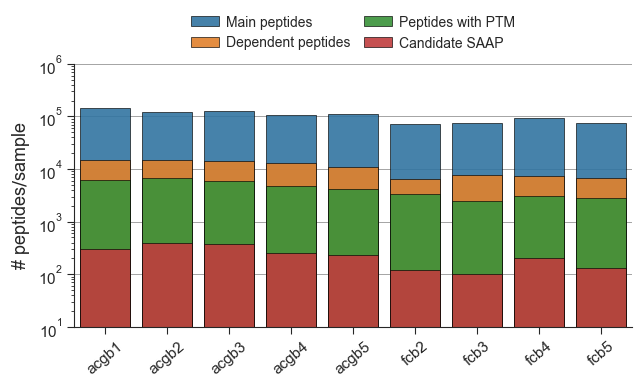

In [336]:
# N peptide IDs through filtering steps
# get number of samples in each dataset
n_samples_data = []
total = 0
for ds in datasets:
    sample_map = sample_map_list[datasets.index(ds)]
    samples = sample_map['sample_name'].values

    n_samples = len(samples)
    total += n_samples
    n_samples_data.append([ds, n_samples])
    print(ds, n_samples)
print(total)
n_samples_df = pd.DataFrame(n_samples_data, columns=['Dataset', 'N samples'])
n_samples_df.to_excel(OUTDIR+'N_samples_in_datasets.xlsx')

# create a dictionary containing the dataframes generated with the above function for each dataset
filter_dict = {}
for ds in datasets:
    print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    filter_dict[ds] = get_filter_df(data_dir, samples)

for ds in datasets:
    filter_dict[ds]['Dataset'] = [ds]*len(filter_dict[ds])
pickle.dump(filter_dict, open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'wb'))

#filter_dict = pickle.load(open(OUTDIR+'Modified_peptide_filter_dict_DP2valSAAP.p', 'rb'))
all_df = pd.concat([filter_dict[ds] for ds in datasets])

sum_dict = {}
for col in all_df.columns:
    if col not in ['TMT set', 'Dataset', 'Tissue']:
        sum_dict[col] = np.nansum(all_df[col].values)
        
print(sum_dict)

# filtering modified peptides to candidate SAAP
barplot_rows = []
for i, row in all_df.iterrows():
    barplot_rows.append([row['Dataset'], row['Main peptides'], 'Main peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['DP'], 'Dependent peptides', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['PTM'], 'Peptides with PTM', row['TMT set']])
    barplot_rows.append([row['Dataset'], row['High-confidence'], 'Candidate SAAP', row['TMT set']])

barplot_df = pd.DataFrame(barplot_rows, columns=['Dataset', 'N peptide IDs', 'Peptide type', 'TMT set'])

plt.figure(figsize=(6.5, 4))
sns.set_style(style='ticks')
ax = sns.barplot(
    data=barplot_df, 
    x='Dataset', 
    y='N peptide IDs', 
    hue='Peptide type', 
    dodge=False, 
    edgecolor='black', 
    linewidth=0.5, 
    alpha=0.9
)

ax.set_yscale('log')
ax.set_ylim([10, 1e6])
ax.set_ylabel('# peptides$/$sample', fontsize=13)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=40, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

ax.grid(True, axis='y', linestyle='solid', linewidth=0.5, color='gray')
ax.grid(False, axis='x')

handles, labels = ax.get_legend_handles_labels()
new_labels = ['Main peptides', 'Dependent peptides', 'Peptides with PTM', 'Candidate SAAP']
ax.legend(
    handles=handles,
    labels=new_labels,
    title='',
    bbox_to_anchor=(0.5, 1.12),
    loc='center',
    ncol=2,
    fontsize=10,
    handletextpad=0.5,
    columnspacing=1,
    frameon=False
)

plt.tight_layout()
plt.tick_params(axis='both', length=5)
sns.despine()
plt.savefig(PLOT_DIR + 'Dataset_filtering_barplot.pdf', bbox_inches='tight')
plt.show()

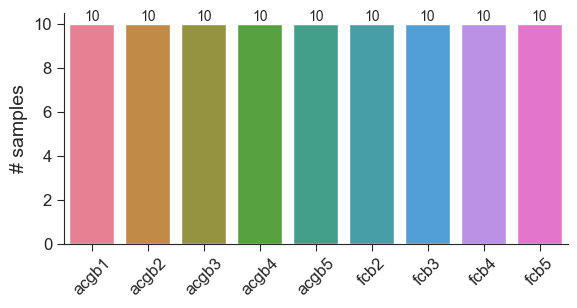

In [ ]:
# # N samples per dataset and Disease and plot 
# plot_rows = []
# plot_cols = ['Dataset', 'N samples', 'Sample type']
# for ds in datasets:
#     sample_map = sample_map_list[datasets.index(ds)]
#     n_t6_samples = len(sample_map.loc[sample_map['Group']=='t06mo'])
#     n_t15_samples = len(sample_map.loc[sample_map['Group']=='t15mo'])
#     n_t24_samples = len(sample_map.loc[sample_map['Group']=='t24mo'])
#     n_t30_samples = len(sample_map.loc[sample_map['Group']=='t30mo'])
#     plot_rows.append([ds, n_t6_samples, '6 months'])
#     plot_rows.append([ds, n_t15_samples, '15 months'])
#     plot_rows.append([ds, n_t24_samples, '24 months'])
#     plot_rows.append([ds, n_t30_samples, '30 months'])

# plot_df = pd.DataFrame(plot_rows, columns=plot_cols)
# sns.set_style('ticks')
# fig,ax = plt.subplots(figsize=(5,3))
# sns.barplot(data=plot_df, x='Dataset', y='N samples', hue='Sample type', palette=sns.color_palette(palette='Greys', n_colors=4))
# ax.tick_params('both', labelsize=12)
# plt.xlabel('')
# plt.ylabel('# samples', fontsize=14)
# plt.ylim([0,5])
# plt.tick_params(axis='both', length=5)
# plt.bar_label(plt.gca().containers[2])
# plt.legend(ncol=1, bbox_to_anchor=(1.04,1.15), frameon=False, fontsize=13, handletextpad=0.1)
# sns.despine()
# plt.savefig(PLOT_DIR+'HumanBrain_N_samples_per_dataset.pdf', bbox_inches='tight')

# N samples per dataset and plot 
plot_rows=[]
plot_cols=['Dataset','N samples']

for ds in datasets:
    sample_map=sample_map_list[datasets.index(ds)]
    n_samples=len(sample_map)

    plot_rows.append([ds,n_samples])

plot_df=pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')
fig,ax=plt.subplots(figsize=(6.5,3))

sns.barplot(
    data=plot_df,
    x='Dataset',
    y='N samples',
    hue='Dataset',
    palette='husl',
    legend=False)

ax.tick_params('both',labelsize=12)
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('# samples',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.savefig(PLOT_DIR+'HumanBrain_N_samples_per_dataset.pdf',bbox_inches='tight')

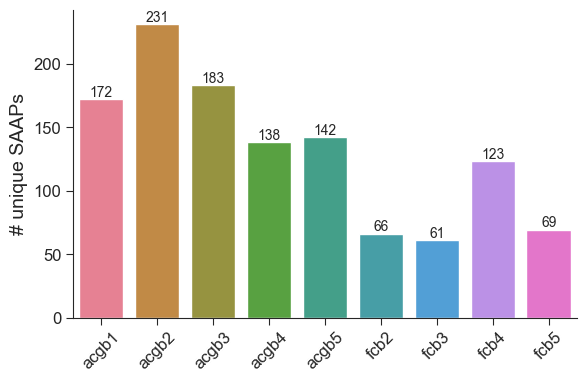

In [ ]:
# # N SAAPs per dataset and Disease and plot
# plot_rows=[]
# plot_cols=['Dataset','N SAAPs','Sample type']

# for ds in datasets:
#     ds_df=SAAP_quant_df[SAAP_quant_df['Dataset']==ds]

#     n_t6=ds_df.loc[ds_df['Sample Type']=='t06mo','MTP_seq'].nunique()
#     n_t15=ds_df.loc[ds_df['Sample Type']=='t15mo','MTP_seq'].nunique()
#     n_t24=ds_df.loc[ds_df['Sample Type']=='t24mo','MTP_seq'].nunique()
#     n_t30=ds_df.loc[ds_df['Sample Type']=='t30mo','MTP_seq'].nunique()

#     plot_rows.append([ds,n_t6,'6 months'])
#     plot_rows.append([ds,n_t15,'15 months'])
#     plot_rows.append([ds,n_t24,'24 months'])
#     plot_rows.append([ds,n_t30,'30 months'])

# plot_df=pd.DataFrame(plot_rows,columns=plot_cols)
# sns.set_style('ticks')
# fig,ax=plt.subplots(figsize=(4.5,4))
# sns.barplot(data=plot_df,x='Dataset',y='N SAAPs',hue='Sample type',palette=sns.color_palette(palette='Greys',n_colors=4))
# ax.tick_params('both',labelsize=12)
# plt.xlabel('')
# plt.ylabel('# unique SAAPs',fontsize=14)
# plt.bar_label(plt.gca().containers[2])
# plt.tick_params(axis='both', length=5)
# sns.despine()
# plt.legend(ncol=1,bbox_to_anchor=(1.04,1.15),frameon=False,fontsize=13,handletextpad=0.1)
# plt.savefig(PLOT_DIR+'HumanBrain_N_SAAPs_per_dataset.pdf',bbox_inches='tight')

# N SAAPs per dataset and plot
plot_rows=[]
plot_cols=['Dataset','N SAAPs']

for ds in datasets:
    ds_df=SAAP_quant_df[SAAP_quant_df['Dataset']==ds]

    n_saaps=ds_df['MTP_seq'].nunique()

    plot_rows.append([ds,n_saaps])

plot_df=pd.DataFrame(plot_rows,columns=plot_cols)
sns.set_style('ticks')
fig,ax=plt.subplots(figsize=(6.5,4))

sns.barplot(
    data=plot_df,
    x='Dataset',
    y='N SAAPs',
    hue='Dataset',
    palette='husl',
    legend=False)

ax.tick_params('both',labelsize=12)
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('# unique SAAPs',fontsize=14)
plt.tick_params(axis='both',length=5)

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.savefig(PLOT_DIR+'HumanBrain_N_SAAPs_per_dataset.pdf',bbox_inches='tight')

In [ ]:
# # N peptides detected per dataset and Disease from MaxQuant evidence.txt
# plot_rows=[]
# plot_cols=['Dataset','N peptides','Sample type']
# for i,ds in enumerate(datasets):
#     evidence_df=pd.read_csv(mq_dir_list[i]+'combined/txt/evidence.txt', sep='\t', low_memory=False)
#     evidence_df=evidence_df.loc[evidence_df['PEP']<=0.01,: ]
#     n_t6=evidence_df.loc[evidence_df['Experiment'].str.contains('t06mo',na=False),'Sequence'].nunique()
#     n_t15=evidence_df.loc[evidence_df['Experiment'].str.contains('t15mo',na=False),'Sequence'].nunique()
#     n_t24=evidence_df.loc[evidence_df['Experiment'].str.contains('t24mo',na=False),'Sequence'].nunique()
#     n_t30=evidence_df.loc[evidence_df['Experiment'].str.contains('t30mo',na=False),'Sequence'].nunique()
#     plot_rows.append([ds,n_t6,'6 months'])
#     plot_rows.append([ds,n_t15,'15 months'])
#     plot_rows.append([ds,n_t24,'24 months'])
#     plot_rows.append([ds,n_t30,'30 months'])

# plot_df=pd.DataFrame(plot_rows,columns=plot_cols)
# sns.set_style('ticks')
# sns.despine()
# fig,ax=plt.subplots(figsize=(4.5,3))

# sns.barplot(
#     data=plot_df,
#     x='Dataset',
#     y='N peptides',
#     hue='Sample type',
#     palette=sns.color_palette(palette='Greys',n_colors=4)
# )
# ax.tick_params('both',labelsize=12)
# plt.xlabel('')
# plt.ylabel('# unique peptides',fontsize=14)
# plt.bar_label(plt.gca().containers[2])
# plt.legend(
#     ncol=1,
#     bbox_to_anchor=(1.04,1.15),
#     frameon=False,
#     fontsize=13,
#     handletextpad=0.1
# )

# plt.savefig(PLOT_DIR+'HumanBrain_N_peptides_per_dataset.pdf',bbox_inches='tight')

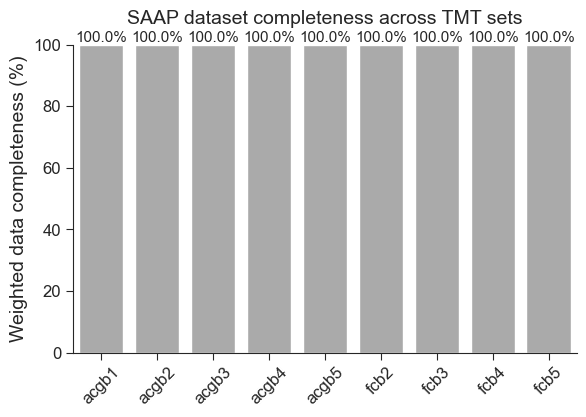

In [340]:
# weighted SAAP data completeness per tissue
# if using SAAP_quant_df with 100% data completeness, should read 100% completeness for all tissues
# if using SAAP_quant_df with all observations, may read varying completeness across tissues
comp_cols=[
'Positional_probability',
'SAAP_PEP',
'BP_PEP',
'MTP_PrecInt',
'BP_PrecInt',
'Prec_RAAS',
'MTP_ReportInt',
'BP_ReportInt',
'Reporter_RAAS',
'BP_ReportInt_Norm',
'MTP_ReportInt_Norm'
]

comp_df=SAAP_quant_df.copy()
plot_rows=[]
for ds in sorted(comp_df['Dataset'].dropna().unique()):
    ds_df=comp_df[comp_df['Dataset']==ds]
    total_values=len(ds_df)*len(comp_cols)
    nonmissing_values=sum(
        ds_df[c].notna().sum()
        for c in comp_cols
    )
    completeness=100*(nonmissing_values/total_values)
    plot_rows.append([ds,completeness])

plot_df=pd.DataFrame(plot_rows,columns=['Dataset','Completeness'])
fig,ax=plt.subplots(figsize=(6.5,4))
sns.barplot(data=plot_df,x='Dataset',y='Completeness',color='#aaaaaa')
sns.despine()
ax.tick_params('both',labelsize=12)
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('Weighted data completeness (%)',fontsize=14)
plt.ylim(0,100)
plt.title('SAAP dataset completeness across TMT sets',fontsize=14,pad=15)
plt.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=11)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR+'SAAP_weighted_data_completeness_by_tissue.pdf', bbox_inches='tight')

acgb1
acgb2
acgb3
acgb4
acgb5
fcb2
fcb3
fcb4
fcb5
acgb1
acgb2
acgb3
acgb4
acgb5
fcb2
fcb3
fcb4
fcb5


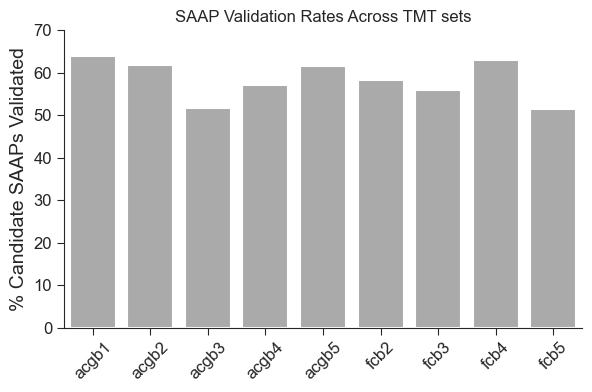

In [341]:
# get dataframe with number of unique substituted peptides, candidate and validated
rows = []
cols = ['Dataset', 'N SAAP sequences', 'SAAP sequence type', 'TMT set']

for i,ds in enumerate(datasets):
    print(ds)
    samples = samples_list[i]
    data_dir = data_dir_list[i]
    for s in samples:
        n_seqs = get_n_unq_seqs(data_dir, s)
        n_val_seqs = get_n_unq_val(data_dir, s)
        rows.append([ds, n_seqs, 'Candidate', s])
        rows.append([ds, n_val_seqs, 'Validated', s])
plt_df = pd.DataFrame(rows, columns=cols)

# get dataframe with percentage of peptides validated and percentage of peptides with no genome homology (from ds_filter_dict.p generated above)
pcnt_rows = []
for i,ds in enumerate(datasets):
    print(ds)
    data_dir = data_dir_list[i]
    samples = samples_list[i]
    ds_plt_df = plt_df.loc[plt_df['Dataset']==ds,:]
    ds_filter_dict = filter_dict[ds]
    for j,s in enumerate(samples):
        s_df = ds_plt_df.loc[ds_plt_df['TMT set']==s,:]
        n_cand = s_df.loc[s_df['SAAP sequence type']=='Candidate', 'N SAAP sequences'].values[0]
        n_val = s_df.loc[s_df['SAAP sequence type']=='Validated', 'N SAAP sequences'].values[0]
        val_pcnt = 100*(n_val/n_cand)
        n_aas = ds_filter_dict['AAS'][j]
        pcnt_rows.append([ds,s, val_pcnt, 'Validated SAAP'])
pcnt_df = pd.DataFrame(pcnt_rows, columns=['Dataset', 'TMT set', '% peptides', '% type'])
nonrectum_row = [i for i,row in pcnt_df.iterrows() if (row['TMT set']!='rectum') and (row['TMT set']!='bonemarrow')] # too little data, removed these tissues from analysis
pcnt_df = pcnt_df.loc[nonrectum_row]
pcnt_df.to_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx')
# pcnt_df = pd.read_excel(DEPDIR+'percent_validated_genomehomol_SAAP.xlsx', index_col=0)

# plot percentage of candidate SAAPs validated across samples
sns.set_style(style="ticks")  
fig, ax = plt.subplots(figsize=(6, 4))  
c_palette = {'Validated SAAP': '#aaaaaa'}
avg_pcnt_df = pcnt_df.groupby(['Dataset', 'TMT set', '% type'], as_index=False).agg({'% peptides': 'mean'})
sns.barplot(data=avg_pcnt_df, x='Dataset', y='% peptides', hue='% type', ax=ax, dodge=True,
            palette = c_palette, edgecolor='white', linewidth=1.5)
ax.get_legend().remove()
sns.despine()
plt.ylim(0, 70) 
plt.yticks(fontsize=12)  
plt.xticks(rotation=45, fontsize=12)  
plt.xlabel('', fontsize=14)  
plt.title('SAAP Validation Rates Across TMT sets')
plt.ylabel('% Candidate SAAPs Validated', fontsize=14)  
plt.tight_layout()
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR + 'percent_validated_allDS_boxplot.pdf', bbox_inches='tight')
plt.show()

## Post-Translational Modifications

acgb1
acgb2


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)


acgb3


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_object

acgb4
acgb5
fcb2


/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_df.fillna(0, inplace=True)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3660436720.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_object

fcb3
fcb4
fcb5
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
creating dictionary with PTM dataframes for each dataset
Extracting top PTMs by frequency into a plotting dataframe
finding number of peptide IDs
  Dataset  Identified PSMs (1% FDR)  Peptides  Peptides (evidence)  \
0   acgb1                    118301     73189                73026   
1   acgb2                    101640     68830                68677   
2   acgb3                    106532     73986                73817   
3   acgb4                     86649     61420                61298   
4   acgb5                     924

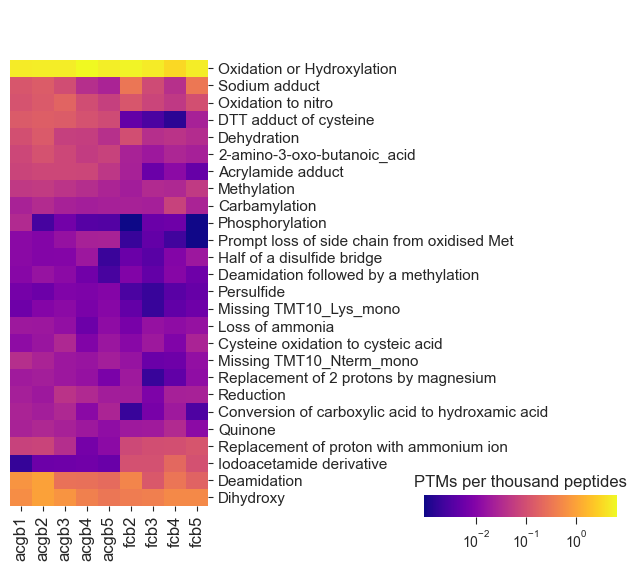

In [342]:
# get PTM dataframe for each dataset
for i in range(len(datasets)):
    print(datasets[i])
    data_dir =  data_dir_list[i]
    ptm_dict = pickle.load(open(data_dir+'PTM_dict.p', 'rb'))
    heatmap_df = get_ptm_df(ptm_dict, ds)
    heatmap_df.to_excel(DEPDIR+'PTM_heatmap_df.xlsx')
    
# create a dictionary with the PTM dataframes for each dataset
ptm_heatmap_dict = {}
for i,ds in enumerate(datasets):
    data_dir = data_dir_list[i]
    print("creating dictionary with PTM dataframes for each dataset")
    ptm_df = pd.read_excel(data_dir + 'PTM_heatmap_df.xlsx', index_col=0)
    ptm_df['avg'] = [np.mean(row.values) for i,row in ptm_df.iterrows()]
    ptm_df.sort_values('avg', ascending=False, inplace=True) # sort by frequency to extract top PTMs for plot
    
    ptm_df.index = [x[0].upper()+x[1:] for x in ptm_df.index]
    ptm_heatmap_dict[ds] = ptm_df
    
pickle.dump(ptm_heatmap_dict, open(DEPDIR+'PTM_heatmap_dict.p', 'wb'))
#ptm_heatmap_dict = pickle.load(open(nofilter_outdir+'PTM_heatmap_dict.p', 'rb'))


# extract the top PTMs by frequency into a dataframe for plotting
print("Extracting top PTMs by frequency into a plotting dataframe")
top20 = []
for ds, ds_df in ptm_heatmap_dict.items():
    if len(top20)==0:
        top20 = ds_df.index.values[0:40]
    else:
        top20new = ds_df.index.values[0:40]
        top20 = [x for x in top20 if x in top20new]
plot_df = pd.DataFrame(index=top20, columns=datasets)
for ptm in top20:
    for ds in datasets:
        heatmap_df = ptm_heatmap_dict[ds]
        plot_df.loc[ptm,ds] = heatmap_df.loc[ptm,'avg']
plot_df = plot_df.astype(float)

# need number of peptides IDd to normalize N each PTM per 1000 peptides
print("finding number of peptide IDs")
print(ds_metrics)
print(ds_metrics.columns.tolist())  # Print column names exactly as they are

n_peptides_list = []
for ds in datasets:
    n_peptides = ds_metrics.loc[ds_metrics['Dataset']==ds, 'Peptides (evidence)'].values[0]
    n_peptides_list.append(n_peptides)

# normalize PTM plot df by per thousand peptides
print("normalizing PTM plot df by per thousand peptides")
scaled_plot_df = deepcopy(plot_df)
for i,ds in enumerate(datasets):
    scaled_plot_df[ds] = [x/(n_peptides_list[i]/1000) for x in scaled_plot_df[ds]]
scaled_plot_df.to_excel(DEPDIR+'PTM_heatmap_data.xlsx')

print("finished!")

# plot ptm heatmap
cg = sns.clustermap(
    data=scaled_plot_df,
    yticklabels=True,
    norm=LogNorm(),
    cbar_kws={
        'orientation': 'horizontal',
        'ticks': [0.01, 0.1, 1, 10]
    },
    figsize=(5.5, 5.5),
    cmap=sns.color_palette('plasma', as_cmap=True),
    method='ward',
    col_cluster=False,
    row_cluster=True,
    dendrogram_ratio=(0.05, 0.1),
    cbar_pos=(0.8, 0.05, 0.35, 0.04)
)

cg.ax_cbar.set_title('PTMs per thousand peptides', fontsize=12, pad=6)
cg.ax_cbar.tick_params(labelsize=10)
cg.ax_cbar.minorticks_off() 

plt.setp(cg.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=12)
plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), fontsize=11)
cg.ax_row_dendrogram.set_visible(False)
plt.tick_params(axis='both', length=5)

plt.savefig(PLOT_DIR + 'PTM_heatmap_top20.pdf', bbox_inches='tight')

## Validation Metrics

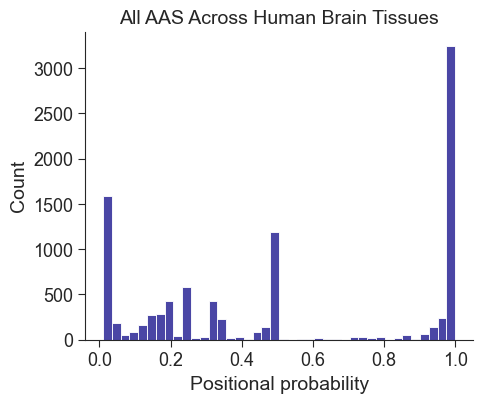

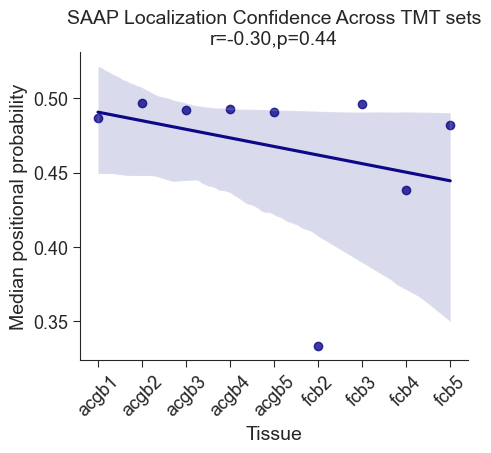

In [480]:
# positional probability distribution
fig,ax=plt.subplots(figsize=(5,4))
loc_df=SAAP_quant_df['Positional_probability']
loc_df=(loc_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=loc_df,bins=40,color='#0D0887')
sns.despine()
ax.tick_params('both',labelsize=13)
plt.xlabel('Positional probability',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title('All AAS Across Human Brain Tissues',fontsize=14)
plt.savefig(PLOT_DIR+'loc_prob_all_AAS.pdf',bbox_inches='tight')

# positional probability correlation across tissues
loc_df=SAAP_quant_df.copy()
loc_df=loc_df.replace([np.inf,-np.inf],np.nan).dropna(subset=['Positional_probability'])
tissue_corr=loc_df.groupby('Dataset')['Positional_probability'].median().reset_index()
# tissue_corr=loc_df.groupby('Dataset')['Positional_probability'].mean().reset_index()
tissue_corr['Dataset_num']=range(len(tissue_corr))
r,p=sp.stats.pearsonr(tissue_corr['Dataset_num'],tissue_corr['Positional_probability'])

fig,ax=plt.subplots(figsize=(5,4))
sns.regplot(data=tissue_corr,x='Dataset_num',y='Positional_probability',color='#0D0887')
sns.despine()
ax.tick_params('both',labelsize=13)
ax.set_xticks(tissue_corr['Dataset_num'])
ax.set_xticklabels(tissue_corr['Dataset'],rotation=45)
plt.xlabel('Tissue',fontsize=14)
plt.ylabel('Median positional probability',fontsize=14)
# plt.ylabel('Mean positional probability',fontsize=14)
plt.tick_params(axis='both', length=5)
plt.title(f'SAAP Localization Confidence Across TMT sets\nr={r:.2f},p={p:.3g}',fontsize=14)
plt.savefig(PLOT_DIR+'loc_prob_tissue_correlation.pdf',bbox_inches='tight')

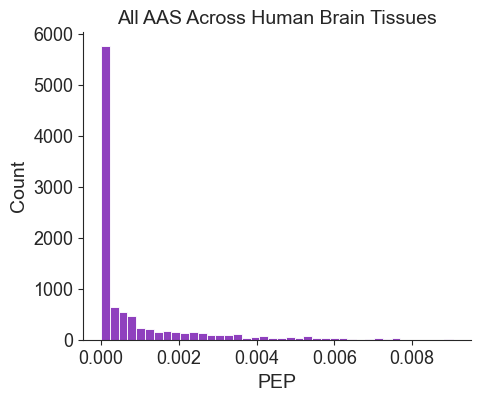

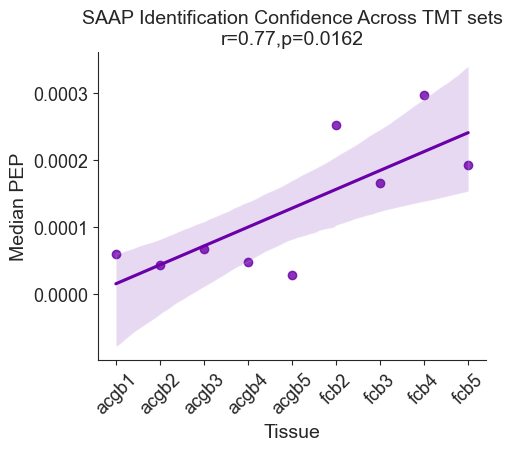

In [479]:
# SAAP PEP distribution
fig,ax=plt.subplots(figsize=(5,4))
pep_df=SAAP_quant_df['SAAP_PEP']
pep_df=(pep_df).replace([np.inf,-np.inf],np.nan).dropna()
sns.histplot(x=pep_df,bins=40,color='#6A00A8')
sns.despine()
ax.tick_params('both',labelsize=13)
plt.xlabel('PEP',fontsize=14)
plt.ylabel('Count',fontsize=14)
plt.title('All AAS Across Human Brain Tissues',fontsize=14)
plt.savefig(PLOT_DIR+'SAAP_PEP_distribution.pdf',bbox_inches='tight')

# SAAP PEP correlation across tissues
pep_df=SAAP_quant_df.copy()
pep_df=pep_df.replace([np.inf,-np.inf],np.nan).dropna(subset=['SAAP_PEP'])
tissue_corr=pep_df.groupby('Dataset')['SAAP_PEP'].median().reset_index()
tissue_corr['Dataset_num']=range(len(tissue_corr))
r,p=sp.stats.pearsonr(tissue_corr['Dataset_num'],tissue_corr['SAAP_PEP'])

fig,ax=plt.subplots(figsize=(5,4))
sns.regplot(data=tissue_corr,x='Dataset_num',y='SAAP_PEP',color='#6A00A8')
sns.despine()
ax.tick_params('both',labelsize=13)
ax.set_xticks(tissue_corr['Dataset_num'])
ax.set_xticklabels(tissue_corr['Dataset'],rotation=45)
plt.xlabel('Tissue',fontsize=14)
plt.ylabel('Median PEP',fontsize=14)
plt.title(f'SAAP Identification Confidence Across TMT sets\nr={r:.2f},p={p:.3g}',fontsize=14)
plt.savefig(PLOT_DIR+'SAAP_PEP_tissue_correlation.pdf',bbox_inches='tight')

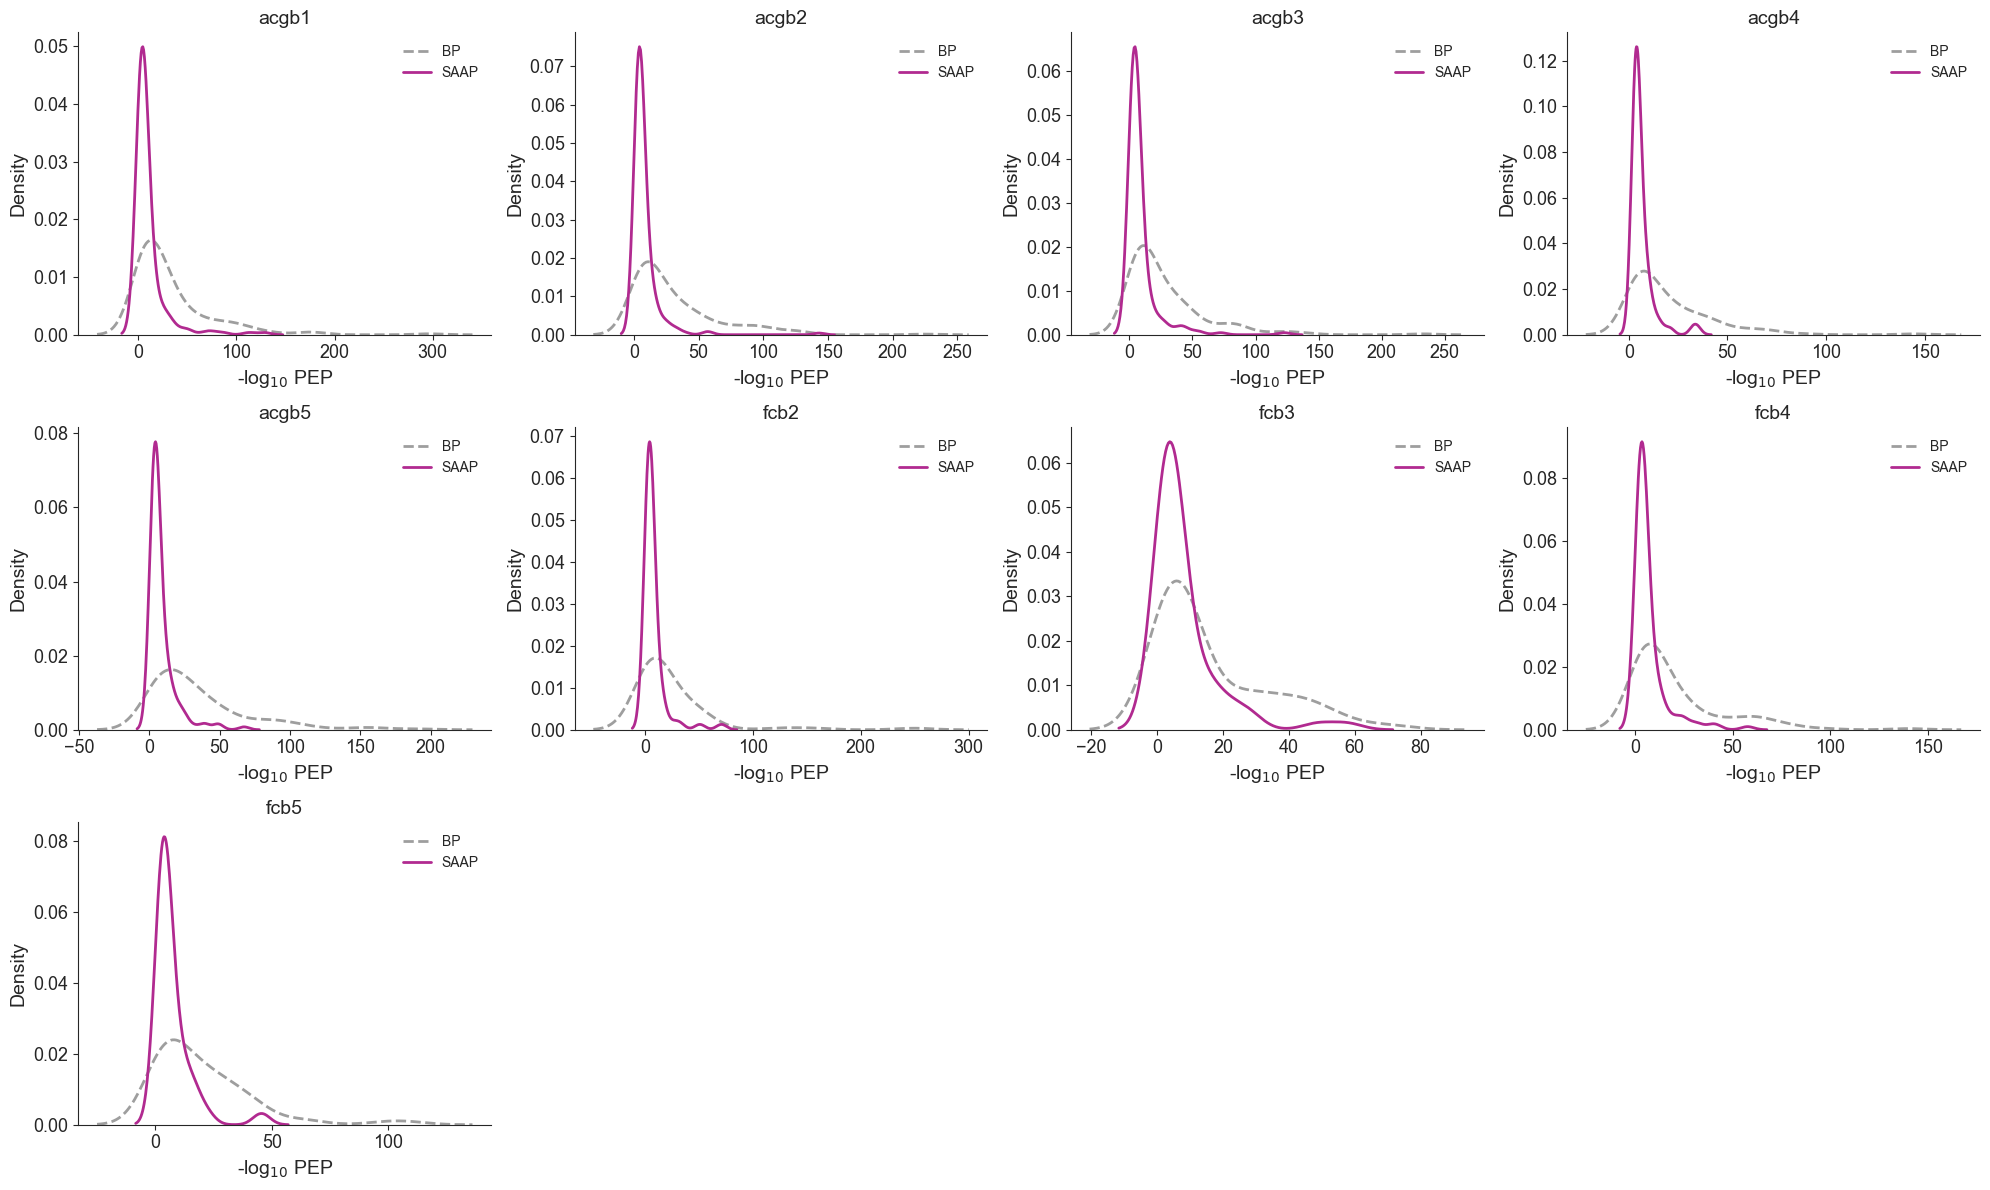

In [345]:
# SAAP vs BP PEP distribution by tissue
datasets=sorted(SAAP_quant_df['Dataset'].dropna().unique())
ncols=4
nrows=int(np.ceil(len(datasets)/ncols))
fig,axes=plt.subplots(figsize=(5*ncols,4*nrows),nrows=nrows,ncols=ncols)
axes=np.array(axes).flatten()
for ax,ds in zip(axes,datasets):
    df=SAAP_quant_df[SAAP_quant_df['Dataset']==ds].drop_duplicates(subset=['MTP_seq','tmt_set'])
    saap_pep=-np.log10(df['SAAP_PEP']).replace([np.inf,-np.inf],np.nan).dropna()
    bp_pep=-np.log10(df['BP_PEP']).replace([np.inf,-np.inf],np.nan).dropna()
    sns.kdeplot(x=bp_pep,label='BP',linewidth=2,linestyle='--',color='#9E9E9E',ax=ax)
    sns.kdeplot(x=saap_pep,label='SAAP',linewidth=2,color='#B12A90',ax=ax)
    ax.tick_params('both',labelsize=13)
    plt.sca(ax)
    plt.xlabel('-log$_{10}$ PEP',fontsize=14)
    plt.ylabel('Density',fontsize=14)
    plt.title(ds,fontsize=14)
    plt.legend(fontsize=10,frameon=False)
    sns.despine()
for ax in axes[len(datasets):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(PLOT_DIR+'SAAP_BP_PEP_kde_by_tissue.pdf',bbox_inches='tight')

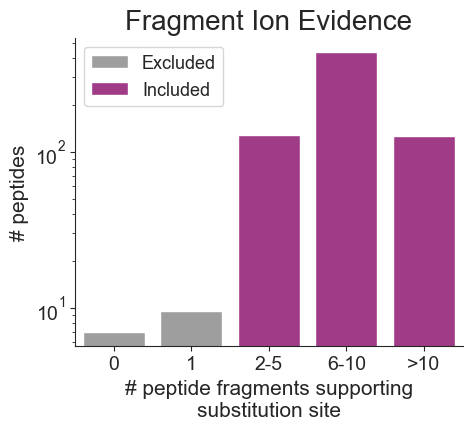

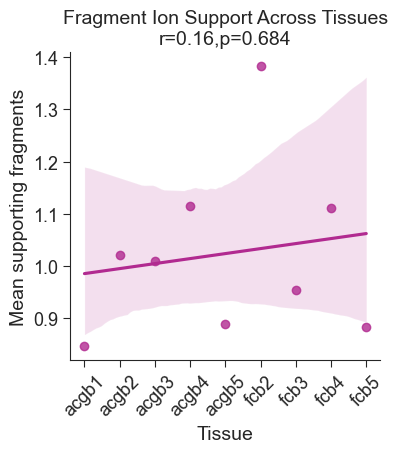

In [346]:
# number of fragment ions supporting substitution site
# plot n fragments barplots
fig,ax=plt.subplots(figsize=(5,4))
plot_df = frag_df
sns.set_style('ticks')
sns.barplot(data=plot_df, x='Bin', y='Count', hue='Used', dodge=False, palette=['#9E9E9E', '#B12A90'],errorbar=None)
ax.tick_params('both', labelsize=14)

plt.ylabel('# peptides', fontsize=15)
handles, labels = ax.get_legend_handles_labels()
plt.yscale("log")
plt.title(f'Fragment Ion Evidence',fontsize=20)
plt.legend(handles=handles, loc='upper left', labels=['Excluded', 'Included'], fontsize=13)
plt.xlabel('# peptide fragments supporting\nsubstitution site', fontsize=15)
sns.despine()
plt.savefig(PLOT_DIR + 'fragment_ion_evidence_barplot_allDS.pdf', bbox_inches='tight')

# fragment ion support correlation across tissues
frag_df=pos_prob_df.copy()
frag_df['N_fragments']=frag_df[['bp_b_left_frag_mass','bp_b_right_frag_mass','bp_y_left_frag_mass','bp_y_right_frag_mass']].notna().sum(axis=1)
frag_df=frag_df.drop_duplicates(subset=['SAAP','TMT set'])
tissue_corr=frag_df.groupby('Dataset')['N_fragments'].mean().reset_index()
# tissue_corr=frag_df.groupby('Dataset')['N_fragments'].median().reset_index()
tissue_corr['Dataset_num']=range(len(tissue_corr))
r,p=sp.stats.pearsonr(tissue_corr['Dataset_num'],tissue_corr['N_fragments'])
fig,ax=plt.subplots(figsize=(4,4))
sns.regplot(data=tissue_corr,x='Dataset_num',y='N_fragments',color='#B12A90')
ax.tick_params('both',labelsize=13)
ax.set_xticks(tissue_corr['Dataset_num'])
ax.set_xticklabels(tissue_corr['Dataset'],rotation=45)
plt.xlabel('Tissue',fontsize=14)
plt.ylabel('Mean supporting fragments',fontsize=14)
sns.despine()
plt.tick_params(axis='both', length=5)
# plt.ylabel('Median supporting fragments',fontsize=14)
plt.title(f'Fragment Ion Support Across Tissues\nr={r:.2f},p={p:.3g}',fontsize=14)
plt.savefig(PLOT_DIR+'fragment_ion_evidence_tissue_correlation.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/2164351901.py:15: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/2164351901.py:16: RuntimeWarning: divide by zero encountered in log10
  plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)


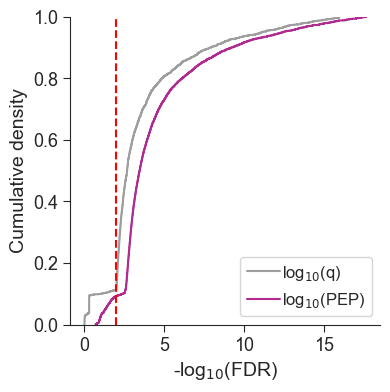

In [347]:
# cumulative density of q-values and PEPs across all datasets and samples
# plot the p-values determined by MaxQuant and the q-values determined from only the substituted peptides
plot_rows = []
plot_cols = ['Dataset', 'TMT/Tissue', 'q-value', 'PEP']
for ds in datasets:
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    qmtp_dict = pickle.load(open(data_dir+'qMTP_dict.p', 'rb'))
    for s in samples:
        s_dict = qmtp_dict[s]
        for k,v in s_dict['Posterior subs probability'].items():
            plot_rows.append([ds, s, 1-v[0], s_dict['q-value'][k][0]])
plot_df = pd.DataFrame(plot_rows, columns=plot_cols)

plot_df['-log q'] = plot_df.apply(lambda x: -np.log10(x['q-value']),axis=1)
plot_df['-log PEP'] = plot_df.apply(lambda x: -np.log10(x['PEP']),axis=1)
fig,ax = plt.subplots(figsize=(4,4))
sns.ecdfplot(plot_df, x='-log q', label='log$_{10}$(q)', color='#9E9E9E')
sns.ecdfplot(plot_df, x='-log PEP', label='log$_{10}$(PEP)', color='#B12A90')
plt.ylabel('Cumulative density', fontsize=14)
plt.xlabel('-log$_{10}$(FDR)', fontsize=14)
ax.tick_params('both', labelsize=13)
sns.despine()
plt.plot((2,2), plt.ylim(), '--r')
plt.tick_params(axis='both', length=5)
plt.legend(loc='lower right', fontsize=12, handletextpad=0.1)
plt.savefig(PLOT_DIR+'qvalue_CumDensity_plot.pdf', bbox_inches='tight')

<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
<>:35: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:55: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1443665289.py:35: SyntaxWarning: invalid escape sequence '\g'
  all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1443665289.py:43: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, color='#9E9E9E', label='log$_{10}$(RAAS)$\geq$0')
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1443665289.py:55: SyntaxWarning: invalid escape sequence '\g'
  sns.kdeplot(data = high_ra

acgb1
acgb2
acgb3
acgb4
acgb5
fcb2
fcb3
fcb4
fcb5


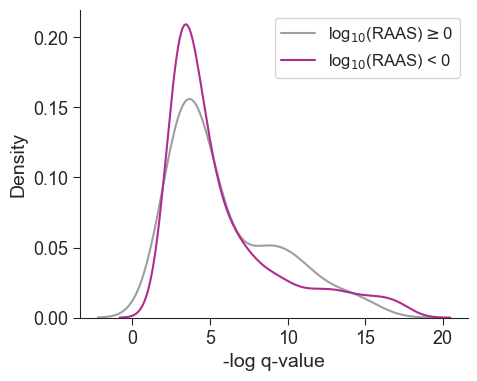

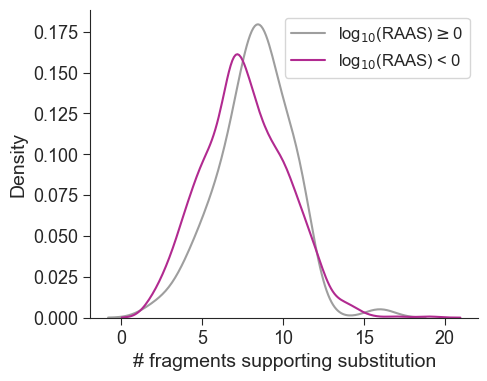

In [348]:
# cumulative density of q-values and PEPs across all datasets and samples stratified by RAAS
# generate a dictionary with PEP values and N fragments for all SAAP in all datasets 
paas_pep_dict = {}
for ds in datasets:
    print(ds)
    data_dir = data_dir_list[datasets.index(ds)]
    samples = samples_list[datasets.index(ds)]
    mtp_dict = pickle.load(open(data_dir + 'Ion_validated_MTP_dict.p', 'rb'))
    mtp_quant_dict = pickle.load(open(data_dir + 'MTP_quant_dict.p', 'rb'))

    plot_rows = []
    plot_cols = ['Dataset', 'Sample', 'PAAS', 'PAAS_val_idx', 'DP PEP', 'PAAS PEP', 'PAAS q', 'PAAS Precursor Intensity','BP Precursor Intensity', 'Precursor RAAS', 'N fragments']
    for s in samples:
        s_dict = mtp_dict[s]
        for k, paas in s_dict['mistranslated sequence'].items():
            paas_pep = s_dict['Posterior subs probability'][k]
            paas_q = s_dict['q-value'][k]
            dp_pep = s_dict['DP PEP'][k]
            n_frags = s_dict['fragment_evidence'][k]
            q_dict = [i for i,v in mtp_quant_dict.items() if v['MTP_seq']==paas]
            if len(q_dict)>0:
                q_dict = mtp_quant_dict[q_dict[0]]
                paas_prec = q_dict['MTP_PrecInt'][s]
                bp_prec = q_dict['BP_PrecInt'][s]
                raas = q_dict['Prec_ratio'][s]
                if (~np.isnan(raas)) and (~np.isinf(raas)):
                    plot_rows.append([ds, s, paas, k, dp_pep, paas_pep, paas_q, paas_prec, bp_prec, raas, n_frags])
    plot_df = pd.DataFrame(plot_rows, columns=plot_cols)   
    paas_pep_dict[ds] = plot_df

pickle.dump(paas_pep_dict, open(OUTDIR+'SAAP_PEP_dfs.p', 'wb'))

# create data frame for plot 
all_ds_plot_df = pd.concat([v for k,v in paas_pep_dict.items()])
all_ds_plot_df['RAAS group'] = ['$\geq$0' if raas>=0 else '<0' for i,raas in list(enumerate(all_ds_plot_df['Precursor RAAS'].values))]
all_ds_plot_df = all_ds_plot_df.loc[all_ds_plot_df['PAAS q']<=0.01]

# plot histogram of confidence values stratified by RAAS
fig,ax = plt.subplots(figsize=(5,4))
all_ds_plot_df['-log q'] = [-np.log10(x) for x in all_ds_plot_df['PAAS q']]
high_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']>=0]
low_raas_df = all_ds_plot_df.loc[all_ds_plot_df['Precursor RAAS']<0]
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='-log q', fill=False, color='#9E9E9E', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='-log q', fill=False, label='log$_{10}$(RAAS) < 0', color='#B12A90')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('-log q-value', fontsize=14)
plt.legend(fontsize=12)
plt.tick_params(axis='both', length=5)
plt.savefig(PLOT_DIR+'RAASgroup_logq_hist.pdf', bbox_inches='tight')

# plot histogram of N fragments on substitution site stratified by RAAS
fig,ax = plt.subplots(figsize=(5,4))
sns.kdeplot(data = high_raas_df.loc[~np.isinf(high_raas_df['-log q'])], x='N fragments', fill=False, color='#9E9E9E', label='log$_{10}$(RAAS)$\geq$0')
sns.kdeplot(data = low_raas_df.loc[~np.isinf(low_raas_df['-log q'])], x='N fragments', fill=False, label='log$_{10}$(RAAS) < 0', color='#B12A90')
sns.despine()
ax.tick_params('both', labelsize=13)
plt.ylabel('Density', fontsize=14)
plt.xlabel('# fragments supporting substitution', fontsize=14)
# plt.yticks([0,0.03,0.06,0.09,0.12])
plt.tick_params(axis='both', length=5)
plt.legend(loc='upper right', fontsize=12)
plt.savefig(PLOT_DIR+'RAASgroup_Nfrags_hist.pdf', bbox_inches='tight')

In [ ]:
# ## Mass error analysis






# # ═════════════════════════════════════════════════════════════════════════════
# # RAAS ANALYSIS
# # 1. Tissue-specific RAAS distributions by substitution type
# # 2. High vs low RAAS comparison across tissues
# # ═════════════════════════════════════════════════════════════════════════════

# COLOR_HI='#C0527A'
# COLOR_LO='#AAAAAA'


# # ── Data prep ────────────────────────────────────────────────────────────────

# def build_raas_df(SAAP_quant_df):

#     peptide_keys=['Dataset','MTP_seq','BP_seq','aa_sub']

#     sub_df=replicate_cols(SAAP_quant_df)

#     raas_df=(sub_df
#              .groupby(peptide_keys+['Disease'])['Reporter_RAAS']
#              .median()
#              .reset_index())

#     raas_df=raas_df.replace([np.inf,-np.inf],np.nan)
#     raas_df=raas_df.dropna(subset=['Reporter_RAAS'])

#     return raas_df


# def build_raas_groups(df):

#     rows=[]

#     for _,row in df.iterrows():

#         grp='RAAS ≥ 0' if row['Reporter_RAAS']>=0 else 'RAAS < 0'

#         rows.append({
#             'Dataset':row['Dataset'],
#             'aa_sub':row['aa_sub'],
#             'RAAS':row['Reporter_RAAS'],
#             'RAAS group':grp
#         })

#     return pd.DataFrame(rows)


# # ── Plots ────────────────────────────────────────────────────────────────────

# def plot_raas_by_dataset(df,outdir):

#     sns.set(style='white',context='notebook',font_scale=1.1)

#     fig,ax=plt.subplots(
#         figsize=(10,max(3,df['Dataset'].nunique()*0.7))
#     )

#     sns.boxplot(data=df,
#                 x='Dataset',
#                 y='RAAS',
#                 hue='RAAS group',
#                 palette={'RAAS ≥ 0':COLOR_HI,
#                          'RAAS < 0':COLOR_LO},
#                 linewidth=1,
#                 fliersize=0.5,
#                 ax=ax)

#     ax.axhline(0,
#                color='gray',
#                linestyle='--',
#                linewidth=0.8)

#     ax.set_xlabel('',fontsize=13)
#     ax.set_ylabel('RAAS',fontsize=13)

#     ax.tick_params(axis='x',
#                    rotation=45)

#     ax.legend(loc='upper right',
#               fontsize=9,
#               frameon=False)

#     ax.set_title('RAAS: High vs Low Across Tissues',
#                  fontsize=13,
#                  fontweight='bold')

#     sns.despine(ax=ax)

#     plt.tight_layout()

#     plt.savefig(os.path.join(outdir,
#                              'RAAS_high_v_low.pdf'),
#                 bbox_inches='tight')

#     plt.show()


# # ── Run ──────────────────────────────────────────────────────────────────────

# raas_df=build_raas_df(SAAP_quant_df)

# raas_group_df=build_raas_groups(raas_df)

# plot_raas_by_dataset(raas_group_df,outdir)

In [350]:
# shared peptides for a protein and their raas 

# 1.5 BLASTp

# 2. Analysis of Substitution Types

## Overview of Substitution Frequencies & Enrichment

In [364]:
raas_col = 'Reporter_RAAS'

SAAP_quant_df_grouped = SAAP_quant_df.copy()
SAAP_quant_df_grouped['Dataset'] = [
    'acg' if x.startswith('acg') else 'fc'
    for x in SAAP_quant_df_grouped['Dataset']]
# print(SAAP_quant_df_grouped)

SAAP_quant_df_grouped_acg = SAAP_quant_df_acg.copy()
SAAP_quant_df_grouped_acg['Dataset'] = [
    'acg' if x.startswith('acg') else 'fc'
    for x in SAAP_quant_df_grouped_acg['Dataset']]

SAAP_quant_df_grouped_fc = SAAP_quant_df_fc.copy()
SAAP_quant_df_grouped_fc['Dataset'] = [
    'acg' if x.startswith('acg') else 'fc'
    for x in SAAP_quant_df_grouped_fc['Dataset']]

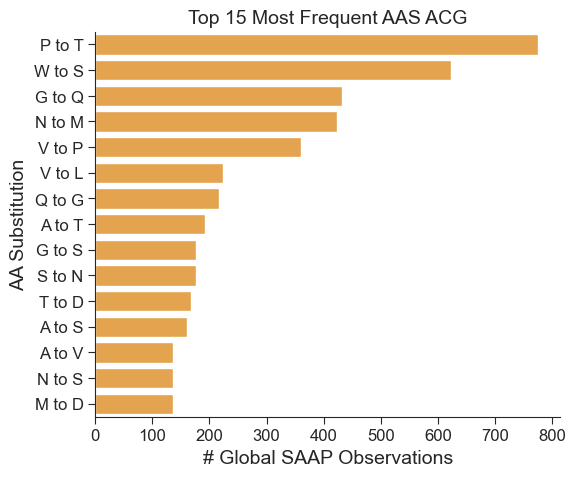

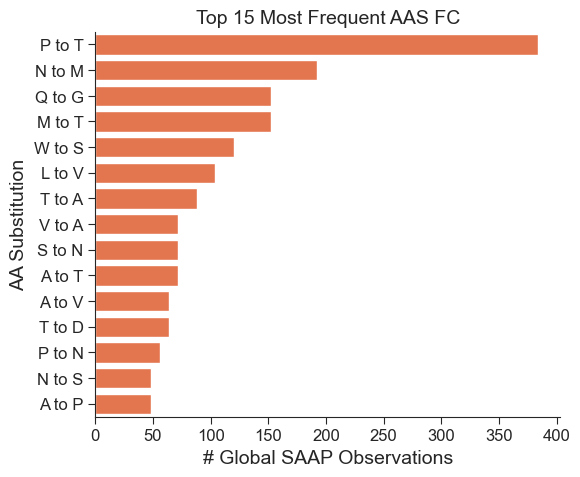

In [478]:
# Count all observed SAAP events and plot the 15 most frequent substitution types
sub_df = SAAP_quant_df_acg.copy()
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)]
sub_order = plot_df['aa_sub'].value_counts().index
fig, ax = plt.subplots(figsize=(6,5))

sns.countplot(data=plot_df, y='aa_sub', order=sub_order, color='#FCA636', ax=ax)
ax.tick_params('both', labelsize=12)
plt.xlabel('# Global SAAP Observations', fontsize=14)
plt.ylabel('AA Substitution', fontsize=14)
plt.title('Top 15 Most Frequent AAS ACG', fontsize=14)
plt.tick_params(axis='both', length=5)
sns.despine()
plt.savefig(PLOT_DIR + 'top15_SAAP_substitutions_acg.pdf', bbox_inches='tight')


# Count all observed SAAP events and plot the 15 most frequent substitution types
sub_df = SAAP_quant_df_fc.copy()
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)]
sub_order = plot_df['aa_sub'].value_counts().index
fig, ax = plt.subplots(figsize=(6,5))

sns.countplot(data=plot_df, y='aa_sub', order=sub_order, color="#FC6B36", ax=ax)
ax.tick_params('both', labelsize=12)
plt.xlabel('# Global SAAP Observations', fontsize=14)
plt.ylabel('AA Substitution', fontsize=14)
plt.title('Top 15 Most Frequent AAS FC', fontsize=14)
plt.tick_params(axis='both', length=5)
sns.despine()
plt.savefig(PLOT_DIR + 'top15_SAAP_substitutions_fc.pdf', bbox_inches='tight')

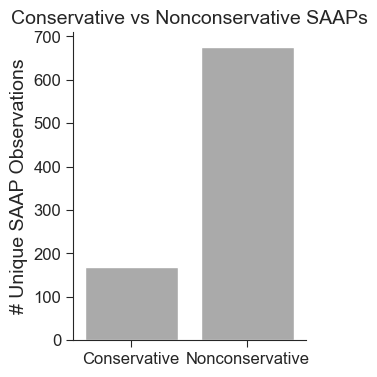

In [367]:
# Count all observed SAAP events and classify substitutions as conservative/nonconservative
sub_df = SAAP_quant_df_grouped.copy()
sub_df = sub_df.drop_duplicates(subset=['Dataset','MTP_seq','BP_seq','aa_sub'])

# biochemical group definitions
aa_groups = {
    'A':'nonpolar','V':'nonpolar','L':'nonpolar','I':'nonpolar','M':'nonpolar',
    'F':'aromatic','W':'aromatic','Y':'aromatic',
    'S':'polar','T':'polar','N':'polar','Q':'polar','C':'polar',
    'K':'positive','R':'positive','H':'positive',
    'D':'negative','E':'negative',
    'G':'special','P':'special'
}

# classify substitution type
def classify_sub(sub):
    aa1,aa2 = sub.split(' to ')
    
    if aa_groups[aa1] == aa_groups[aa2]:
        return 'Conservative'
    else:
        return 'Nonconservative'

sub_df['sub_class'] = sub_df['aa_sub'].apply(classify_sub)
fig,ax = plt.subplots(figsize=(3,4))
sns.countplot(data=sub_df,x='sub_class',order=['Conservative','Nonconservative'],color='#aaaaaa',ax=ax)
ax.tick_params('both', labelsize=12)
plt.ylabel('# Unique SAAP Observations', fontsize=14)
plt.xlabel('')
plt.title('Conservative vs Nonconservative SAAPs', fontsize=14)
sns.despine()
plt.tick_params(axis='both', length=5)
plt.savefig(PLOT_DIR+'conservative_vs_nonconservative.pdf',bbox_inches='tight')

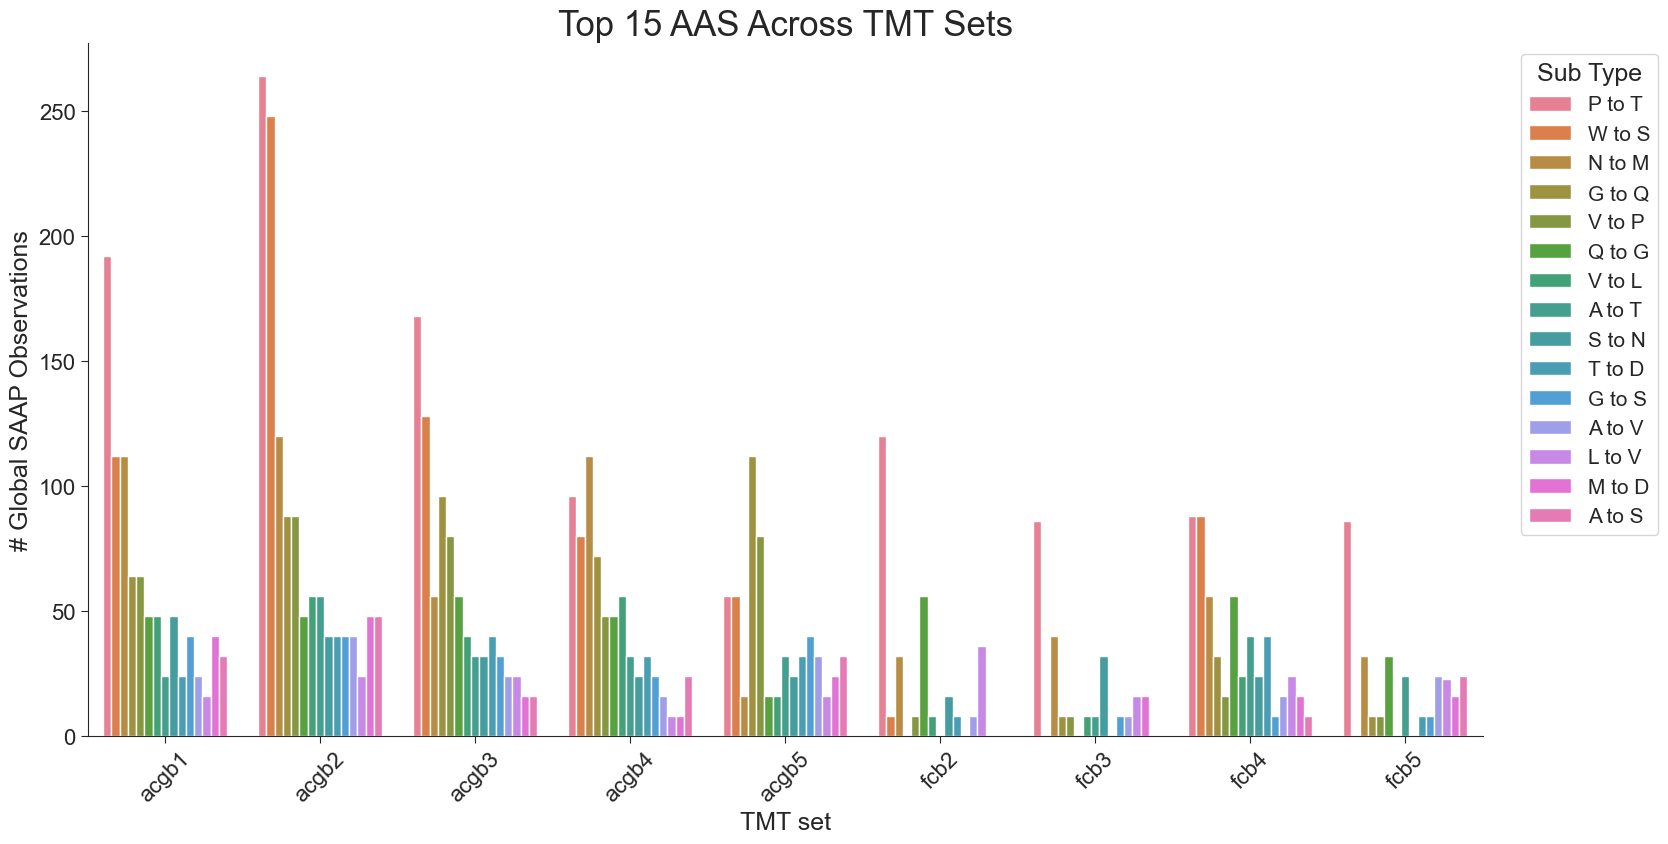

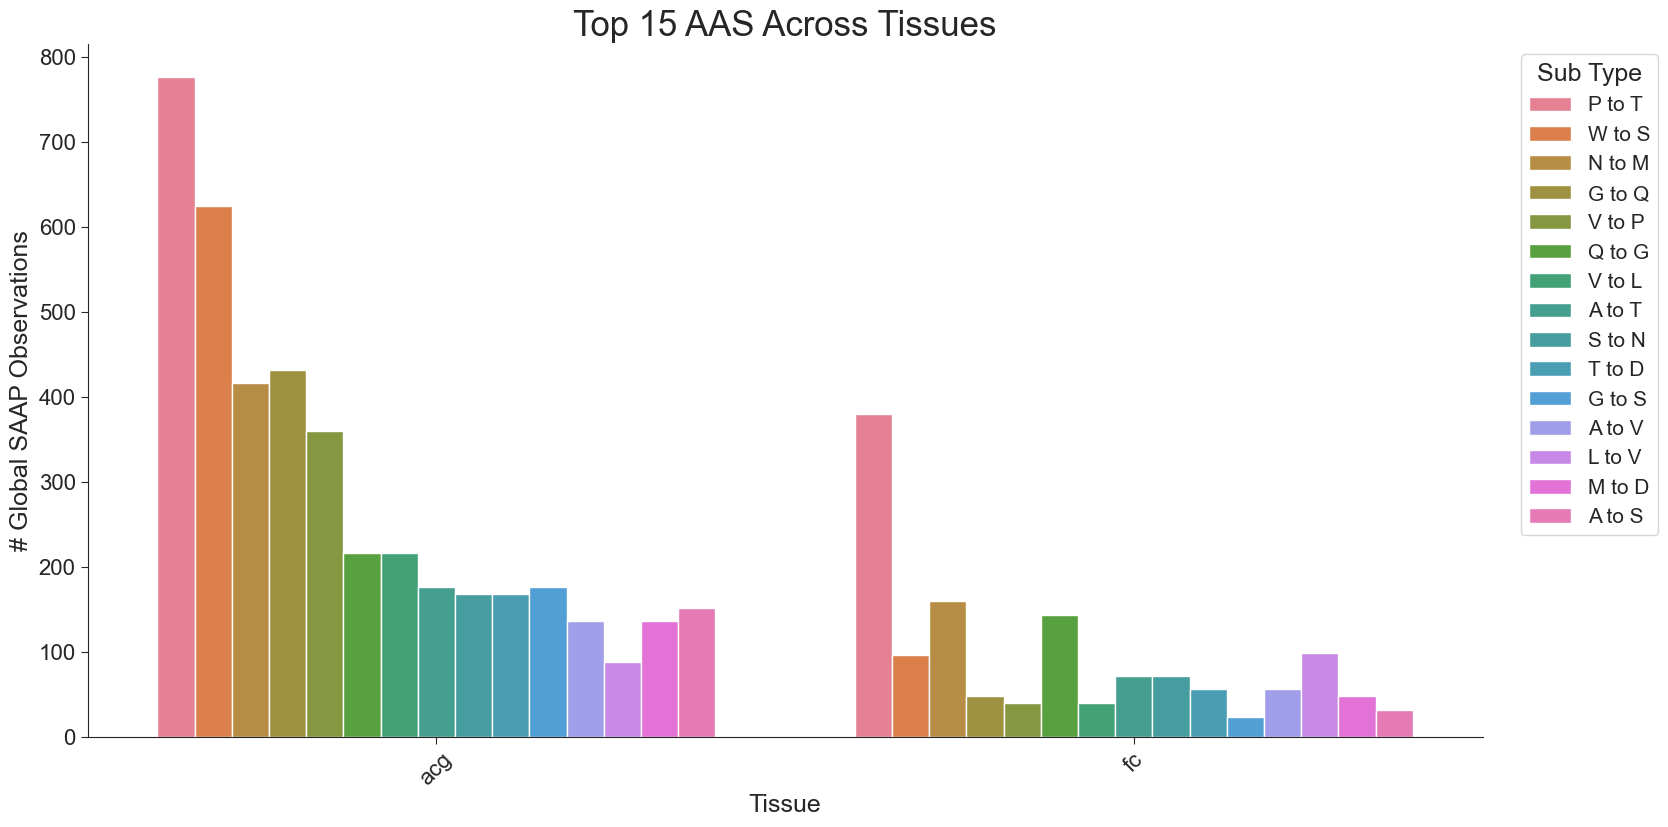

In [354]:
# Plot top substitution types across TMT sets 
sub_df = SAAP_quant_df.copy()
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Dataset'].unique())

# Count tissue/sub combinations, retaining 0-count pairs 
global_idx = pd.MultiIndex.from_product([tissue_order,sub_order],names=['Dataset','aa_sub'])
count_df = (plot_df.groupby(['Dataset', 'aa_sub']).size().reindex(global_idx, fill_value=0).reset_index(name='Count'))

fig,ax = plt.subplots(figsize=(18,9))
sns.barplot(data=count_df,x='Dataset',y='Count',hue='aa_sub',hue_order=sub_order,palette=sns.color_palette('husl',len(sub_order)),order=tissue_order,ax=ax)
ax.tick_params(axis='x',rotation=45,labelsize=16)
ax.tick_params(axis='y',labelsize=16)
plt.tick_params(axis='both', length=5)
ax.set_xlabel('TMT set',fontsize=18)
ax.set_ylabel('# Global SAAP Observations',fontsize=18)
ax.set_title('Top 15 AAS Across TMT Sets',fontsize=25)
ax.legend(title='Sub Type',bbox_to_anchor=(1.02,1),loc='upper left',frameon=True,fontsize=15,title_fontsize=18)
sns.despine()
plt.savefig(PLOT_DIR + 'top15_substitutions_across_tmtsets.pdf',bbox_inches='tight')


# Plot top substitution types across tissues 
sub_df = SAAP_quant_df_grouped.copy()
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Dataset'].unique())

# Count tissue/sub combinations, retaining 0-count pairs 
global_idx = pd.MultiIndex.from_product([tissue_order,sub_order],names=['Dataset','aa_sub'])
count_df = (plot_df.groupby(['Dataset', 'aa_sub']).size().reindex(global_idx, fill_value=0).reset_index(name='Count'))

fig,ax = plt.subplots(figsize=(18,9))
sns.barplot(data=count_df,x='Dataset',y='Count',hue='aa_sub',hue_order=sub_order,palette=sns.color_palette('husl',len(sub_order)),order=tissue_order,ax=ax)
ax.tick_params(axis='x',rotation=45,labelsize=16)
ax.tick_params(axis='y',labelsize=16)
plt.tick_params(axis='both', length=5)
ax.set_xlabel('Tissue',fontsize=18)
ax.set_ylabel('# Global SAAP Observations',fontsize=18)
ax.set_title('Top 15 AAS Across Tissues',fontsize=25)
ax.legend(title='Sub Type',bbox_to_anchor=(1.02,1),loc='upper left',frameon=True,fontsize=15,title_fontsize=18)
sns.despine()
plt.savefig(PLOT_DIR + 'top15_substitutions_across_tissues.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/421165860.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix=(count_df.pivot_table(index='From_AA',columns='To_AA',values='Count',fill_value=0).reindex(index=aa_order,columns=aa_order,fill_value=0))


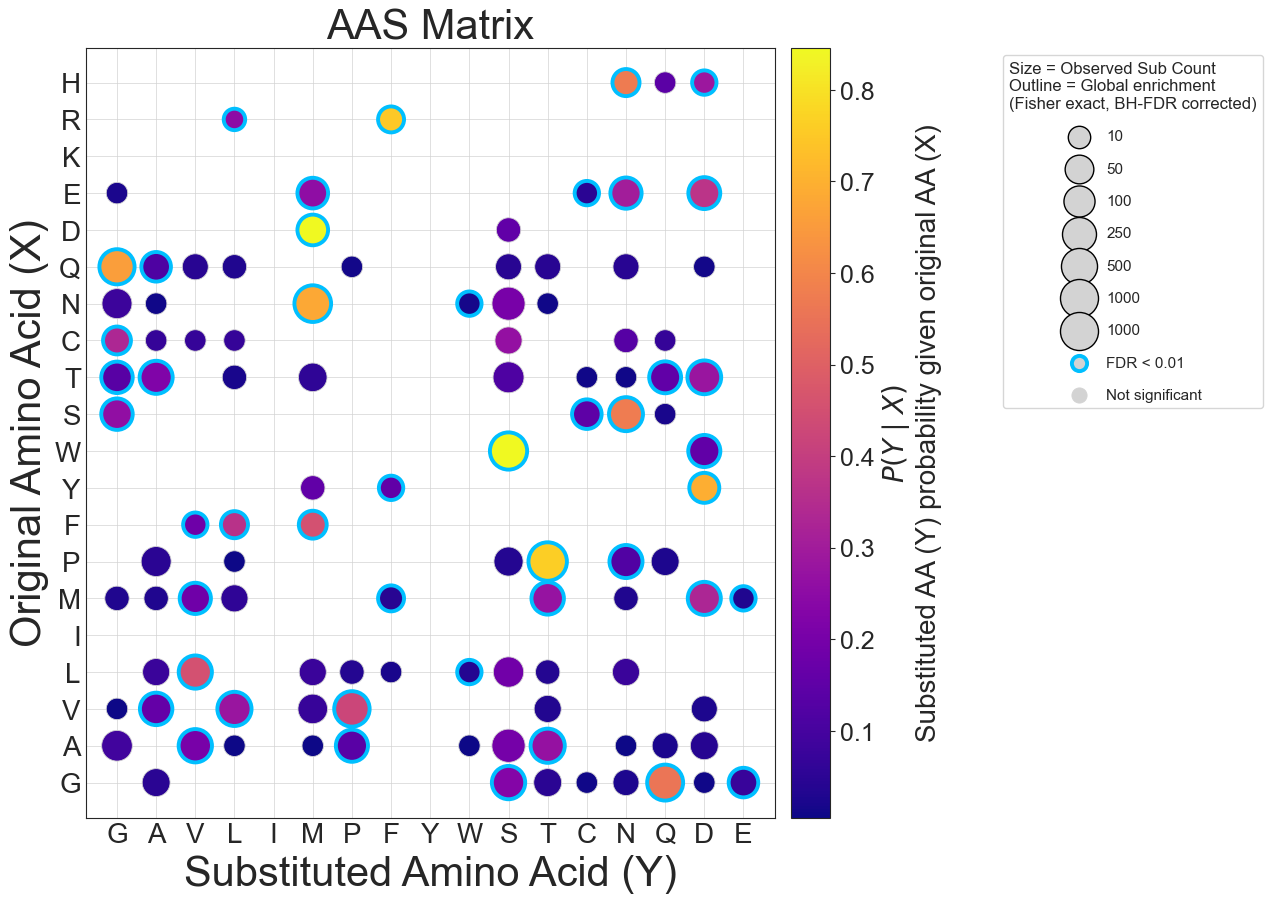

In [369]:
# Global bubble matrix of substitution probabilities and enrichments 
sub_df=SAAP_quant_df_grouped.copy()
sub_split=sub_df['aa_sub'].str.split(' to ',expand=True)
sub_df['From_AA']=sub_split[0]
sub_df['To_AA']=sub_split[1]
count_df=(sub_df.groupby(['From_AA','To_AA']).size().reset_index(name='Count'))
count_df=count_df[count_df['From_AA']!=count_df['To_AA']]
count_df['Row_fraction']=count_df.groupby('From_AA')['Count'].transform(lambda x:x/x.sum())
count_df['From_AA']=pd.Categorical(count_df['From_AA'],categories=aa_order,ordered=True)
count_df['To_AA']=pd.Categorical(count_df['To_AA'],categories=aa_order,ordered=True)
count_df=count_df.sort_values(['From_AA','To_AA'])

matrix=(count_df.pivot_table(index='From_AA',columns='To_AA',values='Count',fill_value=0).reindex(index=aa_order,columns=aa_order,fill_value=0))
for aa in aa_order: matrix.loc[aa,aa]=0

obs=matrix.values.astype(float)
row_total=obs.sum(axis=1,keepdims=True)
col_total=obs.sum(axis=0,keepdims=True)
grand_total=obs.sum()
expected=(row_total@col_total)/grand_total

results=[]

for i,from_aa in enumerate(aa_order):
    for j,to_aa in enumerate(aa_order):
        if from_aa==to_aa: continue
        observed=obs[i,j]
        expected_count=expected[i,j]
        row_fraction=(observed/row_total[i,0] if row_total[i,0]>0 else np.nan)
        a=observed
        b=row_total[i,0]-a
        c=col_total[0,j]-a
        d=grand_total-a-b-c
        if min(a,b,c,d)>=0:
            odds_ratio,pval=fisher_exact([[a,b],[c,d]],alternative='greater')
        else:
            odds_ratio,pval=np.nan,np.nan
        results.append([from_aa,to_aa,observed,expected_count,row_fraction,a,b,c,d,odds_ratio,pval])

stats_df=pd.DataFrame(results,columns=['From_AA','To_AA','Observed_count','Expected_count','P_Y_given_X','Observed_thisSwap','Observed_otherFromAA','Observed_otherToAA','Observed_allOther','Odds_ratio','pval'])

stats_df=run_fdr(stats_df,p_col='pval')
stats_df['Sig']=stats_df['FDR']<0.01

# Plotting
plot_df=count_df.merge(stats_df,on=['From_AA','To_AA'],how='left')
plot_df['From_AA']=pd.Categorical(plot_df['From_AA'],categories=aa_order,ordered=True)
plot_df['To_AA']=pd.Categorical(plot_df['To_AA'],categories=aa_order,ordered=True)

fig,ax=plt.subplots(figsize=(13.5,10))
scatter=ax.scatter(x=plot_df['To_AA'].cat.codes,y=plot_df['From_AA'].cat.codes,s=np.log10(plot_df['Observed_count']+1)*250,c=plot_df['P_Y_given_X'],cmap='plasma',edgecolors=np.where(plot_df['Sig'],'deepskyblue','lightgray'),linewidths=np.where(plot_df['Sig'],2.8,0.6))
ax.set_xticks(range(len(aa_order)))
ax.set_yticks(range(len(aa_order)))
ax.set_xticklabels(aa_order,fontsize=20)
ax.set_yticklabels(aa_order,fontsize=20)
ax.grid(color='lightgray',linewidth=0.5)
ax.tick_params('both',length=0)
plt.xlabel('Substituted Amino Acid (Y)',fontsize=30)
plt.ylabel('Original Amino Acid (X)',fontsize=30)
plt.title('AAS Matrix',fontsize=30)

fig.subplots_adjust(right=0.74)
cbar=plt.colorbar(scatter,pad=0.02)
cbar.set_label(r'$P(Y\mid X)$'+'\n'+'Substituted AA (Y) probability given original AA (X)',fontsize=20)
cbar.ax.tick_params(labelsize=18)

max_count=int(plot_df['Observed_count'].max())
if max_count<=25: size_vals=[1,5,10,25]
elif max_count<=100: size_vals=[10,25,50,100]
elif max_count<=500: size_vals=[50,100,250,500]
elif max_count<=1000: size_vals=[10,50,100,250,500,1000]
else: size_vals=[10,50,100,250,500,1000,int(round(max_count,-3))]

size_vals=[v for v in size_vals if v<=max_count]
size_handles=[plt.scatter([],[],s=np.log10(v+1)*250,facecolors='lightgray',edgecolors='black',linewidths=1) for v in size_vals]
size_labels=[str(v) for v in size_vals]
sig_handle=plt.scatter([],[],s=120,facecolors='lightgray',edgecolors='deepskyblue',linewidths=2.8)
nonsig_handle=plt.scatter([],[],s=120,facecolors='lightgray',edgecolors='lightgray',linewidths=0.6)
legend=ax.legend(handles=size_handles+[sig_handle,nonsig_handle],labels=size_labels+['FDR < 0.01','Not significant'],title='Size = Observed Sub Count\nOutline = Global enrichment\n(Fisher exact, BH-FDR corrected)',scatterpoints=1,frameon=True,fontsize=11,title_fontsize=12,loc='upper left',bbox_to_anchor=(1.32,1),labelspacing=1.2)
plt.savefig(PLOT_DIR+'SAAP_substitution_bubble_matrix.pdf',bbox_inches='tight')

stats_df=stats_df.sort_values(['FDR','Observed_count'],ascending=[True,False])
stats_df.to_csv(OUTDIR+'SAAP_substitution_statistics.tsv',sep='\t',index=False)

## Heatmaps showing RAAS changes across tissues per Disease and per subtype 

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3015945493.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3015945493.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/3015945493.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versio

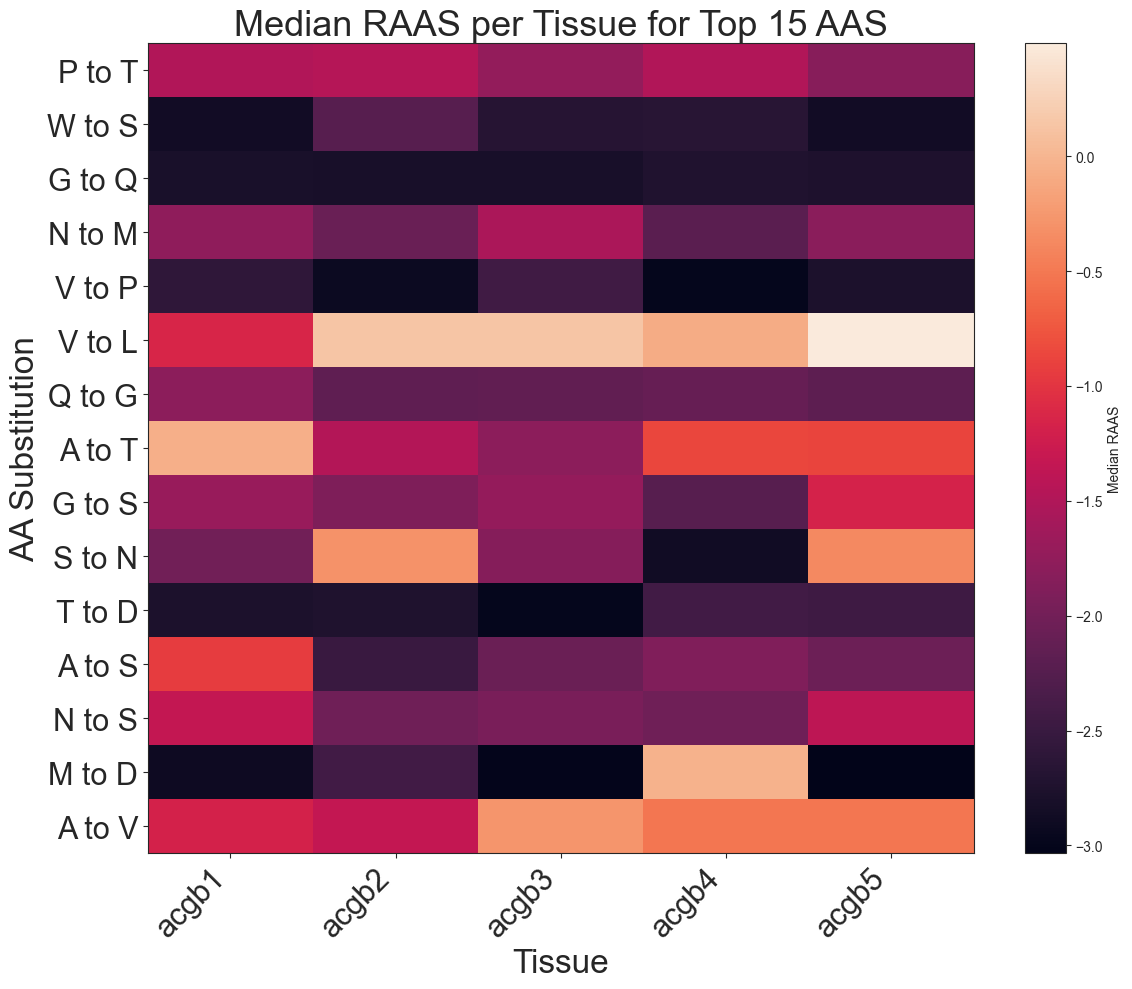

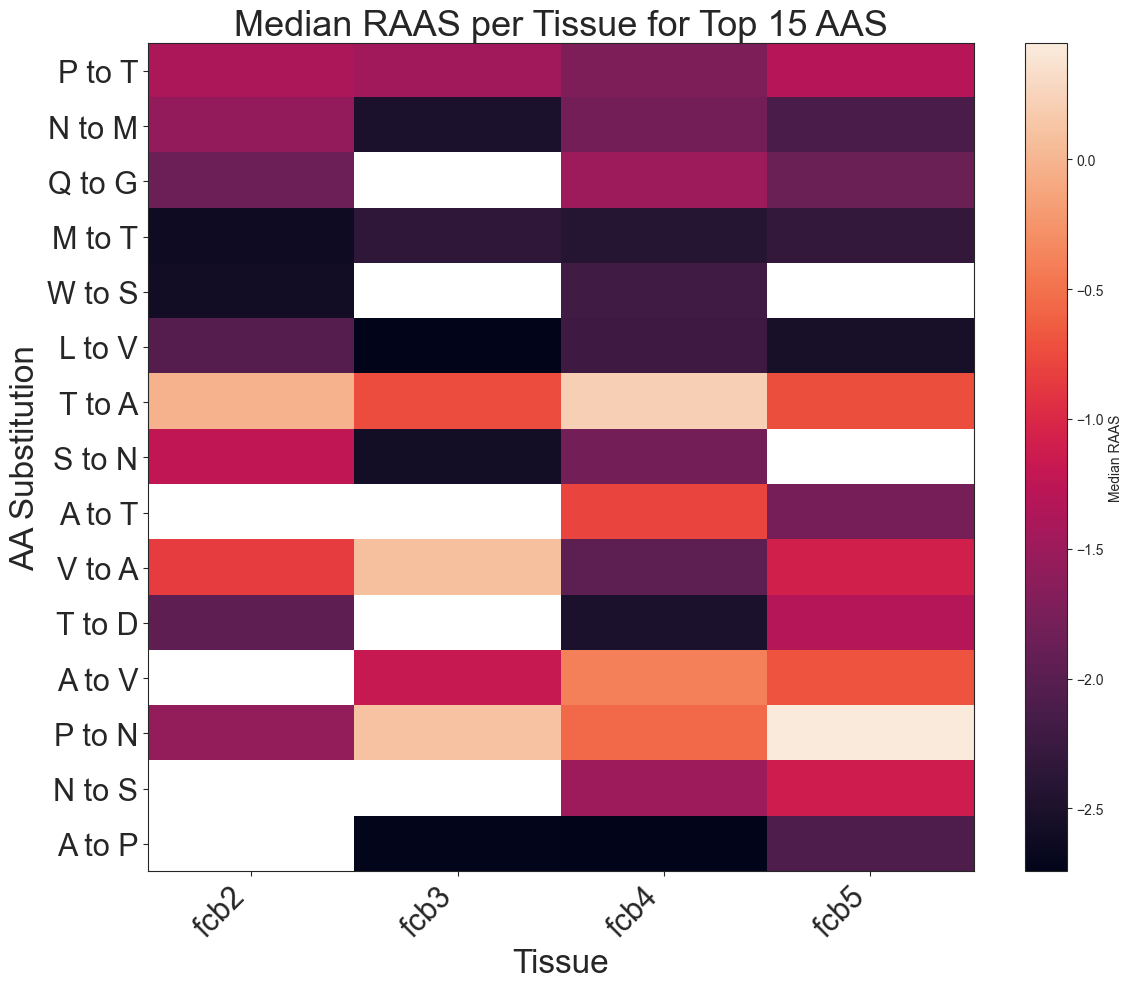

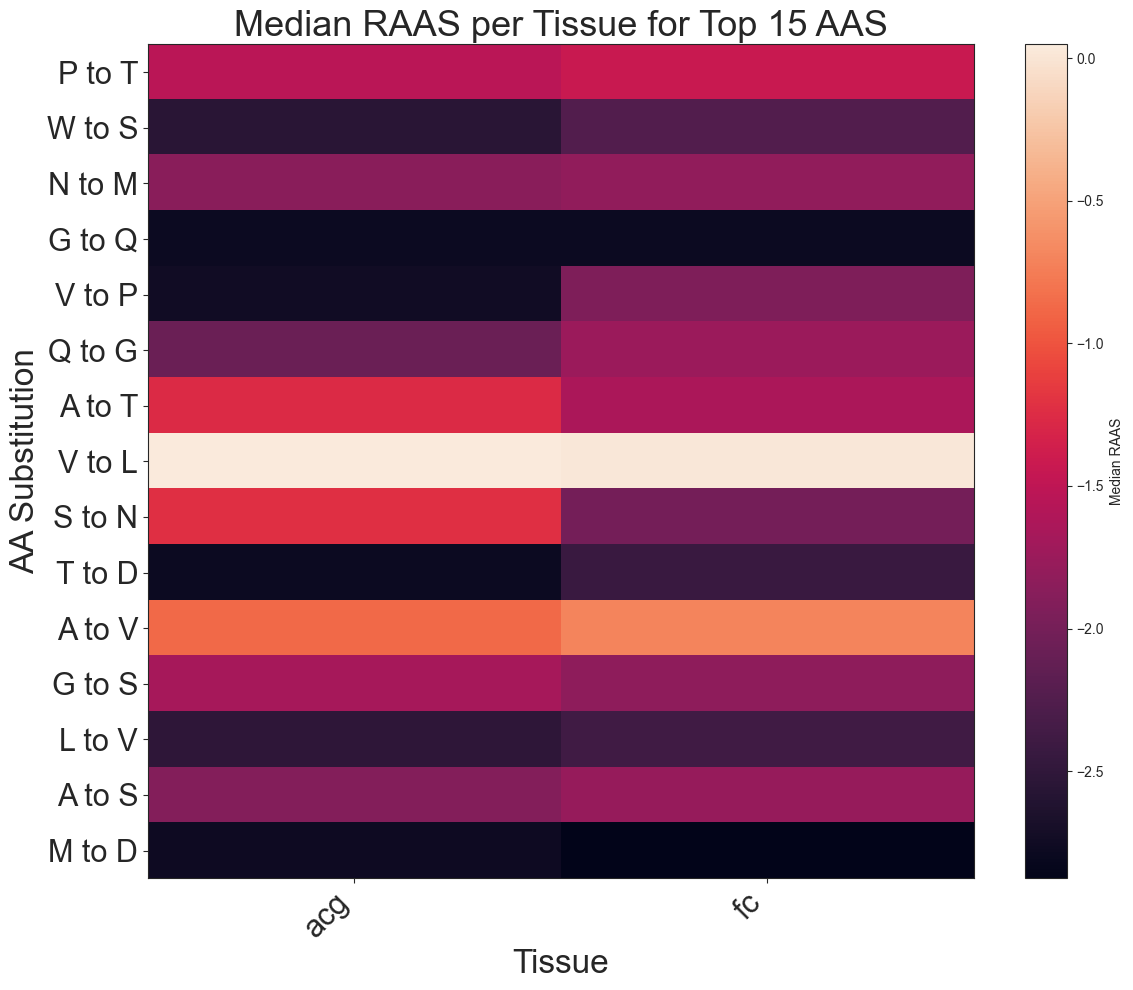

In [372]:
# Compare mean RAAS across tissues per substitution at the tmt set level
sub_df = replicate_cols(SAAP_quant_df_acg)

# Select globally most common substitutions
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Tissue'].dropna().unique())

plot_df['Tissue'] = pd.Categorical(plot_df['Tissue'], categories=tissue_order, ordered=True)
plot_df['aa_sub'] = pd.Categorical(plot_df['aa_sub'], categories=sub_order, ordered=True)

# aggregate RAAS via median 
heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
heatmap_matrix = (heatmap_df.pivot(index='aa_sub',columns='Tissue',values=raas_col).reindex(index=sub_order).reindex(columns=tissue_order))

# Plot heatmap of median RAAS per substitution/tissue combination, with global significance outlines.
plt.figure(figsize=(12,10))
plt.imshow(heatmap_matrix,aspect='auto')
plt.colorbar(label='Median RAAS')
plt.xticks(np.arange(len(tissue_order)), tissue_order, rotation=45, ha='right', fontsize=22)
plt.yticks(np.arange(len(heatmap_matrix.index)), heatmap_matrix.index, fontsize=22)
plt.xlabel('Tissue', fontsize=24)
plt.ylabel('AA Substitution', fontsize=24)
plt.title('Median RAAS per Tissue for Top 15 AAS', fontsize=26)
plt.tight_layout()
plt.grid(False)
plt.savefig(PLOT_DIR + 'top15_substitution_ReporterRAAS_tmtset_heatmap_acg.pdf', bbox_inches='tight')


# Compare mean RAAS across tissues per substitution at the tmt set level
sub_df = replicate_cols(SAAP_quant_df_fc)

# Select globally most common substitutions
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Tissue'].dropna().unique())

plot_df['Tissue'] = pd.Categorical(plot_df['Tissue'], categories=tissue_order, ordered=True)
plot_df['aa_sub'] = pd.Categorical(plot_df['aa_sub'], categories=sub_order, ordered=True)

# aggregate RAAS via median 
heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
heatmap_matrix = (heatmap_df.pivot(index='aa_sub',columns='Tissue',values=raas_col).reindex(index=sub_order).reindex(columns=tissue_order))

# Plot heatmap of median RAAS per substitution/tissue combination, with global significance outlines.
plt.figure(figsize=(12,10))
plt.imshow(heatmap_matrix,aspect='auto')
plt.colorbar(label='Median RAAS')
plt.xticks(np.arange(len(tissue_order)), tissue_order, rotation=45, ha='right', fontsize=22)
plt.yticks(np.arange(len(heatmap_matrix.index)), heatmap_matrix.index, fontsize=22)
plt.xlabel('Tissue', fontsize=24)
plt.ylabel('AA Substitution', fontsize=24)
plt.title('Median RAAS per Tissue for Top 15 AAS', fontsize=26)
plt.tight_layout()
plt.grid(False)
plt.savefig(PLOT_DIR + 'top15_substitution_ReporterRAAS_tmtset_heatmap_fc.pdf', bbox_inches='tight')


# Compare mean RAAS across tissues per substitution at the global level
sub_df = replicate_cols(SAAP_quant_df_grouped)

# Select globally most common substitutions
top_subs = top_sub_order(sub_df, n=15)
plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = plot_df['aa_sub'].value_counts().loc[top_subs].index
tissue_order = sorted(plot_df['Tissue'].dropna().unique())

plot_df['Tissue'] = pd.Categorical(plot_df['Tissue'], categories=tissue_order, ordered=True)
plot_df['aa_sub'] = pd.Categorical(plot_df['aa_sub'], categories=sub_order, ordered=True)

# aggregate RAAS via median 
heatmap_df = (plot_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
heatmap_matrix = (heatmap_df.pivot(index='aa_sub',columns='Tissue',values=raas_col).reindex(index=sub_order).reindex(columns=tissue_order))

# Plot heatmap of median RAAS per substitution/tissue combination, with global significance outlines.
plt.figure(figsize=(12,10))
plt.imshow(heatmap_matrix,aspect='auto')
plt.colorbar(label='Median RAAS')
plt.xticks(np.arange(len(tissue_order)), tissue_order, rotation=45, ha='right', fontsize=22)
plt.yticks(np.arange(len(heatmap_matrix.index)), heatmap_matrix.index, fontsize=22)
plt.xlabel('Tissue', fontsize=24)
plt.ylabel('AA Substitution', fontsize=24)
plt.title('Median RAAS per Tissue for Top 15 AAS', fontsize=26)
plt.tight_layout()
plt.grid(False)
plt.savefig(PLOT_DIR + 'top15_substitution_ReporterRAAS_tissue_heatmap.pdf', bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/2856832255.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df = (plot_df.groupby(['aa_sub','Disease','Tissue'])[raas_col].median().reset_index())


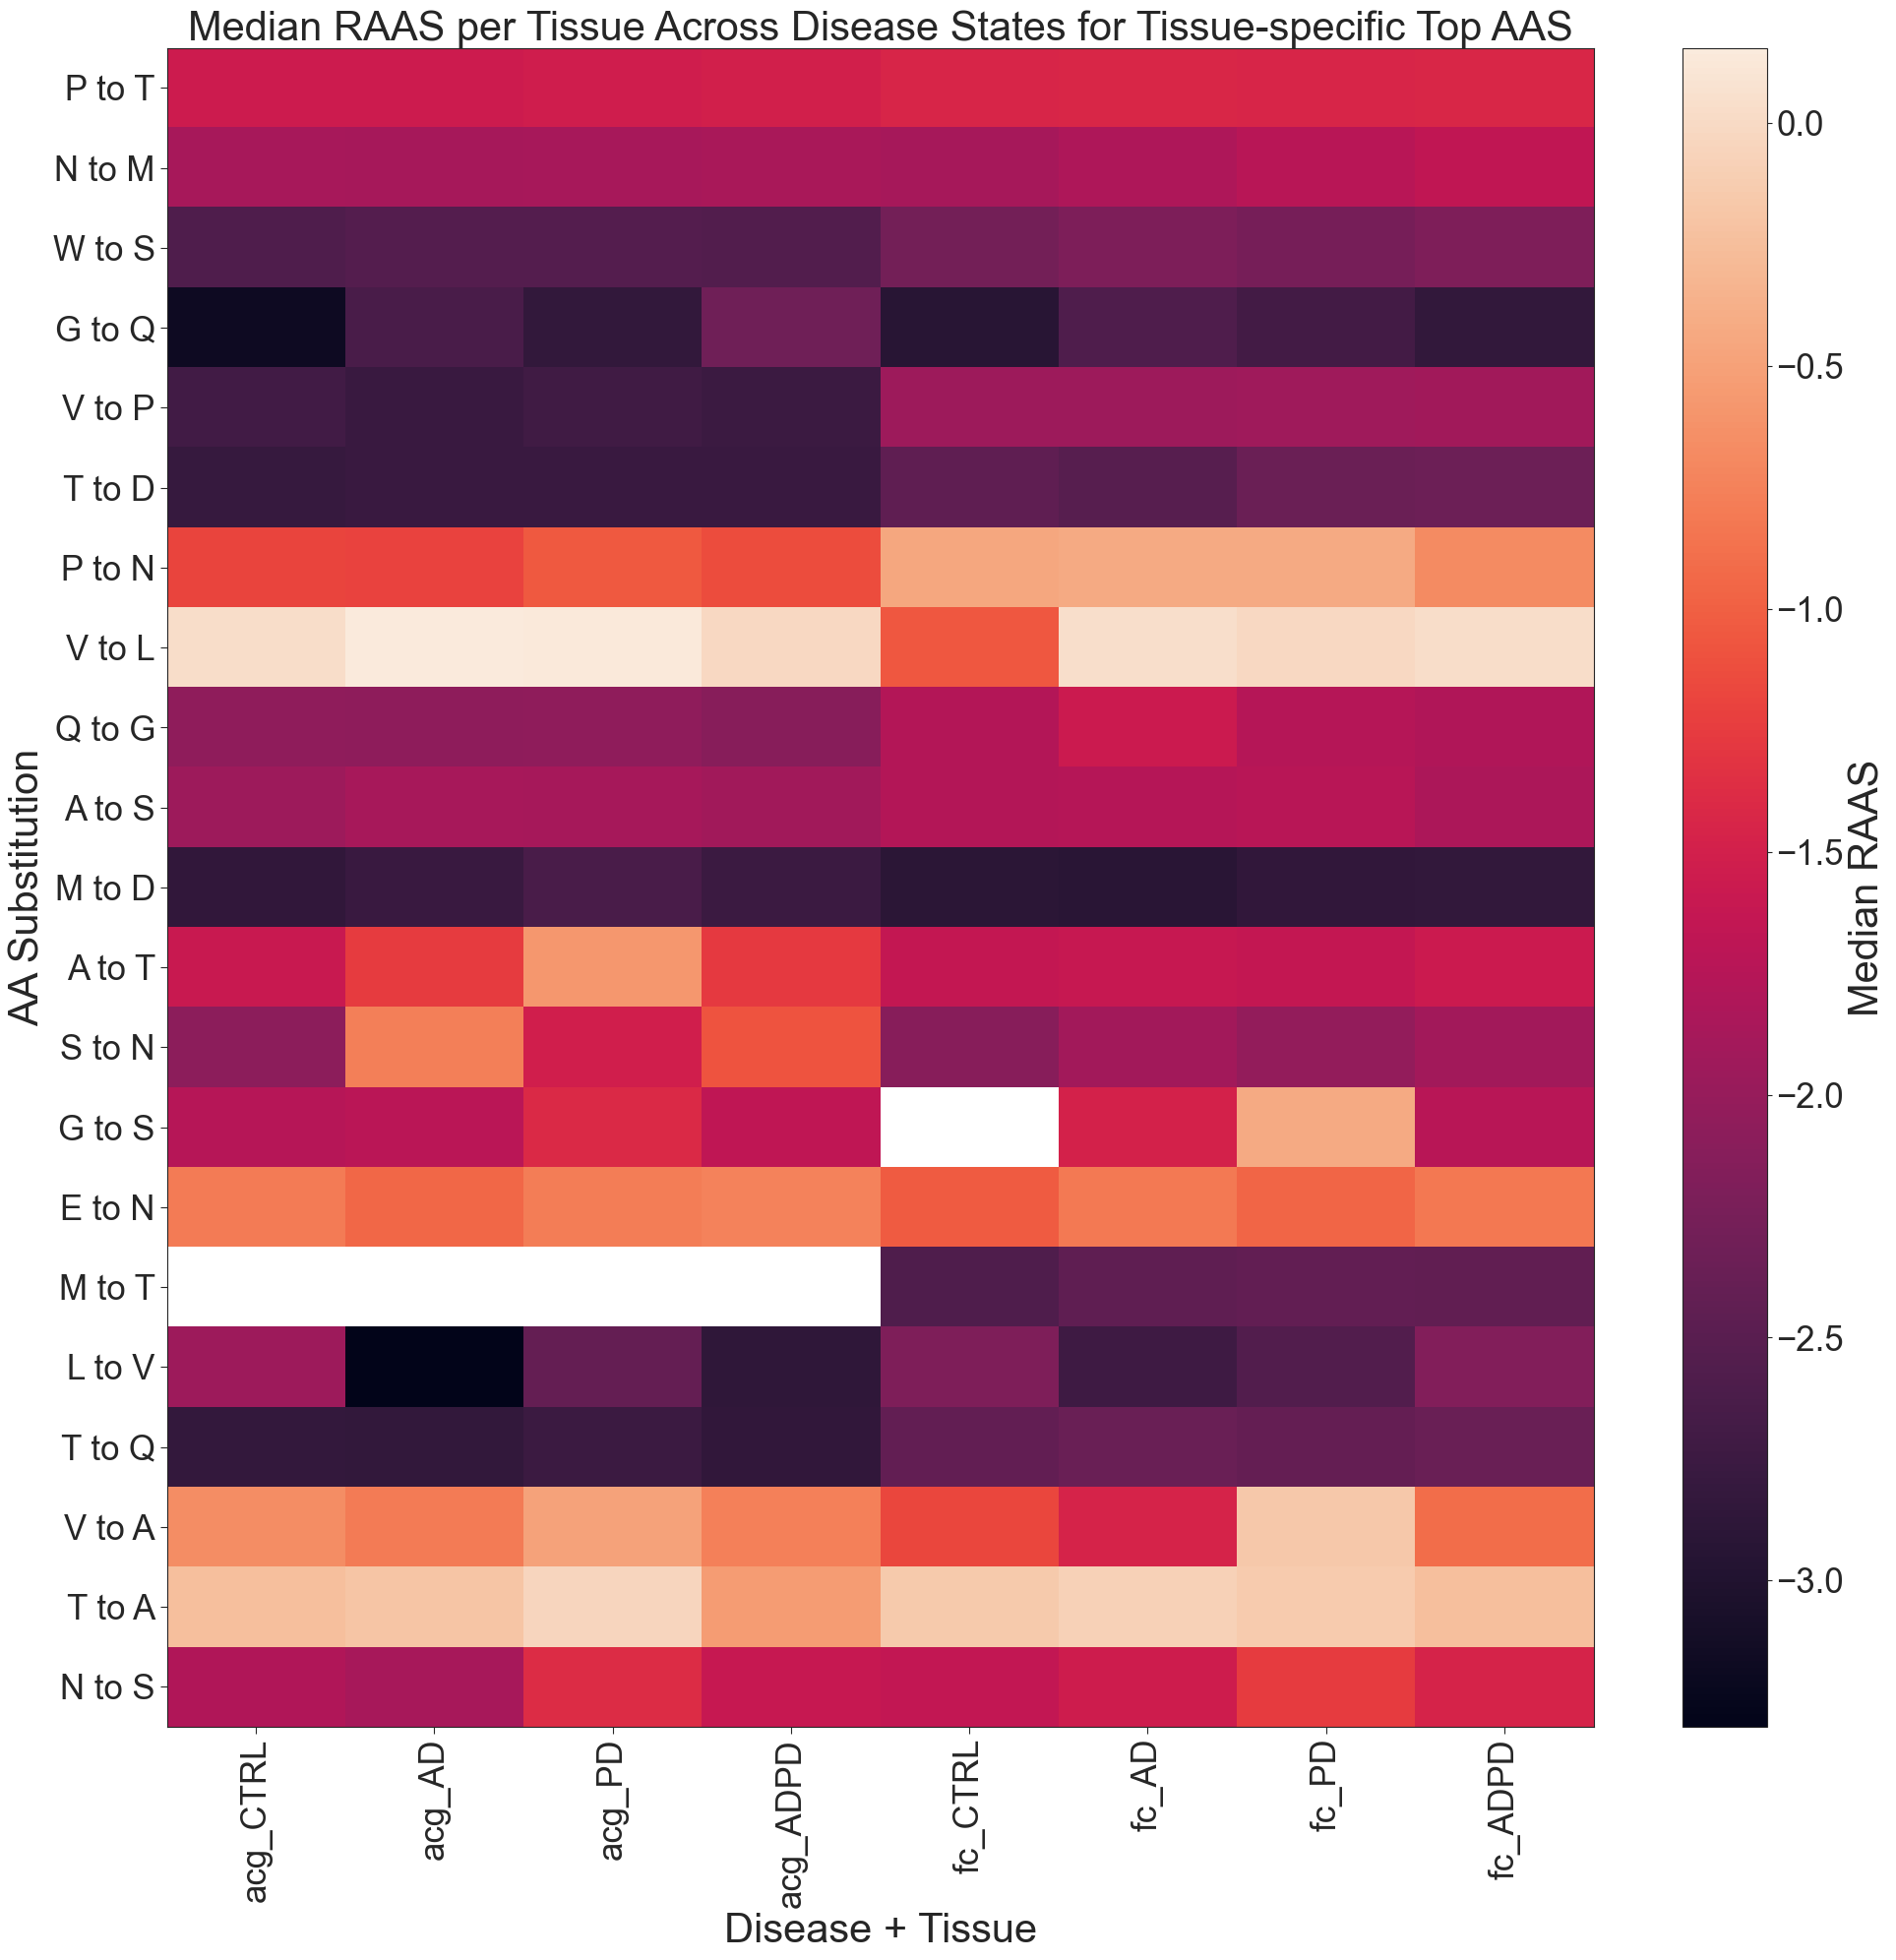

In [377]:
# # Repeat the tissue comparison separately within each disease group for top subs
# sub_df = replicate_cols(SAAP_quant_df_acg)
# top_subs = top_sub_order(sub_df, n=15)
# plot_base_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
# sub_order = plot_base_df['aa_sub'].value_counts().loc[top_subs].index
# tissue_order = sorted(plot_base_df['Tissue'].dropna().unique())

# plot_base_df['aa_sub']=pd.Categorical(plot_base_df['aa_sub'],categories=sub_order,ordered=True)
# plot_base_df['Tissue']=pd.Categorical(plot_base_df['Tissue'],categories=tissue_order,ordered=True)
# plot_base_df['Disease']=pd.Categorical(plot_base_df['Disease'],categories=disease_order,ordered=True)

# # aggregate RAAS via median
# heatmap_df=(plot_base_df.groupby(['aa_sub','Disease','Tissue'])[raas_col].median().reset_index())
# heatmap_df['Tissue_Disease']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Disease'].astype(str)

# column_order=[]
# for tissue in tissue_order:
#     for disease in disease_order:
#         column_order.append(tissue+'_'+disease)

# heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Disease',values=raas_col).reindex(index=sub_order).reindex(columns=column_order))

# # Plot heatmap of median RAAS per substitution/tissue/disease combination
# plt.figure(figsize=(20,10))
# plt.imshow(heatmap_matrix,aspect='auto')
# cbar = plt.colorbar(label='Median RAAS')
# cbar.ax.tick_params(labelsize=25)
# cbar.ax.set_ylabel('Median RAAS', size=30)
# plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=25)
# plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=25)
# plt.xlabel('Disease + Tissue',fontsize=30)
# plt.ylabel('AA Substitution',fontsize=30)
# plt.title('Median RAAS per Tissue Across Disease States for Top 15 AAS',fontsize=30)
# plt.tight_layout()
# plt.grid(False)

# plt.savefig(PLOT_DIR+'top15_substitution_ReporterRAAS_Disease_tissue_heatmap_acg.pdf',bbox_inches='tight')


# # Repeat the tissue comparison separately within each disease group for top subs
# sub_df = replicate_cols(SAAP_quant_df_fc)
# top_subs = top_sub_order(sub_df, n=15)
# plot_base_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
# sub_order = plot_base_df['aa_sub'].value_counts().loc[top_subs].index
# tissue_order = sorted(plot_base_df['Tissue'].dropna().unique())

# plot_base_df['aa_sub']=pd.Categorical(plot_base_df['aa_sub'],categories=sub_order,ordered=True)
# plot_base_df['Tissue']=pd.Categorical(plot_base_df['Tissue'],categories=tissue_order,ordered=True)
# plot_base_df['Disease']=pd.Categorical(plot_base_df['Disease'],categories=disease_order,ordered=True)

# # aggregate RAAS via median
# heatmap_df=(plot_base_df.groupby(['aa_sub','Disease','Tissue'])[raas_col].median().reset_index())
# heatmap_df['Tissue_Disease']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Disease'].astype(str)

# column_order=[]
# for tissue in tissue_order:
#     for disease in disease_order:
#         column_order.append(tissue+'_'+disease)

# heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Disease',values=raas_col).reindex(index=sub_order).reindex(columns=column_order))

# # Plot heatmap of median RAAS per substitution/tissue/disease combination
# plt.figure(figsize=(20,10))
# plt.imshow(heatmap_matrix,aspect='auto')
# cbar = plt.colorbar(label='Median RAAS')
# cbar.ax.tick_params(labelsize=25)
# cbar.ax.set_ylabel('Median RAAS', size=30)
# plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=25)
# plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=25)
# plt.xlabel('Disease + Tissue',fontsize=30)
# plt.ylabel('AA Substitution',fontsize=30)
# plt.title('Median RAAS per Tissue Across Disease States for Top 15 AAS',fontsize=30)
# plt.tight_layout()
# plt.grid(False)

# plt.savefig(PLOT_DIR+'top15_substitution_ReporterRAAS_Disease_tissue_heatmap_fc.pdf',bbox_inches='tight')


# perform the same analysis except for subs most frequent per tissue type 
sub_df = replicate_cols(SAAP_quant_df_grouped)
tissue_order = sorted(sub_df['Tissue'].dropna().unique())

top_subs = []
for tissue in tissue_order:
    tissue_top = (sub_df[sub_df['Tissue'] == tissue][['MTP_seq', 'BP_seq', 'aa_sub']].drop_duplicates()['aa_sub'].value_counts().head(15).index.tolist())
    top_subs.extend(tissue_top)
top_subs = list(dict.fromkeys(top_subs))

plot_df = sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order = (plot_df['aa_sub'].value_counts().reindex(top_subs).dropna().index)

plot_df['aa_sub'] = pd.Categorical(plot_df['aa_sub'],categories=sub_order,ordered=True)
plot_df['Tissue'] = pd.Categorical(plot_df['Tissue'],categories=tissue_order,ordered=True)
plot_df['Disease'] = pd.Categorical(plot_df['Disease'],categories=disease_order,ordered=True)

# aggregate RAAS by median
heatmap_df = (plot_df.groupby(['aa_sub','Disease','Tissue'])[raas_col].median().reset_index())
heatmap_df['Tissue_Disease'] = (heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Disease'].astype(str))
column_order = []
for tissue in tissue_order:
    for Disease in disease_order:
        column_order.append(tissue+'_'+Disease)
heatmap_matrix = (heatmap_df.pivot(index='aa_sub',columns='Tissue_Disease',values=raas_col))

# Plotting heatmap of median RAAS per substitution/tissue/Disease combination
plt.figure(figsize=(20,20))
plt.imshow(heatmap_matrix, aspect='auto')
cbar = plt.colorbar(label='Median RAAS')
cbar.ax.tick_params(labelsize=25)
cbar.ax.set_ylabel('Median RAAS', size=30)
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=25)
plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=25)
plt.xlabel('Disease + Tissue', fontsize=30)
plt.ylabel('AA Substitution', fontsize=30)
plt.title('Median RAAS per Tissue Across Disease States for Tissue-specific Top AAS', fontsize=30)
plt.tight_layout()
plt.tick_params(axis='both', length=5)
plt.grid(False)
plt.savefig(PLOT_DIR + 'top_substitution_ReporterRAAS_Disease_tissue_heatmap.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/2552268047.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df=(norm_df.groupby(['aa_sub','Disease','Tissue'])['log2FC_vs_t06mo'].median().reset_index())


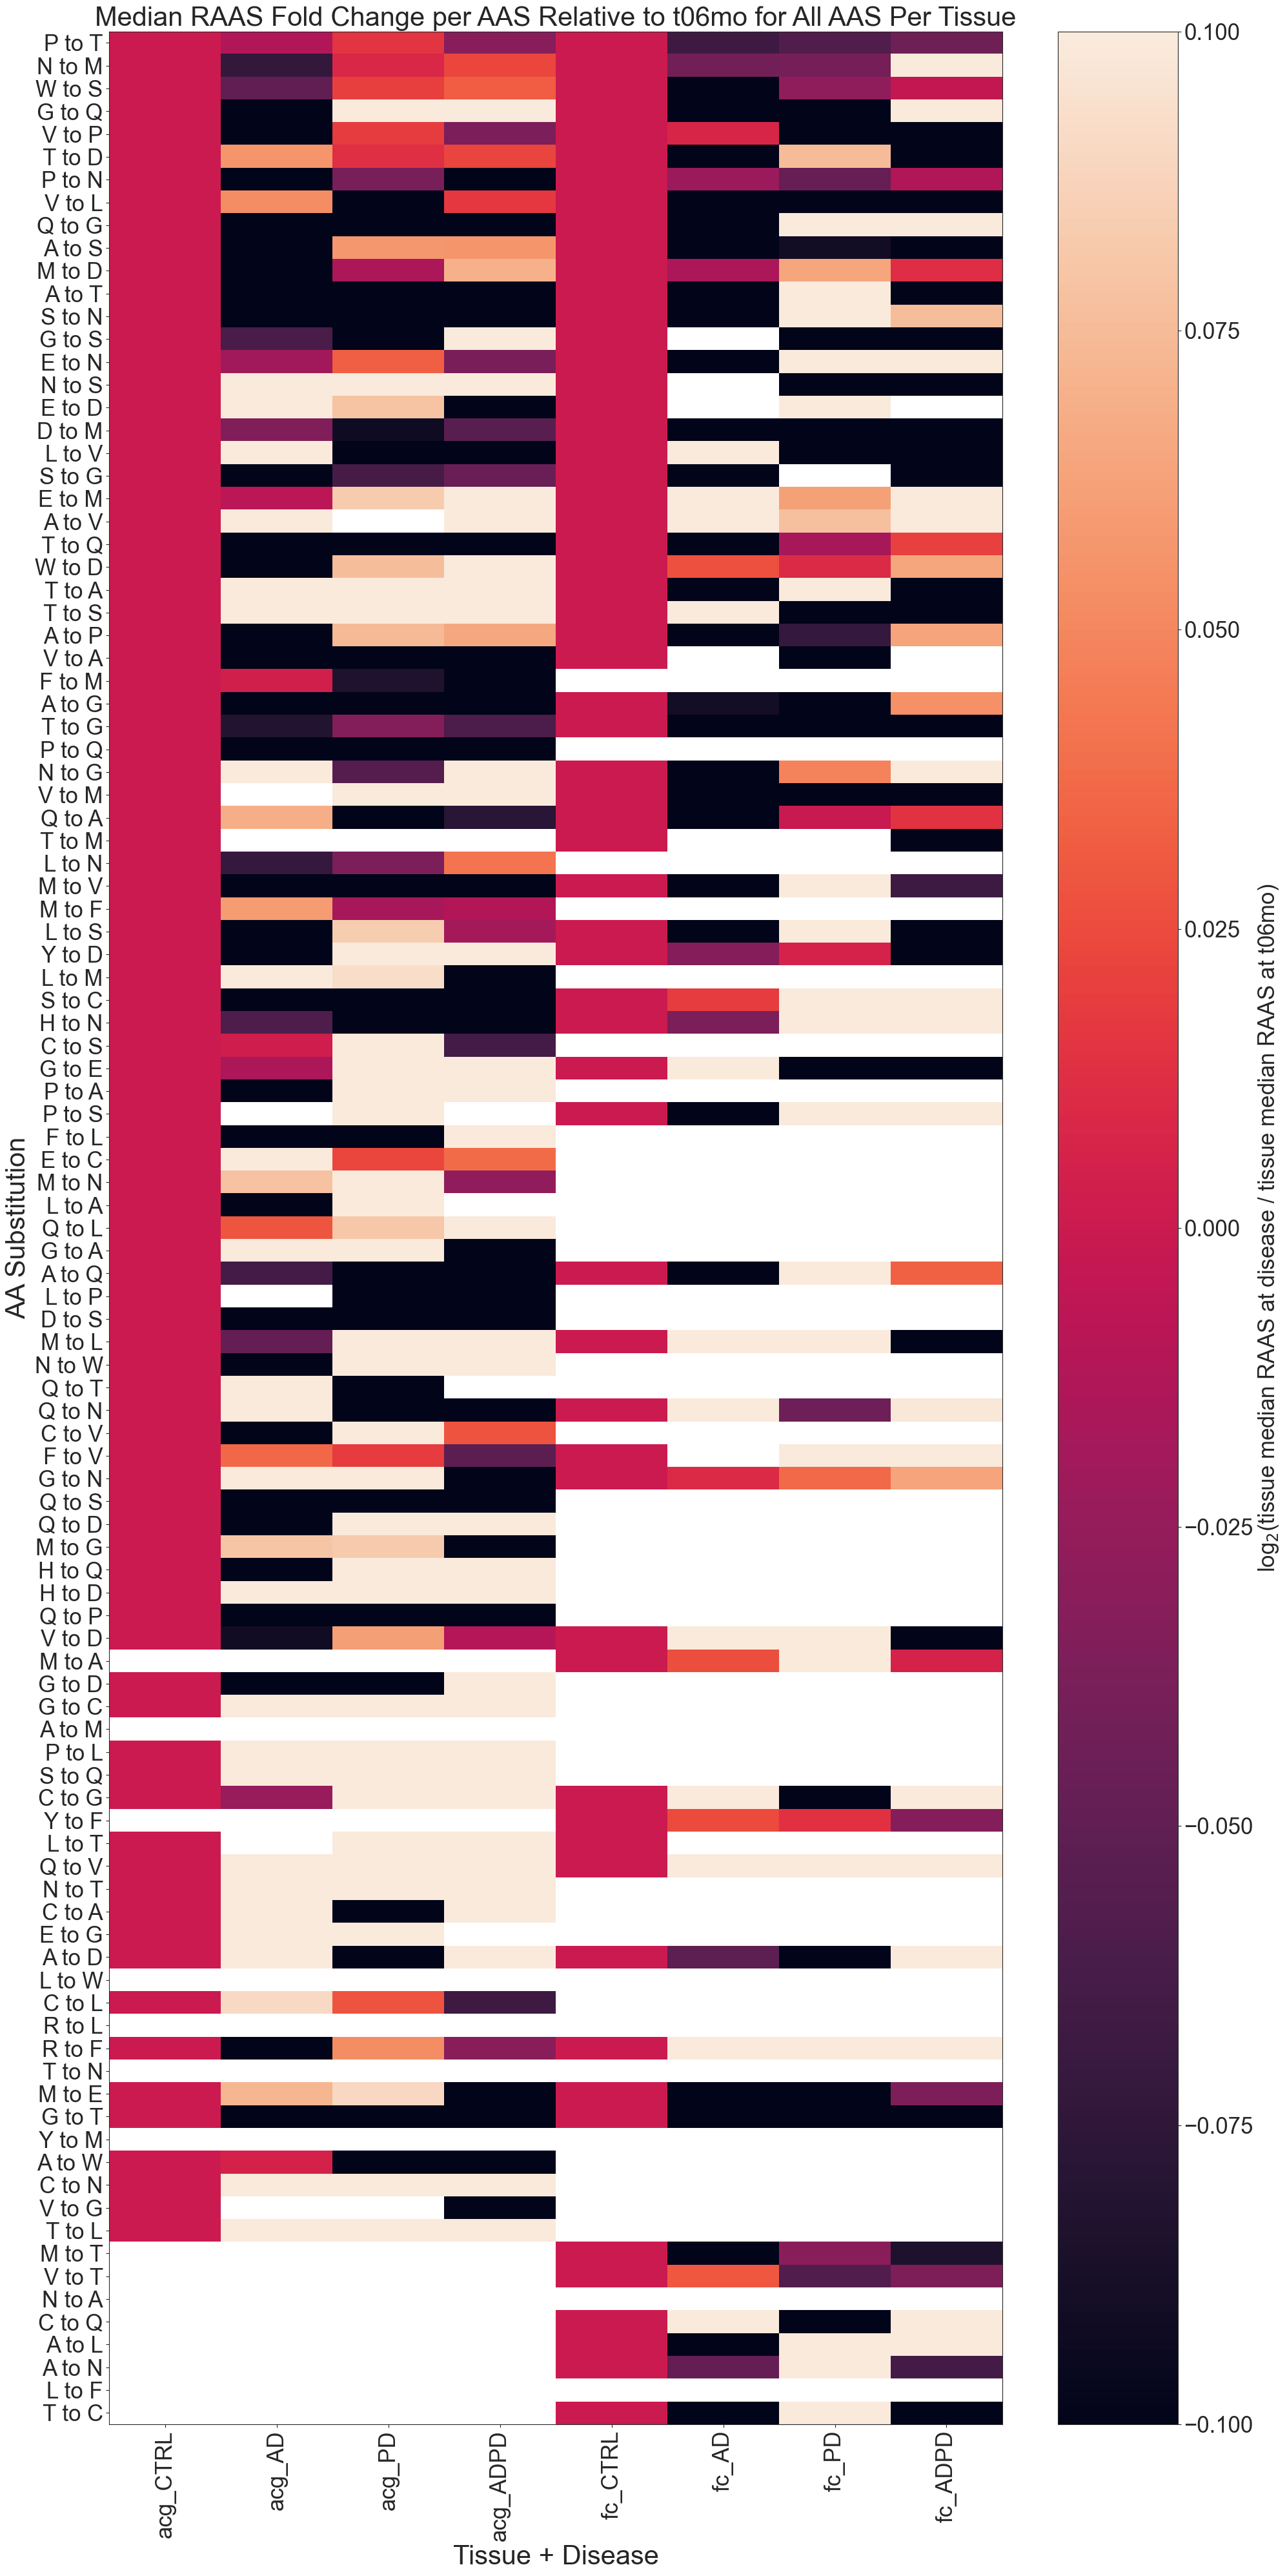

In [380]:
# Repeat the tissue comparison separately within each Disease group using log2 fold change relative to tissue-specific healthy baselines.
ctrl_label='CTRL'
peptide_keys=['Dataset','MTP_seq','BP_seq','aa_sub']
sub_df=replicate_cols(SAAP_quant_df_grouped)
tissue_order=sorted(sub_df['Tissue'].dropna().unique())

top_subs=[]
for tissue in tissue_order: 
    tissue_top=(sub_df[sub_df['Tissue']==tissue][['MTP_seq','BP_seq','aa_sub']].drop_duplicates()['aa_sub'].value_counts().head(5000).index.tolist())
    top_subs.extend(tissue_top)
top_subs=list(dict.fromkeys(top_subs))

plot_base_df=sub_df[sub_df['aa_sub'].isin(top_subs)].copy()
sub_order=(plot_base_df['aa_sub'].value_counts().reindex(top_subs).dropna().index)
plot_base_df['log10_RAAS']=plot_base_df[raas_col]

saap_age_median_df=(plot_base_df.groupby(peptide_keys+['Disease'],observed=False)['log10_RAAS'].median().reset_index().rename(columns={'log10_RAAS':'median_log10_RAAS'}))
ctrl_df=(saap_age_median_df[saap_age_median_df['Disease']==ctrl_label][peptide_keys+['median_log10_RAAS']].rename(columns={'median_log10_RAAS':'median_log10_RAAS_t06mo'}))
norm_df=saap_age_median_df.merge(ctrl_df,on=peptide_keys,how='left')
norm_df['log2FC_vs_t06mo']=(norm_df['median_log10_RAAS']-norm_df['median_log10_RAAS_t06mo'])*np.log2(10)
norm_df=norm_df.dropna(subset=['log2FC_vs_t06mo']).copy()
norm_df['Tissue']=norm_df['Dataset']
norm_df['aa_sub']=pd.Categorical(norm_df['aa_sub'],categories=sub_order,ordered=True)
norm_df['Tissue']=pd.Categorical(norm_df['Tissue'],categories=tissue_order,ordered=True)
norm_df['Disease']=pd.Categorical(norm_df['Disease'],categories=disease_order,ordered=True)

# aggregate log2FC via median
heatmap_df=(norm_df.groupby(['aa_sub','Disease','Tissue'])['log2FC_vs_t06mo'].median().reset_index())
heatmap_df['Tissue_Disease']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Disease'].astype(str)

column_order=[]
for tissue in tissue_order:
    for Disease in disease_order: column_order.append(tissue+'_'+Disease)

heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Disease',values='log2FC_vs_t06mo').reindex(index=sub_order).reindex(columns=column_order))
max_abs=np.nanmax(np.abs(heatmap_matrix.values))

# Plot heatmap of median log2FC relative to t06mo
plt.figure(figsize=(20,40))
plt.imshow(heatmap_matrix,aspect='auto',vmin=-max_abs,vmax=max_abs)
cbar = plt.colorbar(label=r'log$_2$(tissue median RAAS at disease / tissue median RAAS at t06mo)')
cbar.ax.tick_params(labelsize=25)
cbar.ax.set_ylabel(r'log$_2$(tissue median RAAS at disease / tissue median RAAS at t06mo)', size=25)
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=25)
plt.yticks(np.arange(len(heatmap_matrix.index)),heatmap_matrix.index,fontsize=25)
plt.xlabel('Tissue + Disease',fontsize=30)
plt.ylabel('AA Substitution',fontsize=30)
# plt.title('Median RAAS Fold Change per AAS Relative to t06mo for Most Frequent AAS Per Tissue',fontsize=26)
plt.title('Median RAAS Fold Change per AAS Relative to t06mo for All AAS Per Tissue',fontsize=30)
plt.tight_layout()
plt.grid(False)

plt.savefig(PLOT_DIR+'top_substitution_ReporterRAAS_disease_tissue_heatmap.pdf',bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/698975417.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_df=(plot_df.groupby(['aa_sub','Tissue','Group'])['log2FC_vs_t06mo'].median().reset_index())


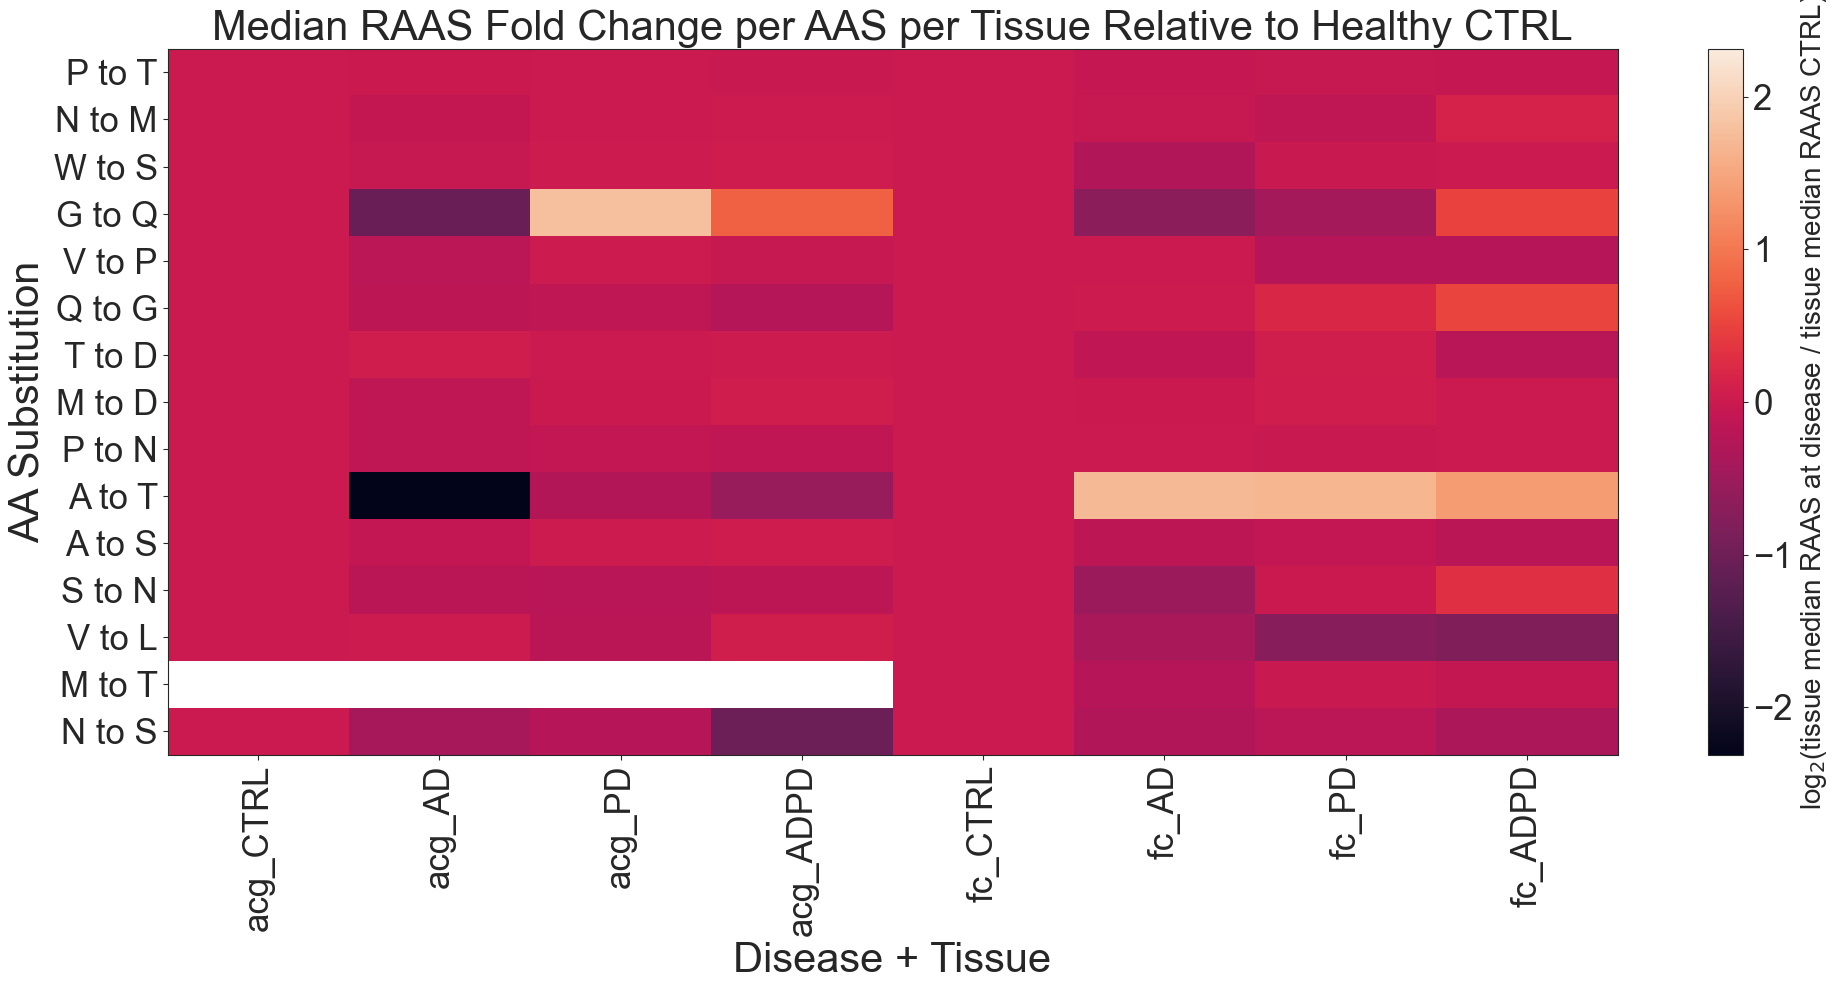

In [384]:
# Compute SAAP-level log2 fold change in median RAAS relative to each SAAP's healthy baseline.
ctrl_label='CTRL'
peptide_keys=['Dataset','MTP_seq','BP_seq','aa_sub']
sub_df=replicate_cols(SAAP_quant_df_grouped)
sub_df['Group']=sub_df['Disease']

# Reporter_RAAS is already log10 RAAS.
sub_df['log10_RAAS']=sub_df[raas_col]
sub_df=sub_df.replace([np.inf,-np.inf],np.nan).dropna(subset=['log10_RAAS'])
saap_age_median_df=(sub_df.groupby(peptide_keys+['Group'],observed=False)['log10_RAAS'].median().reset_index().rename(columns={'log10_RAAS':'median_log10_RAAS'}))
ctrl_df=(saap_age_median_df[saap_age_median_df['Group']==ctrl_label][peptide_keys+['median_log10_RAAS']].rename(columns={'median_log10_RAAS':'median_log10_RAAS_t06mo'}))
norm_df=saap_age_median_df.merge(ctrl_df,on=peptide_keys,how='left')
norm_df['log2FC_vs_t06mo']=(norm_df['median_log10_RAAS']-norm_df['median_log10_RAAS_t06mo'])*np.log2(10)
norm_df=norm_df.dropna(subset=['log2FC_vs_t06mo']).copy()
norm_df['Tissue']=norm_df['Dataset']
top_subs=(norm_df['aa_sub'].value_counts().head(15).index)

plot_df=norm_df[norm_df['aa_sub'].isin(top_subs)&norm_df['Group'].isin(disease_order)].copy()
sub_order=(plot_df['aa_sub'].value_counts().loc[top_subs].index)
tissue_order=sorted(plot_df['Tissue'].dropna().unique())
plot_df['aa_sub']=pd.Categorical(plot_df['aa_sub'],categories=sub_order,ordered=True)
plot_df['Group']=pd.Categorical(plot_df['Group'],categories=disease_order,ordered=True)
plot_df['Tissue']=pd.Categorical(plot_df['Tissue'],categories=tissue_order,ordered=True)

# aggregate log2FC via median
heatmap_df=(plot_df.groupby(['aa_sub','Tissue','Group'])['log2FC_vs_t06mo'].median().reset_index())
heatmap_df['Tissue_Disease']=heatmap_df['Tissue'].astype(str)+'_'+heatmap_df['Group'].astype(str)

column_order=[]
for tissue in tissue_order:
    for Disease in disease_order: column_order.append(tissue+'_'+Disease)

heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue_Disease',values='log2FC_vs_t06mo').reindex(index=sub_order).reindex(columns=column_order))

# symmetric color scale around zero
max_abs=np.nanmax(np.abs(heatmap_matrix.values))

# Plot heatmap of median log2FC relative to healthy CTRL
plt.figure(figsize=(20,10))
plt.imshow(heatmap_matrix,aspect='auto',vmin=-max_abs,vmax=max_abs)
cbar = plt.colorbar(label=r'log$_2$(tissue median RAAS at disease / tissue median RAAS CTRL)')
cbar.ax.tick_params(labelsize=25)
cbar.ax.set_ylabel(r'log$_2$(tissue median RAAS at disease / tissue median RAAS CTRL)', size=20)
plt.xticks(np.arange(len(column_order)),column_order,rotation=90,fontsize=25)
plt.yticks(np.arange(len(sub_order)),sub_order,fontsize=25)
plt.xlabel('Disease + Tissue',fontsize=30)
plt.ylabel('AA Substitution',fontsize=30)
plt.title('Median RAAS Fold Change per AAS per Tissue Relative to Healthy CTRL',fontsize=30)
plt.tight_layout()
plt.grid(False)

plt.savefig(PLOT_DIR+'top15_substitution_log2_median_RAAS_over_CTRL_heatmap.pdf',bbox_inches='tight')
plt.show()

## Statistical Analysis of AAS Type Trends between Tissues and with Aging

In [472]:
# Test whether RAAS changes between tissues within AAS type are statistically significant
# using one-way ANOVA with post-hoc Tukey HSD testing
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
min_saap=3
min_obs=3
pairwise_cols=lambda tissues:[f'{a}_vs_{b}' for a,b in combinations(tissues,2)]
def run_anova_by_tissue(sub_df,outfile):
    peptide_keys=['Tissue','MTP_seq','BP_seq','aa_sub']
    tissue_order=sorted(sub_df['Tissue'].dropna().unique())
    saap_df=(sub_df.groupby(peptide_keys+['Disease'])[raas_col].median().reset_index())
    saap_df=saap_df.replace([np.inf,-np.inf],np.nan)
    saap_df=saap_df.dropna(subset=[raas_col])
    saap_tissue_counts=saap_df.groupby(['MTP_seq','BP_seq','aa_sub'])['Tissue'].nunique().reset_index(name='n_tissues')
    valid_saaps=saap_tissue_counts[saap_tissue_counts['n_tissues']==len(tissue_order)]
    saap_df=saap_df.merge(valid_saaps[['MTP_seq','BP_seq','aa_sub']],on=['MTP_seq','BP_seq','aa_sub'])
    shared_subs=saap_df['aa_sub'].unique()
    pair_cols=pairwise_cols(tissue_order)
    results=[]
    for sub in shared_subs:
        curr=saap_df[saap_df['aa_sub']==sub]
        n_saap=curr[['MTP_seq','BP_seq']].drop_duplicates().shape[0]
        if n_saap<min_saap: continue
        counts=curr.groupby('Tissue').size()
        valid_tissues=counts[counts>=min_obs].index
        curr=curr[curr['Tissue'].isin(valid_tissues)]
        sub_tissues=sorted(curr['Tissue'].dropna().unique())
        if len(sub_tissues)<2: continue
        groups=[curr.loc[curr['Tissue']==t,raas_col].dropna().values for t in sub_tissues]
        groups=[g for g in groups if len(g)>0]
        if len(groups)<2: continue
        F,p=stats.f_oneway(*groups)
        tukey=pairwise_tukeyhsd(endog=curr[raas_col],groups=curr['Tissue'])
        tukey_df=pd.DataFrame(tukey._results_table.data[1:],columns=tukey._results_table.data[0])
        sig=[]
        pair_results={c:'' for c in pair_cols}
        for _,row in tukey_df.iterrows():
            g1=row['group1']
            g2=row['group2']
            diff=pd.to_numeric(row['meandiff'],errors='coerce')
            q=pd.to_numeric(row['p-adj'],errors='coerce')
            if pd.isna(diff) or pd.isna(q) or np.isinf(diff) or np.isinf(q): continue
            if q<0.001: siglab='***'
            elif q<0.01: siglab='**'
            elif q<0.05: siglab='*'
            else: siglab='ns'
            higher,lower=(g1,g2) if diff>0 else (g2,g1)
            txt=f'{higher}>{lower} (Δ={abs(diff):.3f}, q={q:.5e}, {siglab})'
            if q<0.01: sig.append(txt)
            pair_results['_vs_'.join(sorted([g1,g2]))]=txt
        results.append([sub,n_saap,len(sub_tissues),F,p,add_sig_label(p),len(sig),'; '.join(sig)]+[pair_results[c] for c in pair_cols])
    results=pd.DataFrame(results,columns=['AAS_type','n_saap','n_tissues','F','p','Significance','n_sig_pairs','Tukey_significant_pairs']+pair_cols)
    results=run_fdr(results,p_col='p')
    results=results.sort_values(['FDR','p','F'],ascending=[True,True,False])
    results.to_csv(outfile,sep='\t',index=False)
    print(results)

# pooled tissues
sub_df=replicate_cols(SAAP_quant_df_grouped)
run_anova_by_tissue(sub_df=sub_df,outfile=OUTDIR+'ANOVAwTukey_RAASBetweenTissuesperAASType_table.tsv')

   AAS_type  n_saap  n_tissues          F             p Significance  \
7    W to S      11          2  33.987214  9.467910e-08          ***   
3    Q to G       9          2  28.998435  9.442146e-07          ***   
13   A to G       4          2   4.647301  4.092270e-02            *   
5    A to T       3          2   3.229580  8.911850e-02           ns   
2    A to V       4          2   2.572617  1.223729e-01           ns   
15   G to Q       4          2   1.641404  2.099482e-01           ns   
8    T to D       3          2   0.788022  3.843015e-01           ns   
11   M to D       4          2   0.695276  4.109660e-01           ns   
4    N to M       3          2   0.396163  5.355596e-01           ns   
14   L to V       4          2   0.279535  6.013256e-01           ns   
0    P to T      18          2   0.185906  6.670290e-01           ns   
12   V to L       3          2   0.175515  6.793186e-01           ns   
10   V to A       3          2   0.061734  8.067524e-01         

   Tissue  aa_sub  n_saap          F             p  n_diseases       FDR  \
20    acg  G to Q      30  15.125410  2.261763e-08           4  0.000001   
18    acg  A to T       5   1.001255  4.177063e-01           4  0.999997   
39    acg  W to D       6   0.575552  6.377276e-01           4  0.999997   
38    acg  L to V       5   0.432965  7.323054e-01           4  0.999997   
13    acg  A to V       3   0.340878  7.966634e-01           4  0.999997   
..    ...     ...     ...        ...           ...         ...       ...   
62     fc  V to T       3   0.010183  9.984708e-01           4  0.999997   
46     fc  A to P       4   0.008430  9.988758e-01           4  0.999997   
58     fc  T to G       3   0.005889  9.993238e-01           4  0.999997   
57     fc  P to N       3   0.004535  9.995423e-01           4  0.999997   
54     fc  M to D       5   0.003382  9.997167e-01           4  0.999997   

   Significance  
20          ***  
18           ns  
39           ns  
38           ns

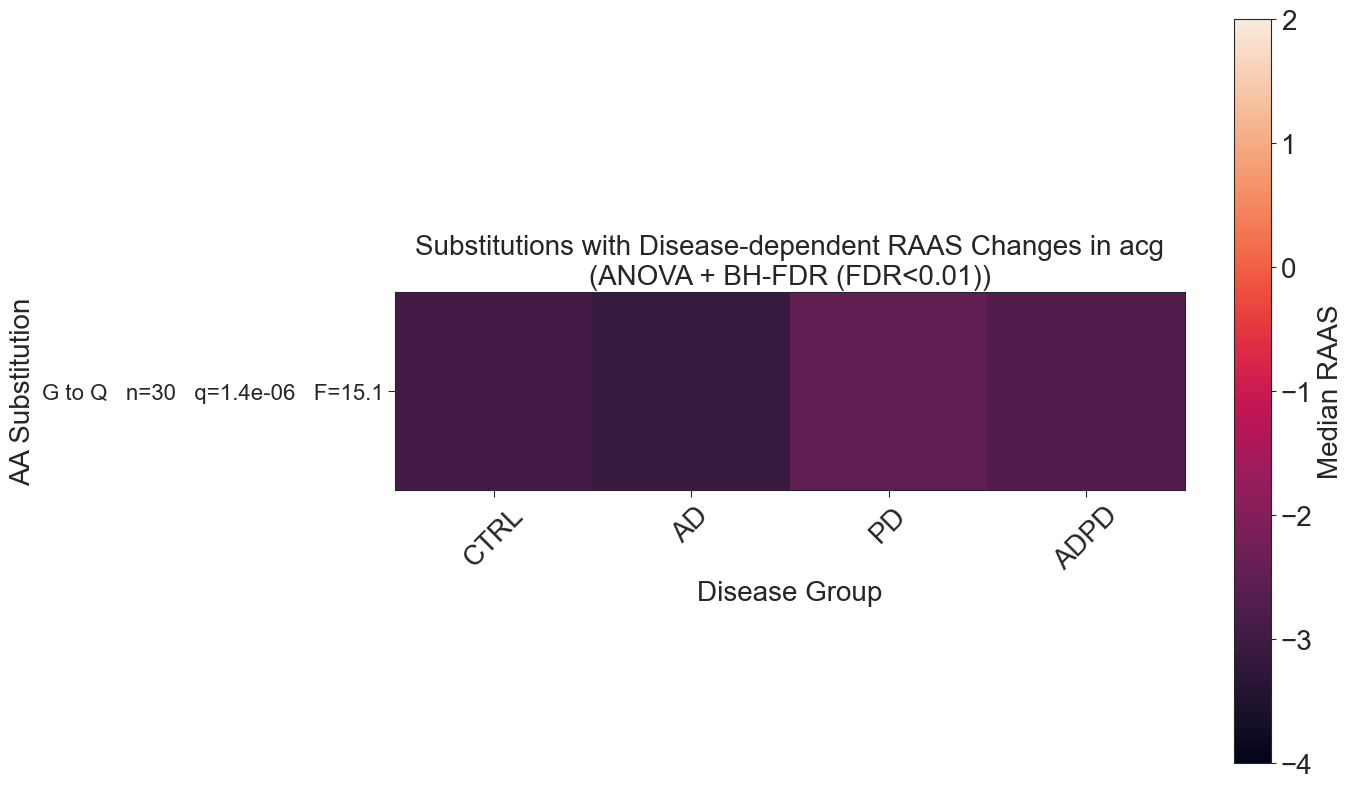

In [470]:
# are any of the variations in RAAS associated with disease state within a tissue statistically significant?
# ANOVA to identify AAS types that differ significantly in RAAS values across disease groups
from scipy import stats
min_saap=3
min_obs=3
peptide_keys=['Tissue','MTP_seq','BP_seq','aa_sub']
sub_df=replicate_cols(SAAP_quant_df_grouped)
disease_order=['CTRL','AD','PD','ADPD']
saap_df=(sub_df.groupby(peptide_keys+['Disease'])[raas_col].median().reset_index())
saap_df=saap_df.replace([np.inf,-np.inf],np.nan)
saap_df=saap_df.dropna(subset=[raas_col])
saap_disease_counts=saap_df.groupby(['Tissue','MTP_seq','BP_seq','aa_sub'])['Disease'].nunique().reset_index(name='n_diseases')
valid_saaps=saap_disease_counts[saap_disease_counts['n_diseases']==len(disease_order)]
saap_df=saap_df.merge(valid_saaps[['Tissue','MTP_seq','BP_seq','aa_sub']],on=['Tissue','MTP_seq','BP_seq','aa_sub'])
results=[]
for tissue in sorted(saap_df['Tissue'].dropna().unique()):
    tissue_df=saap_df[saap_df['Tissue']==tissue]
    for sub in tissue_df['aa_sub'].dropna().unique():
        curr=tissue_df[tissue_df['aa_sub']==sub]
        n_saap=curr[['MTP_seq','BP_seq']].drop_duplicates().shape[0]
        if n_saap<min_saap: continue
        counts=curr.groupby('Disease').size()
        valid_diseases=counts[counts>=min_obs].index
        curr=curr[curr['Disease'].isin(valid_diseases)]
        sub_diseases=[d for d in disease_order if d in curr['Disease'].unique()]
        if len(sub_diseases)!=4: continue
        groups=[curr.loc[curr['Disease']==d,raas_col].dropna().values for d in sub_diseases]
        groups=[g for g in groups if len(g)>0]
        if len(groups)<2: continue
        F,p=stats.f_oneway(*groups)
        results.append([tissue,sub,n_saap,F,p,len(sub_diseases)])
results=pd.DataFrame(results,columns=['Tissue','aa_sub','n_saap','F','p','n_diseases'])
results=run_fdr(results,p_col='p')
results['Significance']=results['FDR'].apply(add_sig_label)
results=results.sort_values(['Tissue','FDR','F'],ascending=[True,True,False])
significant_subs=results.loc[results['FDR']<0.01,['Tissue','aa_sub']]
heatmap_df=(saap_df.groupby(['Tissue','aa_sub','Disease'])[raas_col].median().reset_index())
stats_lookup=results.set_index(['Tissue','aa_sub'])
for tissue in sorted(significant_subs['Tissue'].unique()):
    tissue_subs=significant_subs.loc[significant_subs['Tissue']==tissue,'aa_sub']
    tissue_heatmap=heatmap_df[(heatmap_df['Tissue']==tissue)&(heatmap_df['aa_sub'].isin(tissue_subs))]
    heatmap_matrix=(tissue_heatmap.pivot(index='aa_sub',columns='Disease',values=raas_col))
    heatmap_matrix=heatmap_matrix.reindex(index=tissue_subs)
    heatmap_matrix=heatmap_matrix.reindex(columns=disease_order)
    row_labels=[f'{sub}   n={stats_lookup.loc[(tissue,sub),"n_saap"]}   q={stats_lookup.loc[(tissue,sub),"FDR"]:.1e}   F={stats_lookup.loc[(tissue,sub),"F"]:.1f}' for sub in heatmap_matrix.index]
    plt.figure(figsize=(14,max(8,len(heatmap_matrix)*0.45)))
    plt.imshow(heatmap_matrix,vmin=-4,vmax=2)
    cbar=plt.colorbar(label='Median RAAS')
    cbar.ax.tick_params(labelsize=20)
    cbar.ax.set_ylabel('Median RAAS',size=20)
    plt.xticks(np.arange(len(heatmap_matrix.columns)),heatmap_matrix.columns,rotation=45,fontsize=20)
    plt.yticks(np.arange(len(heatmap_matrix.index)),row_labels,fontsize=16)
    plt.xlabel('Disease Group',fontsize=20)
    plt.ylabel('AA Substitution',fontsize=20)
    plt.title(f'Substitutions with Disease-dependent RAAS Changes in {tissue}\n(ANOVA + BH-FDR (FDR<0.01))',fontsize=20)
    plt.tight_layout()
    plt.grid(False)
    plt.tick_params(axis='both',length=5)
    plt.savefig(PLOT_DIR+f'ANOVA_significant_disease_heatmap_{tissue}.pdf',bbox_inches='tight')
results.to_csv(OUTDIR+'ANOVA_disease_statistics.tsv',sep='\t',index=False)
print(results)

    aa_sub  n_saap          F             p  n_tissues       FDR Significance
7   W to S      11  33.987214  9.467910e-08          2  0.000002          ***
3   Q to G       9  28.998435  9.442146e-07          2  0.000008          ***
13  A to G       4   4.647301  4.092270e-02          2  0.218254           ns
5   A to T       3   3.229580  8.911850e-02          2  0.356474           ns
2   A to V       4   2.572617  1.223729e-01          2  0.391593           ns
15  G to Q       4   1.641404  2.099482e-01          2  0.559862           ns
8   T to D       3   0.788022  3.843015e-01          2  0.821932           ns
11  M to D       4   0.695276  4.109660e-01          2  0.821932           ns
4   N to M       3   0.396163  5.355596e-01          2  0.905758           ns
14  L to V       4   0.279535  6.013256e-01          2  0.905758           ns
0   P to T      18   0.185906  6.670290e-01          2  0.905758           ns
12  V to L       3   0.175515  6.793186e-01          2  0.905758

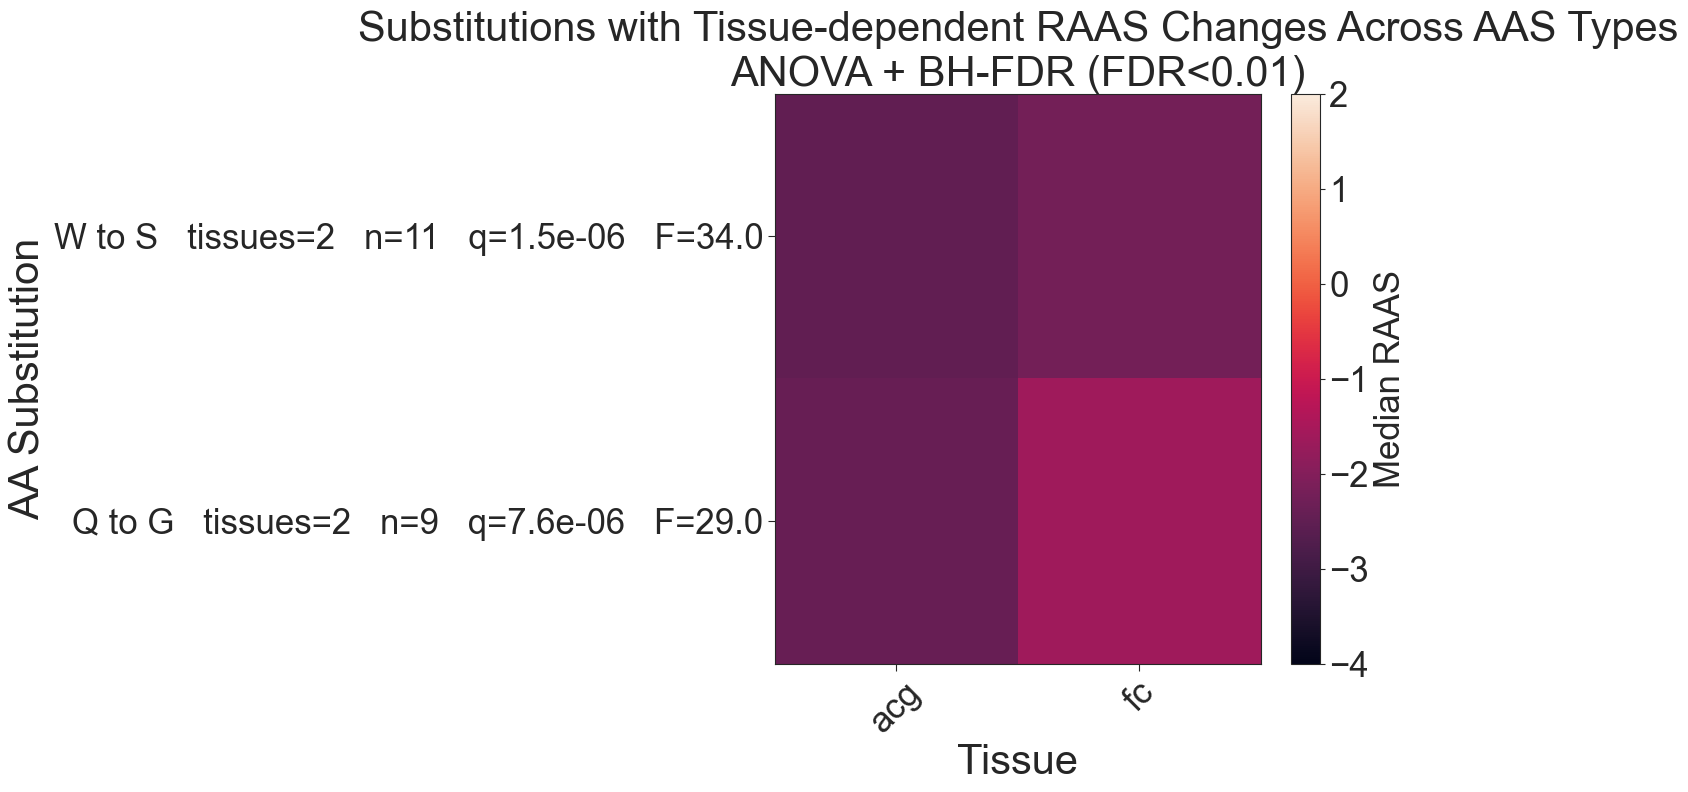

In [471]:
# are any of the variations in RAAS associated with tissue type statistically significant?
# ANOVA to identify AAS types that differ significantly in RAAS values across tissues
# require same SAAP observed across all tissues
# pool all TMT batches within tissue
from scipy import stats
min_saap=3
min_obs=3
peptide_keys=['Tissue','MTP_seq','BP_seq','aa_sub']
sub_df=replicate_cols(SAAP_quant_df_grouped)
tissue_order=sorted(sub_df['Tissue'].dropna().unique())
saap_df=(sub_df.groupby(peptide_keys+['Disease'])[raas_col].median().reset_index())
saap_df=saap_df.replace([np.inf,-np.inf],np.nan)
saap_df=saap_df.dropna(subset=[raas_col])
saap_tissue_counts=saap_df.groupby(['MTP_seq','BP_seq','aa_sub'])['Tissue'].nunique().reset_index(name='n_tissues')
valid_saaps=saap_tissue_counts[saap_tissue_counts['n_tissues']==len(tissue_order)]
saap_df=saap_df.merge(valid_saaps[['MTP_seq','BP_seq','aa_sub']],on=['MTP_seq','BP_seq','aa_sub'])
shared_subs=saap_df['aa_sub'].unique()
results=[]
for sub in shared_subs:
    curr=saap_df[saap_df['aa_sub']==sub]
    n_saap=curr[['MTP_seq','BP_seq']].drop_duplicates().shape[0]
    if n_saap<min_saap: continue
    counts=curr.groupby('Tissue').size()
    valid_tissues=counts[counts>=min_obs].index
    curr=curr[curr['Tissue'].isin(valid_tissues)]
    sub_tissues=sorted(curr['Tissue'].dropna().unique())
    if len(sub_tissues)<2: continue
    groups=[curr.loc[curr['Tissue']==t,raas_col].dropna().values for t in sub_tissues]
    groups=[g for g in groups if len(g)>0]
    if len(groups)<2: continue
    allvals=np.concatenate(groups)
    k=len(groups)
    N=len(allvals)
    grand_mean=np.mean(allvals)
    ss_between=np.sum([len(g)*(np.mean(g)-grand_mean)**2 for g in groups])
    ss_within=np.sum([np.sum((g-np.mean(g))**2) for g in groups])
    df_between=k-1
    df_within=N-k
    ms_between=ss_between/df_between
    ms_within=ss_within/df_within
    if ms_within==0: continue
    F=ms_between/ms_within
    p=1-stats.f.cdf(F,df_between,df_within)
    results.append([sub,n_saap,F,p,len(sub_tissues)])
results=pd.DataFrame(results,columns=['aa_sub','n_saap','F','p','n_tissues'])
results=run_fdr(results,p_col='p')
results['Significance']=results['FDR'].apply(add_sig_label)
results=results.sort_values(['n_tissues','FDR','F'],ascending=[False,True,False])
significant_subs=results.loc[results['FDR']<0.01,'aa_sub']
heatmap_df=(saap_df.groupby(['aa_sub','Tissue'])[raas_col].median().reset_index())
heatmap_matrix=(heatmap_df.pivot(index='aa_sub',columns='Tissue',values=raas_col))
heatmap_matrix=heatmap_matrix.loc[significant_subs]
heatmap_matrix=heatmap_matrix.reindex(index=significant_subs)
heatmap_matrix=heatmap_matrix.reindex(columns=tissue_order)
stats_lookup=results.set_index('aa_sub')
row_labels=[f'{sub}   tissues={int(stats_lookup.loc[sub,"n_tissues"])}   n={stats_lookup.loc[sub,"n_saap"]}   q={stats_lookup.loc[sub,"FDR"]:.1e}   F={stats_lookup.loc[sub,"F"]:.1f}' for sub in heatmap_matrix.index]
plt.figure(figsize=(14,max(8,len(heatmap_matrix)*0.45)))
plt.imshow(heatmap_matrix,vmin=-4,vmax=2,aspect='auto')
cbar=plt.colorbar(label='Median RAAS')
cbar.ax.tick_params(labelsize=25)
cbar.ax.set_ylabel('Median RAAS',size=25)
plt.xticks(np.arange(len(heatmap_matrix.columns)),heatmap_matrix.columns,rotation=45,fontsize=25)
plt.yticks(np.arange(len(heatmap_matrix.index)),row_labels,fontsize=25)
plt.xlabel('Tissue',fontsize=30)
plt.ylabel('AA Substitution',fontsize=30)
plt.title('Substitutions with Tissue-dependent RAAS Changes Across AAS Types\nANOVA + BH-FDR (FDR<0.01)',fontsize=30)
plt.tight_layout()
plt.grid(False)
plt.tick_params(axis='both',length=5)
plt.savefig(PLOT_DIR+'ANOVA_significant_tissue_heatmap.pdf',bbox_inches='tight')
results.to_csv(OUTDIR+'ANOVA_tissue_statistics.tsv',sep='\t',index=False)
print(results)

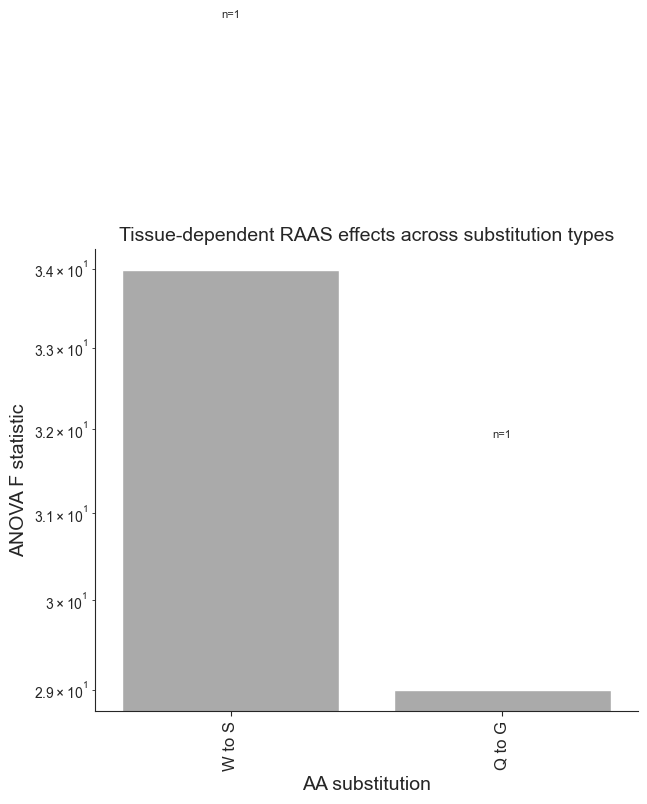

In [473]:
# Plot ANOVA statistics for tissue dependent RAAS changes per AAS type
anova_df = pd.read_csv(OUTDIR+'ANOVAwTukey_RAASBetweenTissuesperAASType_table.tsv',sep='\t')
plot_df=anova_df.copy()
plot_df=plot_df.loc[plot_df['p']<0.05]
plot_df=plot_df.loc[plot_df['n_sig_pairs']>0]
plot_df=plot_df.sort_values('F',ascending=False)
fig,ax=plt.subplots(figsize=(7,6))

sns.barplot(data=plot_df,
            x='AAS_type',
            y='F',
            color='#aaaaaa',
            ax=ax)

for i,row in enumerate(plot_df.itertuples()):
    ax.text(i,
            row.F*1.1,
            f'n={row.n_sig_pairs}',
            ha='center',
            fontsize=8)

ax.tick_params('both',labelsize=12)
plt.xticks(rotation=90)
plt.ylabel('ANOVA F statistic',fontsize=14)
plt.xlabel('AA substitution',fontsize=14)
plt.yscale('log')
plt.title('Tissue-dependent RAAS effects across substitution types',fontsize=14)

sns.despine()
plt.savefig(PLOT_DIR+'ANOVA_F_ranked.pdf', bbox_inches='tight')

### Correlations of AAS-Specific Median RAAS changes with Aging within Tissues

In [475]:
# Test Disease-associated substitution trends within tissues using 
# Spearman ranked correlation on all SAAP trajectories within AAS subtype 
# each point = one SAAP median across replicates within Disease 

from scipy.stats import spearmanr

min_saap = 3 # min saap required to support a sub type for correlation analysis 
sub_df=replicate_cols(SAAP_quant_df_grouped)
disease_map={'CTRL':1,'AD':2,'PD':3,'ADPD':4}
sub_df['Disease_num']=sub_df['Disease'].map(disease_map)
sub_df['SAAP_ID']=sub_df[['MTP_seq','BP_seq']].astype(str).agg('|'.join,axis=1)
saap_df=(sub_df.groupby(['Dataset','aa_sub','SAAP_ID','Disease','Disease_num'])[raas_col].median().reset_index())

results=[]
for tissue in sorted(saap_df['Dataset'].dropna().unique()):
    tissue_df=saap_df[saap_df['Dataset']==tissue]
    for sub in tissue_df['aa_sub'].dropna().unique():
        curr=tissue_df[tissue_df['aa_sub']==sub]
        n_saap=curr['SAAP_ID'].nunique()
        if n_saap<min_saap: continue
        stat_df=curr.dropna(subset=['Disease_num',raas_col])
        n=len(stat_df)

        if stat_df['Disease_num'].nunique()==4 and n>=10:
            rho,p=spearmanr(stat_df['Disease_num'],stat_df[raas_col])
            xrank=stat_df['Disease_num'].rank()
            yrank=stat_df[raas_col].rank()
            d2=((xrank-yrank)**2).sum()
            S=(n**3-n-d2)/6
        else:
            rho,p,S=np.nan,np.nan,np.nan
        if rho>0: direction='Increasing'
        elif rho<0: direction='Decreasing'
        else: direction='None'
        results.append([tissue,sub,n,n_saap,rho,S,p,direction])

results=pd.DataFrame(results, columns=['Dataset','aa_sub','n','n_saap','rho','S','p','direction'])
results=run_fdr(results,p_col='p') # B-H FDR correction 
results['Significance']=results['FDR'].apply(add_sig_label)
results=results.sort_values(['FDR','p','n_saap'],ascending=[True,True,False])

print('Total tests:',len(results))
print('Nominal p<0.05:',(results['p']<0.05).sum())
print('BH-FDR<0.01:',(results['FDR']<0.01).sum())
print(results[['Dataset','aa_sub','n','n_saap','rho', 'S', 'p','FDR','Significance','direction']])

results.to_csv(OUTDIR+'Spearman_RAASDifference_wAge_betweenAASType_withinTissue_table.tsv',sep='\t',index=False)

Total tests: 79
Nominal p<0.05: 1
BH-FDR<0.01: 1
   Dataset  aa_sub    n  n_saap       rho              S         p       FDR  \
12     acg  G to Q  124      31  0.342177  283991.833333  0.000100  0.007524   
72      fc  V to A   20       5 -0.413690    1033.833333  0.069805  0.989752   
18     acg  L to V   32       8 -0.292119    4323.333333  0.104731  0.989752   
7      acg  E to D   36       9 -0.240439    6213.916667  0.157792  0.989752   
25     acg  P to A   12       3  0.421776     259.250000  0.172040  0.989752   
..     ...     ...  ...     ...       ...            ...       ...       ...   
78      fc  Y to D   12       3  0.000000     239.666667  1.000000  1.000000   
28     acg  P to S    8       3       NaN            NaN       NaN       NaN   
53      fc  E to M    8       3       NaN            NaN       NaN       NaN   
54      fc  G to A   12       3       NaN     263.500000       NaN       NaN   
63      fc  P to S    8       3       NaN            NaN       NaN     

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1283462099.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho,p=spearmanr(stat_df['Disease_num'],stat_df[raas_col])


Unique SAAPs: 31
Disease
AD      31
ADPD    31
CTRL    31
PD      31
Name: SAAP_ID, dtype: int64


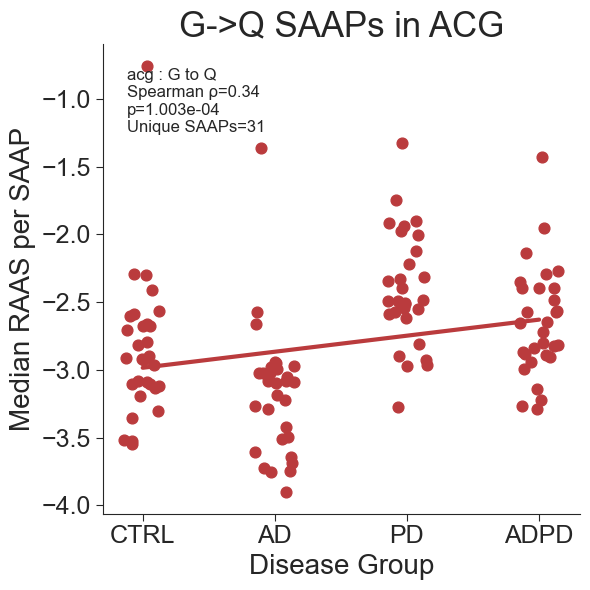

In [474]:
# Uncomment to see plot for a specific substitution type within a specific tissue 
sub_df=replicate_cols(SAAP_quant_df_grouped)
disease_map={'CTRL':1,'AD':2,'PD':3,'ADPD':4}
sub_df['Disease_num']=sub_df['Disease'].map(disease_map)
sub_df['SAAP_ID']=sub_df[['MTP_seq','BP_seq']].astype(str).agg('|'.join,axis=1)
plot_df=(sub_df.groupby(['Dataset','aa_sub','SAAP_ID','Disease','Disease_num'])[raas_col].median().reset_index())
plot_df=plot_df[(plot_df['Dataset']=='acg')&(plot_df['aa_sub']=='G to Q')].copy()
print('Unique SAAPs:',plot_df['SAAP_ID'].nunique())
print(plot_df.groupby('Disease')['SAAP_ID'].nunique())
rho,p=spearmanr(plot_df['Disease_num'],plot_df[raas_col])
plt.figure(figsize=(6,6))
sns.set_style('ticks')
x=plot_df['Disease_num']+np.random.uniform(-0.15,0.15,len(plot_df))
plt.scatter(x,plot_df[raas_col],s=60,alpha=1,color='#ba3b3d')
fit_df=(plot_df.groupby('Disease_num')[raas_col].median().reset_index())
coef=np.polyfit(fit_df['Disease_num'],fit_df[raas_col],1)
xline=np.linspace(1,4,100)
plt.plot(xline,np.polyval(coef,xline),lw=3,color='#ba3b3d')
plt.text(.05,.95,f'acg : G to Q\nSpearman ρ={rho:.2f}\np={p:.3e}\nUnique SAAPs={plot_df["SAAP_ID"].nunique()}',transform=plt.gca().transAxes,va='top',fontsize=12)
plt.xticks([1,2,3,4],['CTRL','AD','PD','ADPD'],fontsize=18)
plt.tick_params(axis='both',length=5)
plt.yticks(fontsize=18)
plt.xlabel('Disease Group',fontsize=20)
plt.ylabel('Median RAAS per SAAP',fontsize=20)
plt.title('G->Q SAAPs in ACG',fontsize=25)
sns.despine()
plt.tight_layout()
plt.show()

Total tests: 58
Nominal p<0.05: 3
BH-FDR<0.05: 1
    aa_sub  n_saap  mean_rho  median_rho  wilcoxon_stat    wilcoxon_p  \
17  G to Q      36  0.481322    0.488939            5.0  2.530158e-07   
24  L to V      15 -0.316239   -0.363803           17.0  1.245117e-02   
31  N to M      68  0.123218    0.121988          645.5  1.302410e-02   
50  V to A      10 -0.180655   -0.222916           10.0  8.398438e-02   
53  V to P      31 -0.094290   -0.072761          155.0  1.108218e-01   
13  F to M       5 -0.243975   -0.146385            0.0  1.250000e-01   
25  M to D      21  0.128251    0.169775           64.5  1.301720e-01   
32  N to S      15 -0.077431   -0.048795           36.0  1.725018e-01   
2   A to P      11  0.129836    0.048795            8.0  1.953125e-01   
10  E to M      10  0.143770    0.133310           14.5  1.972656e-01   
1   A to G       9 -0.090355   -0.097590           12.0  2.382812e-01   
15  G to E       4  0.332075    0.389283            1.0  2.500000e-01   
35

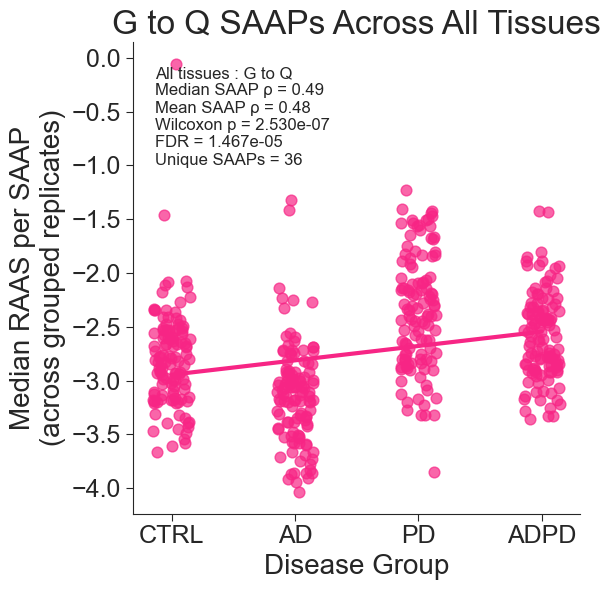

In [476]:
# Test Disease-associated substitution trends across ALL tissues combined
# one rho per SAAP trajectory using ALL replicate-level observations,
# then test rho distribution against 0

from scipy.stats import spearmanr,wilcoxon,ttest_1samp

min_saap=3
sub_df=replicate_cols(SAAP_quant_df_grouped)
disease_map={'CTRL':1,'AD':2,'PD':3,'ADPD':4}
sub_df['Disease_num']=sub_df['Disease'].map(disease_map)

# include Dataset so same peptide in different tissues is treated independently
sub_df['SAAP_ID']=(sub_df[['Dataset','MTP_seq','BP_seq']].astype(str).agg('|'.join,axis=1))

# DO NOT pool replicates
saap_df=sub_df.copy()
results=[]
for sub in sorted(saap_df['aa_sub'].dropna().unique()):
    curr=saap_df[saap_df['aa_sub']==sub]
    saap_rhos=[]
    for saap_id in curr['SAAP_ID'].unique():
        saap_curr=(curr[curr['SAAP_ID']==saap_id].dropna(subset=['Disease_num',raas_col]).sort_values('Disease_num'))
        # require all 4 disease groups represented
        if saap_curr['Disease_num'].nunique()!=4:
            continue
        rho,p=spearmanr(saap_curr['Disease_num'],saap_curr[raas_col])
        if not np.isnan(rho):
            saap_rhos.append(rho)
    saap_rhos=np.array(saap_rhos)
    n_saap=len(saap_rhos)
    if n_saap<min_saap:
        continue
    median_rho=np.median(saap_rhos)
    mean_rho=np.mean(saap_rhos)

    # Wilcoxon signed-rank vs 0
    try:
        w_stat,w_p=wilcoxon(saap_rhos)
    except:
        w_stat,w_p=np.nan,np.nan
    # one-sample t-test vs 0
    try:
        t_stat,t_p=ttest_1samp(saap_rhos,popmean=0)
    except:
        t_stat,t_p=np.nan,np.nan
    if median_rho>0:
        direction='Increasing'
    elif median_rho<0:
        direction='Decreasing'
    else:
        direction='None'
    results.append([sub,n_saap,mean_rho,median_rho,w_stat,w_p,t_stat,t_p,direction])
results=pd.DataFrame(results,columns=['aa_sub','n_saap','mean_rho','median_rho','wilcoxon_stat','wilcoxon_p','ttest_stat','ttest_p','direction'])

# FDR correction on Wilcoxon p-values
results=run_fdr(results,p_col='wilcoxon_p')
results['Significance']=results['FDR'].apply(add_sig_label)
results=results.sort_values(['FDR','wilcoxon_p','n_saap'],ascending=[True,True,False])
print('Total tests:',len(results))
print('Nominal p<0.05:',(results['wilcoxon_p']<0.05).sum())
print('BH-FDR<0.05:',(results['FDR']<0.05).sum())
print(results)

results.to_csv(OUTDIR+'Spearman_RAASDifference_wDisease_AllTissues_table.tsv',sep='\t',index=False)

# Plot significant substitution types
sig_results=results[results['FDR']<0.05].copy()
print('Significant tests:',len(sig_results))
for _,row in sig_results.iterrows():
    sub=row['aa_sub']
    plot_df=saap_df[saap_df['aa_sub']==sub].copy()
    # pooled rho across plotted replicate-level observations
    pooled_rho,pooled_p=spearmanr(plot_df['Disease_num'],plot_df[raas_col])
    plt.figure(figsize=(6,6))
    sns.set_style('ticks')
    x=plot_df['Disease_num']+np.random.uniform(-0.15,0.15,len(plot_df))
    plt.scatter(x,plot_df[raas_col],s=60,alpha=0.7,color='#F72585')

    # fit line using median across all replicate-level observations per Disease
    fit_df=(plot_df.groupby('Disease_num')[raas_col].median().reset_index())
    coef=np.polyfit(fit_df['Disease_num'],fit_df[raas_col],1)
    xline=np.linspace(1,4,100)
    plt.plot(xline,np.polyval(coef,xline),lw=3,color='#F72585')
    plt.text(
        .05,
        .95,
        (
            f'All tissues : {sub}\n'
            f'Median SAAP ρ = {row["median_rho"]:.2f}\n'
            f'Mean SAAP ρ = {row["mean_rho"]:.2f}\n'
            f'Wilcoxon p = {row["wilcoxon_p"]:.3e}\n'
            f'FDR = {row["FDR"]:.3e}\n'
            f'Unique SAAPs = {row["n_saap"]}'
        ),
        transform=plt.gca().transAxes,
        va='top',
        fontsize=12,
    )

    plt.xticks([1,2,3,4],['CTRL','AD','PD','ADPD'],fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Disease Group',fontsize=20)
    plt.ylabel('Median RAAS per SAAP\n(across grouped replicates)',fontsize=20)
    plt.title(f'{sub} SAAPs Across All Tissues',fontsize=24)
    plt.tick_params(axis='both',length=5)
    sns.despine()
    plt.tight_layout()
    plt.show()

   Dataset  aa_sub  n_saap  mean_rho  median_rho  wilcoxon_stat  wilcoxon_p  \
4      acg  G to Q      31  0.487759    0.497198            4.0    0.000002   
51      fc  Q to G      15  0.256568    0.278916            7.5    0.004719   
8      acg  Q to G      16 -0.189257   -0.150676           15.5    0.006615   
0      acg  N to M      49  0.144934    0.195180          342.5    0.019001   
29     acg  L to V       8 -0.411946   -0.477143            4.0    0.054688   
..     ...     ...     ...       ...         ...            ...         ...   
40     acg  D to M       9 -0.051586    0.024544           18.0    1.000000   
42     acg  T to S       6  0.071550   -0.002694            7.0    1.000000   
23     acg  T to G       5 -0.097045   -0.057623            7.0    1.000000   
39     acg  C to S       3 -0.020595    0.000000            1.0    1.000000   
52      fc  V to L       3 -0.105866   -0.351677            3.0    1.000000   

    ttest_stat       ttest_p   direction       FDR 

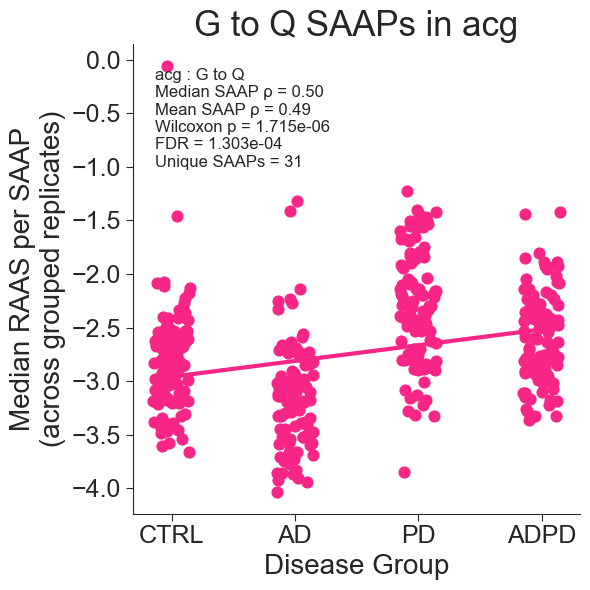

In [399]:
# Plot significant Disease-associated SAAP subtype trends within tissues
# one rho per SAAP trajectory using ALL replicate-level observations,
# then Wilcoxon test across SAAP rho distribution

from scipy.stats import spearmanr,wilcoxon,ttest_1samp

min_saap=3
sub_df=replicate_cols(SAAP_quant_df_grouped)
disease_map={'CTRL':1,'AD':2,'PD':3,'ADPD':4}
sub_df['Disease_num']=sub_df['Disease'].map(disease_map)
sub_df['SAAP_ID']=(sub_df[['MTP_seq','BP_seq']].astype(str).agg('|'.join,axis=1))

# DO NOT pool replicates
saap_df=sub_df.copy()
results=[]
for tissue in sorted(saap_df['Dataset'].dropna().unique()):
    tissue_df=saap_df[saap_df['Dataset']==tissue]
    for sub in tissue_df['aa_sub'].dropna().unique():
        curr=tissue_df[tissue_df['aa_sub']==sub]
        saap_rhos=[]
        for saap_id in curr['SAAP_ID'].unique():
            saap_curr=(curr[curr['SAAP_ID']==saap_id].dropna(subset=['Disease_num',raas_col]).sort_values('Disease_num'))

            # require all 4 disease groups represented
            if saap_curr['Disease_num'].nunique()!=4:
                continue
            rho,p=spearmanr(saap_curr['Disease_num'],saap_curr[raas_col])
            if not np.isnan(rho):
                saap_rhos.append(rho)
        saap_rhos=np.array(saap_rhos)
        n_saap=len(saap_rhos)
        if n_saap<min_saap:
            continue
        median_rho=np.median(saap_rhos)
        mean_rho=np.mean(saap_rhos)

        # Wilcoxon signed-rank vs 0
        try:
            w_stat,w_p=wilcoxon(saap_rhos)
        except:
            w_stat,w_p=np.nan,np.nan
        # one-sample t-test vs 0
        try:
            t_stat,t_p=ttest_1samp(saap_rhos,popmean=0)
        except:
            t_stat,t_p=np.nan,np.nan
        if median_rho>0:
            direction='Increasing'
        elif median_rho<0:
            direction='Decreasing'
        else:
            direction='None'
        results.append([tissue,sub,n_saap,mean_rho,median_rho,w_stat,w_p,t_stat,t_p,direction])
results=pd.DataFrame(results,columns=['Dataset','aa_sub','n_saap','mean_rho','median_rho','wilcoxon_stat','wilcoxon_p','ttest_stat','ttest_p','direction'])

# FDR correction on Wilcoxon p-values
results=run_fdr(results,p_col='wilcoxon_p')
results['Significance']=results['FDR'].apply(add_sig_label)
results=results.sort_values(['FDR','wilcoxon_p','n_saap'],ascending=[True,True,False])
print(results)

# Plot ALL significant subtype+tissue combinations
sig_results=results[results['FDR']<0.05].copy()
print('Significant tests:',len(sig_results))
for _,row in sig_results.iterrows():
    tissue=row['Dataset']
    sub=row['aa_sub']
    plot_df=saap_df[(saap_df['Dataset']==tissue)&(saap_df['aa_sub']==sub)].copy()

    # pooled rho across plotted replicate-level observations
    pooled_rho,pooled_p=spearmanr(plot_df['Disease_num'],plot_df[raas_col])
    plt.figure(figsize=(6,6))
    sns.set_style('ticks')
    x=plot_df['Disease_num']+np.random.uniform(-0.15,0.15,len(plot_df))
    plt.scatter(x,plot_df[raas_col],s=60,alpha=1,color='#F72585')

    # fit line using median across replicate-level observations per Disease
    fit_df=(plot_df.groupby('Disease_num')[raas_col].median().reset_index())
    coef=np.polyfit(fit_df['Disease_num'],fit_df[raas_col],1)
    xline=np.linspace(1,4,100)
    plt.plot(xline,np.polyval(coef,xline),lw=3,color='#F72585')
    plt.text(
        .05,
        .95,
        (
            f'{tissue} : {sub}\n'
            f'Median SAAP ρ = {row["median_rho"]:.2f}\n'
            f'Mean SAAP ρ = {row["mean_rho"]:.2f}\n'
            f'Wilcoxon p = {row["wilcoxon_p"]:.3e}\n'
            f'FDR = {row["FDR"]:.3e}\n'
            f'Unique SAAPs = {row["n_saap"]}'
        ),
        transform=plt.gca().transAxes,
        va='top',
        fontsize=12,
    )

    plt.xticks([1,2,3,4],['CTRL','AD','PD','ADPD'],fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Disease Group',fontsize=20)
    plt.ylabel('Median RAAS per SAAP\n(across grouped replicates)',fontsize=20)
    plt.title(f'{sub} SAAPs in {tissue}',fontsize=25)
    plt.tick_params(axis='both',length=5)
    sns.despine()
    plt.tight_layout()
    plt.show()

## More RAAS-level AAS Type Analysis 
Code based on Tsour et al. Nature 2026

acgb1
acgb2
acgb3
acgb4
acgb5
fcb2
fcb3
fcb4
fcb5


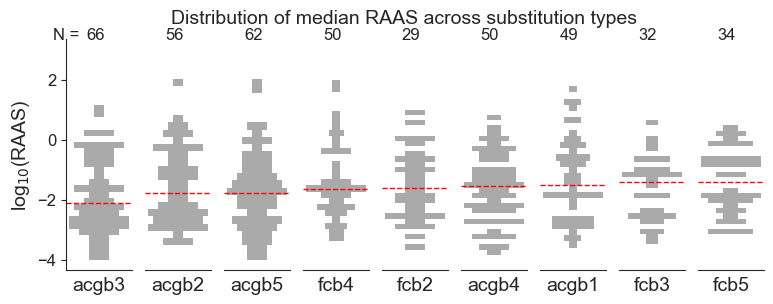

In [400]:
# list of all substitution types found in data
AASs = list(set(SAAP_quant_df['aa_sub'].values))

# generate dictionary with RAAS values organized by substitution type
ratios_by_aas = {}
for i,ds in enumerate(datasets):
    print(ds)
    ds_prec_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]
    ds_report_df = SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds]
    aas_prec_ratio_df = ds_prec_df.loc[:, ['aa_sub', 'Reporter_RAAS']]
    aas_prec_ratio_df.replace(np.inf, np.nan, inplace=True)
    aas_prec_ratio_df.replace(-np.inf, np.nan, inplace=True)
    aas_prec_ratio_df.dropna(how='any', axis=0, inplace=True)
    
    prec_subs_in_plot = [x for x in AASs if x in set(aas_prec_ratio_df['aa_sub'])]
    prec_medians = [np.nanmedian([x for x in aas_prec_ratio_df.loc[aas_prec_ratio_df['aa_sub']==sub,'Reporter_RAAS'].values]) for sub in prec_subs_in_plot]
    prec_sorted_idx = np.argsort(prec_medians)
    prec_sorted_medians = [prec_medians[i] for i in prec_sorted_idx]
    prec_sorted_subs = [prec_subs_in_plot[i] for i in prec_sorted_idx]
    
    if ds !='Healthy':
        aas_ratio_df = ds_report_df.loc[:, ['aa_sub', 'Reporter_RAAS']]
        aas_ratio_df.replace(np.inf, np.nan, inplace=True)
        aas_ratio_df.replace(-np.inf, np.nan, inplace=True)
        aas_ratio_df.dropna(how='any', axis=0, inplace=True)
        subs_in_plot = [x for x in AASs if x in set(aas_ratio_df['aa_sub'])]
        #medians = [np.nanmedian([x for x in aas_ratio_df.loc[aas_ratio_df['AAS']==sub,'Substitution ratio'].values]) for sub in subs_in_plot]
        medians = [np.nanmedian([x for x in aas_ratio_df.loc[aas_ratio_df['aa_sub']==sub,'Reporter_RAAS'].values]) for sub in subs_in_plot]
        sorted_idx = np.argsort(medians)
        sorted_medians = [medians[i] for i in sorted_idx]
        sorted_subs = [subs_in_plot[i] for i in sorted_idx]
        ratios_by_aas[ds] = {'Precursor_ratio_df': aas_prec_ratio_df, 'prec_AAS_sorted':prec_sorted_subs, 'prec_medians_sorted':prec_sorted_medians, 
                             'Reporter_ratio_df': aas_ratio_df, 'AAS_sorted':sorted_subs, 'medians_sorted':sorted_medians}
    else:
        ratios_by_aas[ds] = {'Precursor_ratio_df': aas_prec_ratio_df, 'prec_AAS_sorted':prec_sorted_subs, 'prec_medians_sorted':prec_sorted_medians}
pickle.dump(ratios_by_aas, open(OUTDIR+'Ratios_by_AAS.p', 'wb'))

# get median RAAS for each AAS type
# median_aas_ratios = {ds:{} for ds in datasets}
# for ds in datasets:
#     ds_aas_df = ratios_by_aas[ds]['Precursor_ratio_df']
#     aas = list(set(ds_aas_df['aa_sub'].values))
#     aas_medians = {aa:np.median([x for x in ds_aas_df.loc[ds_aas_df['aa_sub']==aa,'Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]) for aa in aas}
#     median_aas_ratios[ds] = aas_medians

median_aas_ratios = {ds:{} for ds in datasets}
for ds in datasets:
    ds_aas_df = ratios_by_aas[ds]['Reporter_ratio_df']
    aas = list(set(ds_aas_df['aa_sub'].values))
    aas_medians = {aa:np.median([x for x in ds_aas_df.loc[ds_aas_df['aa_sub']==aa,'Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]) for aa in aas}
    median_aas_ratios[ds] = aas_medians


# plot distributions of median RAAS across AAS types
sns.set_style('ticks')
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

# get medians of each dataset to sort datasets for visualization
medians = [np.nanmedian(list(median_aas_ratios[ds].values())) for ds in datasets if ds!='Healthy']
med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = list(median_aas_ratios[ds].values())
    bihist(ratio_data, ratio_data, nbins=30,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N = ', (-0.2,1), xycoords='axes fraction', fontsize=12)
    axes[ax_idx].annotate('{:,}'.format((len(ratio_data))), (0.3,1), xycoords='axes fraction', fontsize=12)
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.nanmedian(ratio_data), np.nanmedian(ratio_data)), '--r',linewidth=1)
axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=14)
axes[0].tick_params('y', labelsize=12)
plt.suptitle('Distribution of median RAAS across substitution types', fontsize=14)
plt.savefig(OUTDIR+'MedianRAAS_byAAStype_hist.pdf', bbox_inches='tight')

In [401]:
# code to get dictionary of RAAS values stratified by substitution type (e.g. base->substituted amino acid).
raas_by_aas_stats = {}

for ds in datasets:
    print(ds)
    raas_by_aas_stats[ds] = {}
    ratios_df = ratios_by_aas[ds]['Reporter_ratio_df']
    all_raas = ratios_df['Reporter_RAAS'].values

    median_raas_dict = median_aas_ratios[ds]
    aas = sorted(list(median_raas_dict.keys()))
    medians = [median_raas_dict[aa] for aa in aas]
    sort_idx = np.argsort(medians)
    sort_aas = [aas[i] for i in sort_idx]

    for i,aa in enumerate(sort_aas):
        rank = i
        aas_raas = ratios_df.loc[ratios_df['aa_sub']==aa, 'Reporter_RAAS'].values
        n = len(aas_raas)
        ttest_p = sp.stats.ttest_ind(aas_raas, all_raas, nan_policy='omit')[1]
        ranksums_p = sp.stats.ranksums(aas_raas, all_raas)[1]

        raas_by_aas_stats[ds][aa] = {'Median_raas':median_raas_dict[aa], 'Rank':rank, 'N_peptides':n, 
                                     'RAAS_vals':list(aas_raas), 'ttest_p':ttest_p, 'ranksum_p':ranksums_p}
    
    if ds!='Healthy':
        report_ratios_df = ratios_by_aas[ds]['Reporter_ratio_df']
        all_report_raas = ratios_df['Reporter_RAAS'].values
        
        for i,aa in enumerate(sort_aas):
            aas_raas = report_ratios_df.loc[report_ratios_df['aa_sub']==aa, 'Reporter_RAAS'].values
            n = len(aas_raas)
            ttest_p = sp.stats.ttest_ind(aas_raas, all_report_raas, nan_policy='omit')[1]
            ranksums_p = sp.stats.ranksums(aas_raas, all_raas)[1]


            raas_by_aas_stats[ds][aa]['Report_RAAS_vals'] = list(aas_raas)
            raas_by_aas_stats[ds][aa]['Report_ttest_p'] = ttest_p
            raas_by_aas_stats[ds][aa]['Report_ranksum_p'] = ranksums_p
            raas_by_aas_stats[ds][aa]['N_Reporter'] = n
            raas_by_aas_stats[ds][aa]['Reporter_median'] = np.nanmedian(aas_raas)


pickle.dump(raas_by_aas_stats, open(OUTDIR+'RAAS_byAAS_stats.p', 'wb'))

acgb1
acgb2
acgb3
acgb4
acgb5
fcb2
fcb3
fcb4
fcb5


In [402]:
def weighted_cov(x, y, w):
    """
    Calculates the weighted covariance between two vectors.

    Args:
      x (np.ndarray): First vector.
      y (np.ndarray): Second vector.
      w (np.ndarray): Weights vector (same length as x and y).

    Returns:
      float: Weighted covariance between x and y.
    """

    if len(x) != len(y) != len(w):
        raise ValueError("Input vectors and weights must have the same length.")
    mean_x = np.average(x, weights=w)
    mean_y = np.average(y, weights=w)
    cov = np.sum(w * (x - mean_x) * (y - mean_y))

    return cov


def weighted_corr(x, y, w):
    """
    Calculates the weighted Pearson correlation coefficient between two vectors.

    Args:
      x (np.ndarray): First vector.
      y (np.ndarray): Second vector.
      w (np.ndarray): Weights vector (same length as x and y).

    Returns:
      float: Weighted Pearson correlation coefficient between x and y.
    """
    cov = weighted_cov(x, y, w)
    std_x = np.sqrt(weighted_cov(x, x, w))
    std_y = np.sqrt(weighted_cov(y, y, w))
    if std_x * std_y == 0:
        return 0.0  # Avoid division by zero
    return(cov / (std_x * std_y))

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/126298258.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.ax_cbar.set_yticklabels([0,0.2,0.4,0.6,0.8, 1], fontsize=13)


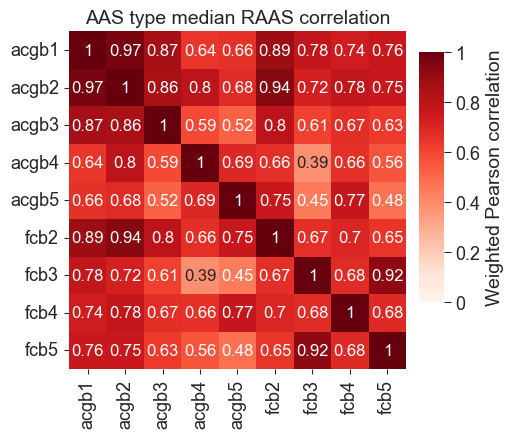

In [407]:
# generate a heatmap with the median precursor RAAS for each AAS type in each dataset 
datasets=['acgb1','acgb2','acgb3','acgb4','acgb5','fcb2','fcb3','fcb4','fcb5']
rep_heatmap_data = pd.DataFrame(index=AASs, columns=datasets)
for i, row in rep_heatmap_data.iterrows():
    for ds in datasets:
        # if ds=='Healthy':
        ds_ratios = ratios_by_aas[ds]
        medians = ds_ratios['medians_sorted']
        aas = ds_ratios['AAS_sorted']
        for i,aa in enumerate(aas):
            rep_heatmap_data.loc[aa,ds] = medians[i]
        # else:
        #     ds_ratios = ratios_by_aas[ds]
        #     medians = ds_ratios['medians_sorted']
        #     aas = ds_ratios['AAS_sorted']
        #     for i,aa in enumerate(aas):
        #         rep_heatmap_data.loc[aa,ds] = medians[i]
rep_heatmap_data = rep_heatmap_data[datasets]
rep_heatmap_data.dropna(how='all', inplace=True)
rep_heatmap_data.to_excel(OUTDIR+'Reporter_RAAS_byAAS_alldatasets.xlsx')

# compute correlations of median RAAS by AAS vectors across datasets
rep_heatmap_data.replace(np.inf, np.nan, inplace=True)
heatmap_df_4corr = rep_heatmap_data.dropna(how='any')
corr_heatmap = pd.DataFrame(index=datasets, columns=datasets)
for ds1 in datasets:
    for ds2 in datasets:
        x = heatmap_df_4corr[ds1].to_list()
        y = heatmap_df_4corr[ds2].to_list()
        w = [raas_by_aas_stats[ds1][aas]['N_peptides']+raas_by_aas_stats[ds2][aas]['N_peptides'] for aas in heatmap_df_4corr.index]
        corr = weighted_corr(x, y, w)
        corr_heatmap.loc[ds1,ds2] = corr
corr_heatmap = corr_heatmap.loc[datasets,datasets]

# plot correlation heatmap
corr_heatmap = corr_heatmap.astype(float)
s= sns.clustermap(corr_heatmap, figsize=(5,5), annot=np.round(corr_heatmap, 2), cmap='Reds', cbar_kws={'label':'Weighted Pearson correlation', 'pad':1}, annot_kws={"fontsize":12},
                 vmax=1, vmin=0, row_cluster=False, col_cluster=False)
s.ax_heatmap.tick_params(right=False, left=True, labelright=False, labelleft=True, labelbottom=True, bottom=True)
plt.setp(s.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=13)
plt.setp(s.ax_heatmap.yaxis.get_majorticklabels(), fontsize=13)
x0, y0, w, h = s.cbar_pos
s.ax_cbar.set_position([0.9,0.26,0.05,0.5])
s.ax_cbar.yaxis.label.set_size(14)
s.ax_cbar.set_yticklabels([0,0.2,0.4,0.6,0.8, 1], fontsize=13)
plt.tick_params(axis='both', length=5)
s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)
s.ax_heatmap.set_title('AAS type median RAAS correlation', position=(0.5,1), fontsize=14)
plt.savefig(PLOT_DIR+'Correlation_heatmap_AAStype_ReporterRatios_weighted_clustered_noNan.pdf', bbox_inches='tight')

# 3. RAAS Analysis

## Global RAAS Distributions

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1323056638.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1323056638.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)


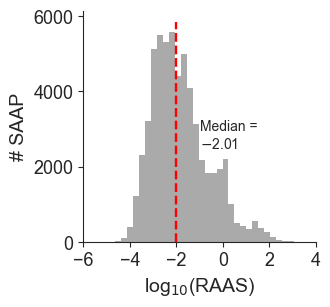

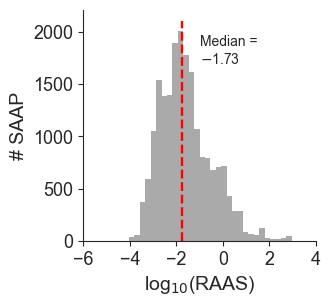

In [459]:
# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_acg['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=30, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (-1,2500), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot_acg.pdf', bbox_inches='tight')

# sample-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_fc['Reporter_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=30, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (-1,1700), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()
plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_onehistplot_fc.pdf', bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/4191585675.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/4191585675.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)


<Figure size 640x480 with 0 Axes>

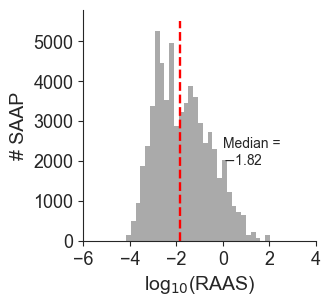

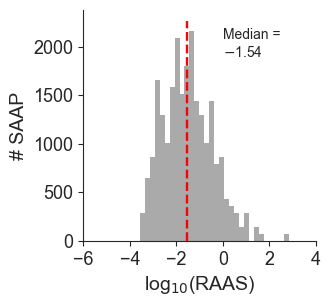

In [456]:
# tmt-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
sns.despine()
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_acg['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=30, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,1900), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot_acg.pdf', bbox_inches='tight')


# tmt-level RAAS distribution - all datasets in one distribution
sns.set_style('ticks')
sns.despine()
fig,ax = plt.subplots(figsize=(3,3))
ratios = []
for i,ds in enumerate(datasets):
    ratio_data = [x for x in SAAP_quant_df_fc['Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    ratios = ratios + ratio_data
sns.histplot(ratios, color='#aaaaaa', bins=30, linewidth=0, alpha=1)
plt.plot((np.median(ratios), np.median(ratios)),(plt.ylim()), '--r', color="red", linewidth=1.7)
ax.annotate('Median =\n$-$'+str(np.abs(np.round(np.median(ratios), 2))), (0,1900), fontsize=10)
ax.set_ylabel(r'# SAAP', fontsize=14)
ax.set_xlabel(r'log$_{10}$(RAAS)', fontsize=14)
ax.tick_params('both',labelsize=13)
ax.set_xticks([-6,-4,-2,0,2,4]);
sns.despine()
plt.savefig(PLOT_DIR+'tmt_level_RAAS_allDS_onehistplot_fc.pdf', bbox_inches='tight')

## MS1 vs MS2 Level RAAS Agreeability

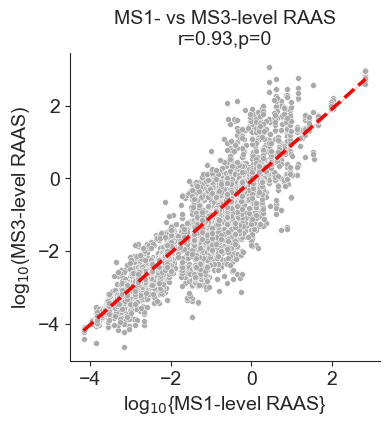

In [460]:
fig,ax = plt.subplots(figsize=(4,4))

raas_df=SAAP_quant_df.copy()
raas_df['log10_Prec_RAAS']=raas_df['Prec_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df['log10_Reporter_RAAS']=raas_df['Reporter_RAAS'].replace([np.inf,-np.inf],np.nan)
raas_df=raas_df.dropna(subset=['log10_Prec_RAAS','log10_Reporter_RAAS'])

r,p=sp.stats.pearsonr(raas_df['log10_Prec_RAAS'],raas_df['log10_Reporter_RAAS'])
sns.scatterplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',s=18,alpha=1,color='#aaaaaa',edgecolor='white',linewidth=0.35,ax=ax)
sns.regplot(data=raas_df,x='log10_Prec_RAAS',y='log10_Reporter_RAAS',scatter=False,line_kws={'color':'red','linestyle':'--','linewidth':2.5,'zorder':10},ax=ax)

ax.tick_params('both',labelsize=14)
plt.xlabel('log$_{10}${MS1-level RAAS}',fontsize=14)
plt.ylabel('log$_{10}$(MS3-level RAAS)',fontsize=14)
plt.title(f'MS1- vs MS3-level RAAS\nr={r:.2f},p={p:.3g}',fontsize=14)
sns.despine()
plt.savefig(PLOT_DIR+'MS1_MS3_RAAS_correlation.pdf',bbox_inches='tight')

## Tissue-Level RAAS Distributions

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/1579173459.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[i].plot(axes[i].get_xlim(),(np.median(ratio_data), np.median(ratio_data)),'--r',color="red",linewidth=1.7)


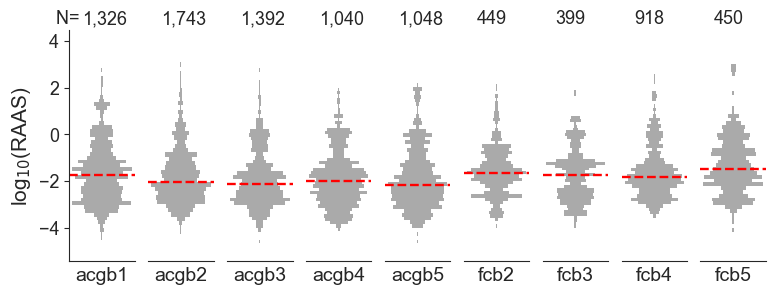

In [449]:
#Sample level RAAS distribution (reporter ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP reporter-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

for i,ds in enumerate(datasets):
    axes[i].set_xlabel(ds, fontsize=14)
    ratio_data=SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds,'Reporter_RAAS'].values
    ratio_data=[x for x in ratio_data if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[i])

    if i==0:
        axes[i].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)

    axes[i].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[i].plot(axes[i].get_xlim(),(np.median(ratio_data), np.median(ratio_data)),'--r',color="red",linewidth=1.7)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'sample_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')

/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/2788704015.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "--r" (-> color='r'). The keyword argument will take precedence.
  axes[i].plot(axes[i].get_xlim(),(np.median(ratio_data), np.median(ratio_data)),'--r',color="red",linewidth=1.7)


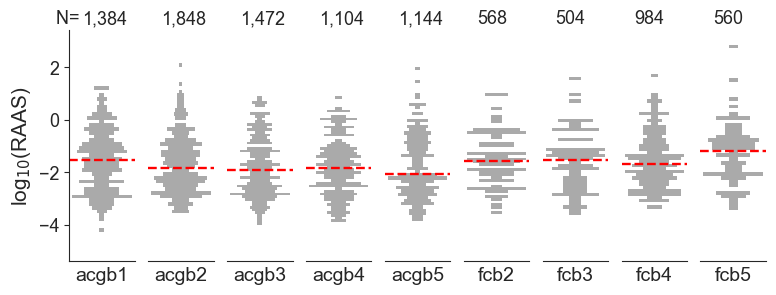

In [450]:
#TMT-level RAAS distribution (precursor ion RAAS distribution), code adapted from Tsour et al 2024
# N = number of quantified SAAP precursor-ion ratios

fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)

sns.set_style('ticks')
sns.despine()

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)

for i,ds in enumerate(datasets):
    axes[i].set_xlabel(ds, fontsize=14)
    ratio_data=SAAP_quant_df.loc[SAAP_quant_df['Dataset']==ds,'Prec_RAAS'].values
    ratio_data=[x for x in ratio_data if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=50,h=axes[i])

    if i==0:
        axes[i].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)

    axes[i].annotate('{:,}'.format((len(ratio_data))), (0.2,1.03), xycoords='axes fraction', fontsize=13)
    axes[i].plot(axes[i].get_xlim(),(np.median(ratio_data), np.median(ratio_data)),'--r',color="red",linewidth=1.7)

axes[0].set_ylabel(r'log$_{10}$(RAAS)', fontsize=15)
axes[0].tick_params('y',labelsize=13)

plt.savefig(PLOT_DIR+'TMT_level_RAAS_allDS_nogrid.pdf', bbox_inches='tight')

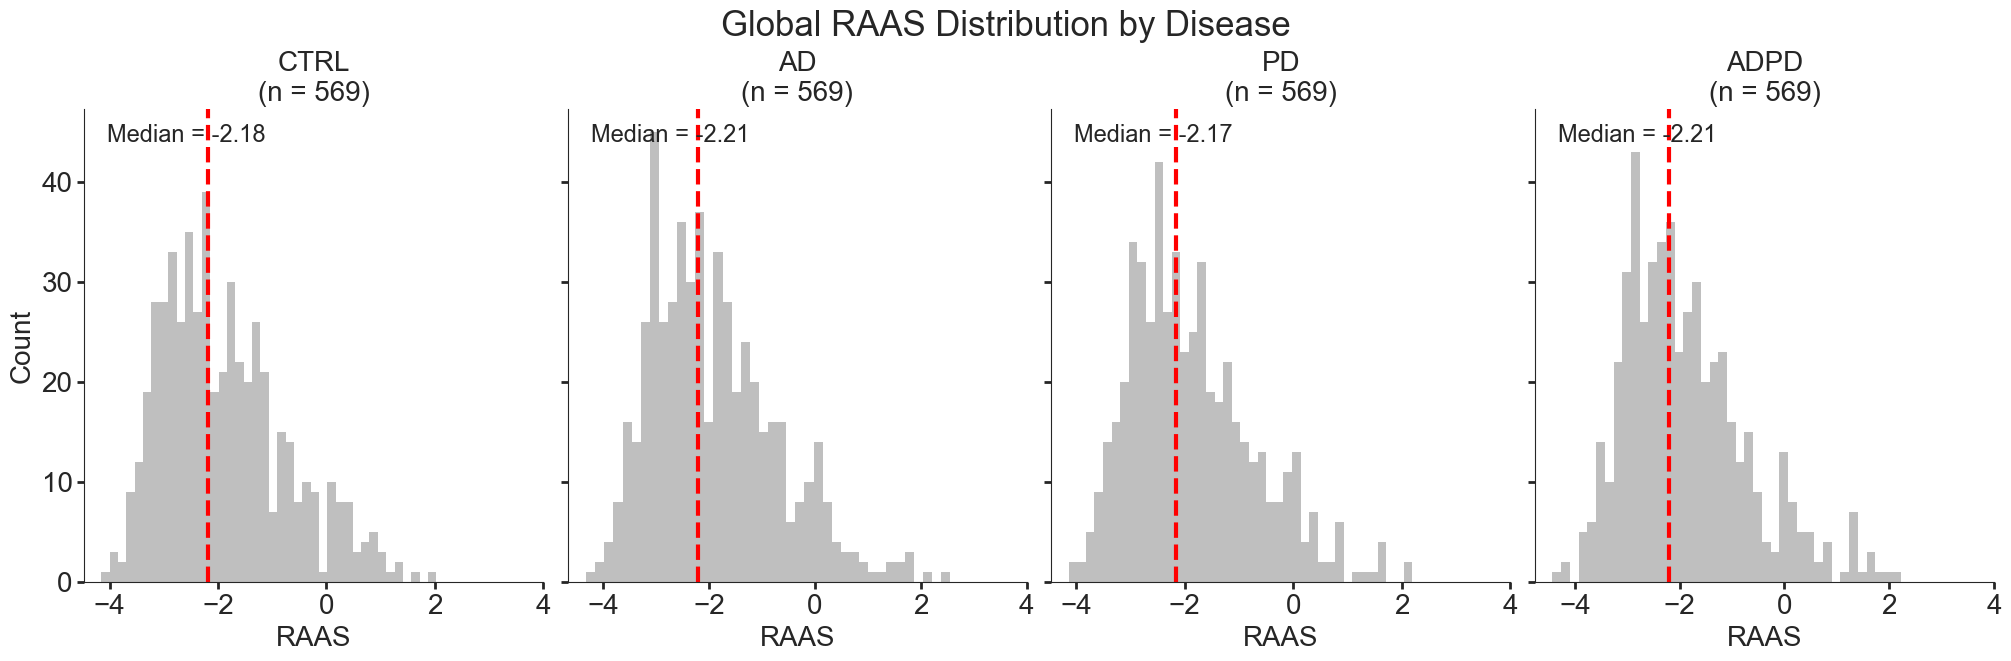

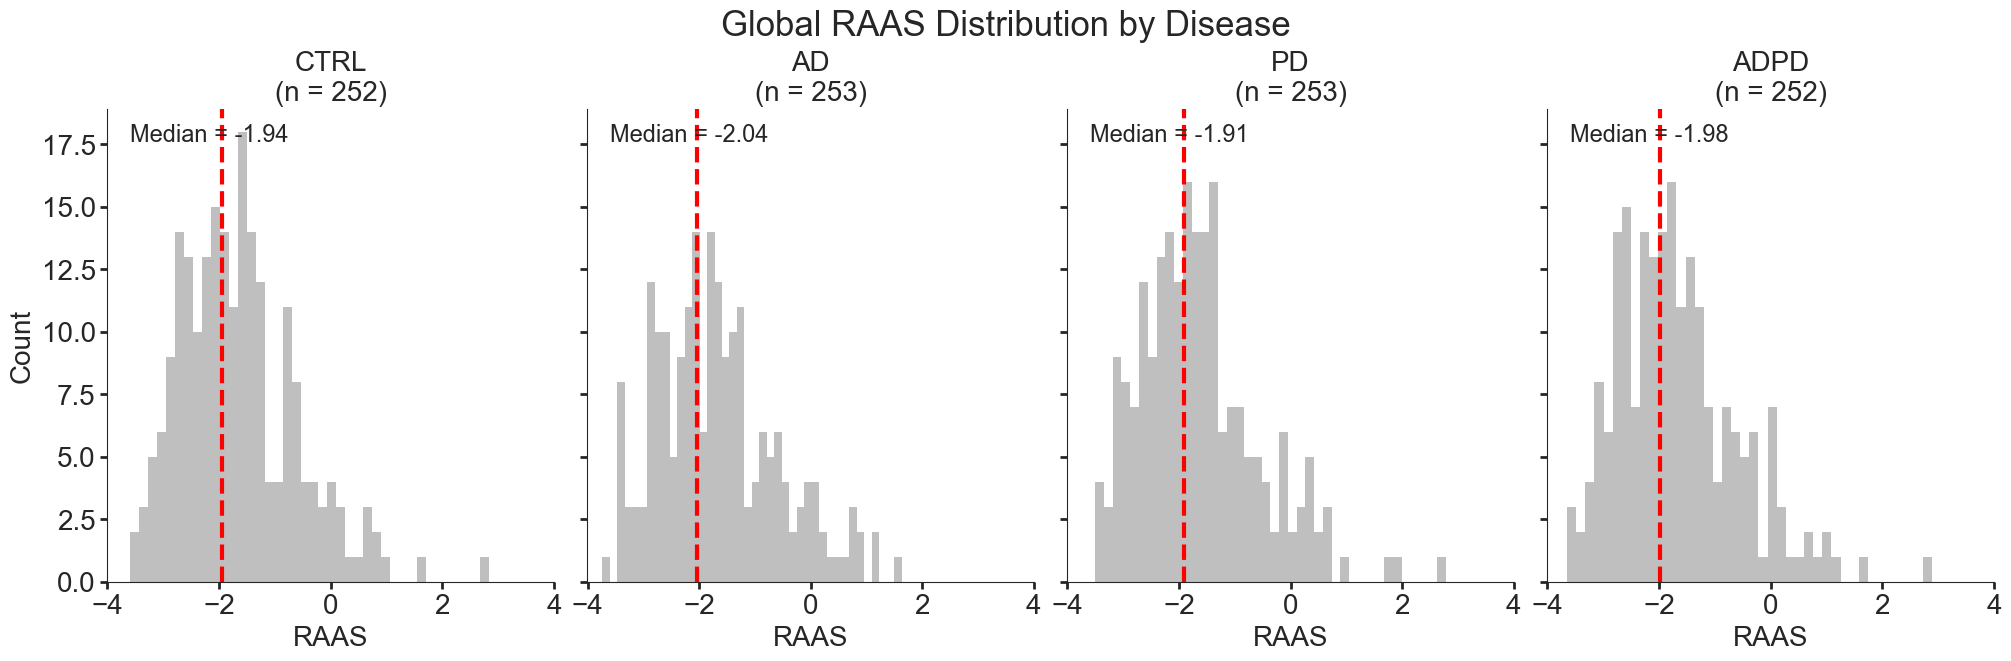

In [468]:
# sample level RAAS distribution by disease
# one SAAP RAAS value is the median of its replicates
disease_df=SAAP_quant_df_grouped_acg.copy()
disease_df=disease_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
disease_df=disease_df.dropna(subset=['Reporter_RAAS'])
disease_order=['CTRL','AD','PD','ADPD']
disease=[d for d in disease_order if d in disease_df['Sample Type'].unique()]
num_dis=len(disease)
fig,axes=plt.subplots(1,num_dis,figsize=(5*num_dis,6.5),sharey=True,constrained_layout=True)
for i,d in enumerate(disease):
    ax=axes[i]
    subset=disease_df[disease_df['Sample Type']==d]
    vals=subset['Reporter_RAAS'].dropna().values
    sns.histplot(vals,bins=40,kde=False,ax=ax,color='#aaaaaa',edgecolor=None,linewidth=0)
    median=np.nanmedian(vals)
    ax.axvline(median,color='red',linestyle='--',linewidth=3)
    n=len(vals)
    ax.set_title(f'{d}\n(n = {n})',fontsize=20)
    ax.tick_params(axis='both',labelsize=20,length=5,width=2)
    ax.set_xlabel('RAAS',fontsize=20)
    ax.set_xticks([-4,-2,0,2,4])
    ax.set_ylabel('Count',fontsize=20)
    ax.grid(False)
    sns.despine()
    ax.text(0.05,0.95,f'Median = {median:.2f}',transform=ax.transAxes,fontsize=17,verticalalignment='center_baseline')
plt.suptitle('Global RAAS Distribution by Disease',fontsize=25)
plt.savefig(PLOT_DIR+'Global_RAAS_by_disease.pdf')
plt.show()


# sample level RAAS distribution by disease
# one SAAP RAAS value is the median of its replicates
disease_df=SAAP_quant_df_grouped_fc.copy()
disease_df=disease_df.groupby(['Dataset','MTP_seq','Sample Type'])['Reporter_RAAS'].median().reset_index()
disease_df=disease_df.dropna(subset=['Reporter_RAAS'])
disease_order=['CTRL','AD','PD','ADPD']
disease=[d for d in disease_order if d in disease_df['Sample Type'].unique()]
num_dis=len(disease)
fig,axes=plt.subplots(1,num_dis,figsize=(5*num_dis,6.5),sharey=True,constrained_layout=True)
for i,d in enumerate(disease):
    ax=axes[i]
    subset=disease_df[disease_df['Sample Type']==d]
    vals=subset['Reporter_RAAS'].dropna().values
    sns.histplot(vals,bins=40,kde=False,ax=ax,color='#aaaaaa',edgecolor=None,linewidth=0)
    median=np.nanmedian(vals)
    ax.axvline(median,color='red',linestyle='--',linewidth=3)
    n=len(vals)
    ax.set_title(f'{d}\n(n = {n})',fontsize=20)
    ax.tick_params(axis='both',labelsize=20,length=5,width=2)
    ax.set_xticks([-4,-2,0,2,4])
    ax.set_xlabel('RAAS',fontsize=20)
    ax.set_ylabel('Count',fontsize=20)
    ax.grid(False)
    sns.despine()
    ax.text(0.05,0.95,f'Median = {median:.2f}',transform=ax.transAxes,fontsize=17,verticalalignment='center_baseline')
plt.suptitle('Global RAAS Distribution by Disease',fontsize=25)
plt.savefig(PLOT_DIR+'Global_RAAS_by_disease.pdf')
plt.show()

## RAAS Distribution for Peptides Shared between All Tissues

<>:44: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
/var/folders/g1/2zxfph5533g5zjz997szslmw0000gn/T/ipykernel_25060/2000262881.py:44: SyntaxWarning: invalid escape sequence '\g'
  c.ax_heatmap.set_xlabel('SAAP in $\geq$6 datasets', fontsize=15)


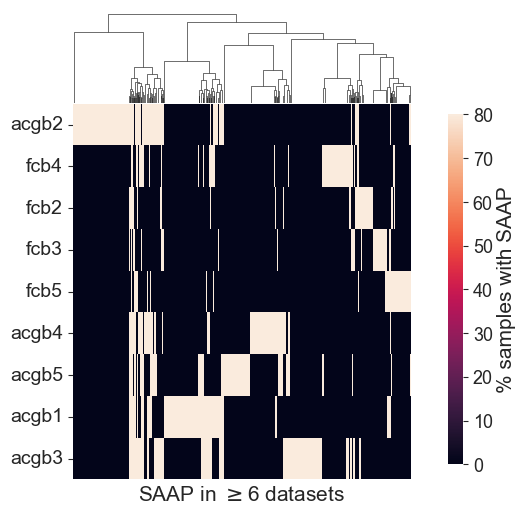

In [445]:
# add number of datasets each SAAP-BP pair is found in to data from SAAP_quant_df
saap_bp = [row['MTP_seq']+':'+row['BP_seq'] for i,row in SAAP_quant_df.iterrows()]
saap_bp_counter = Counter(saap_bp)
saap_bp_count_df = pd.DataFrame.from_dict(saap_bp_counter, columns=['N datasets'], orient='index')

def get_ds(saap, bp, SAAP_quant_df):
    """ function to get the list of datasets a given SAAP-BP pair is found in"""
    saap_bp_df = SAAP_quant_df.loc[(SAAP_quant_df['MTP_seq']==saap) & (SAAP_quant_df['BP_seq']==bp)]
    ds_list = saap_bp_df['Dataset'].tolist()
    return(ds_list)

SAAP_quant_df['N datasets'] = SAAP_quant_df.apply(lambda x: len(get_ds(x['MTP_seq'], x['BP_seq'], SAAP_quant_df)), axis=1)
SAAP_quant_df['Datasets'] = SAAP_quant_df.apply(lambda x: str(get_ds(x['MTP_seq'], x['BP_seq'], SAAP_quant_df)), axis=1)

# get subsets of the dataframes for which the SAAP-BP pair is found in 6+ datasets
n6_saap_df = SAAP_quant_df.loc[SAAP_quant_df['N datasets']>=6]

#  generate dataframe for heatmap showing in what percentage of samples does each shared saap come up in each dataset
shared_saap_bp_n6 = [i for i,row in saap_bp_count_df.iterrows() if row['N datasets']>=6]
n_samples_heatmap_df = pd.DataFrame(index=datasets, columns=shared_saap_bp_n6)
pcnt_samples_heatmap_df = pd.DataFrame(index=datasets, columns=shared_saap_bp_n6)

# dictionary with total number of samples in each dataset for computing percentages
n_total_samples_dict = {ds:0 for ds in datasets}
for ds in datasets:
    n_total_samples = len(samples_list[datasets.index(ds)])
    n_total_samples_dict[ds] = n_total_samples
        
for saap_bp in shared_saap_bp_n6:
    saap = saap_bp.split(':')[0]
    bp = saap_bp.split(':')[1]
    for ds in datasets:
        ds_prec_df = n6_saap_df.loc[n6_saap_df['Dataset']==ds]
        saap_bp_df = ds_prec_df.loc[(ds_prec_df['MTP_seq']==saap) & (ds_prec_df['BP_seq']==bp)]
        n_samples = len(saap_bp_df)
        pcnt_samples = 100*n_samples/n_total_samples_dict[ds]
        n_samples_heatmap_df.loc[ds, saap_bp] = n_samples
        pcnt_samples_heatmap_df.loc[ds, saap_bp] = pcnt_samples

#plot the heatmap
pcnt_samples_heatmap_df = pcnt_samples_heatmap_df.astype(float)
c = sns.clustermap(pcnt_samples_heatmap_df, figsize=(5,5), method='ward', xticklabels=False, vmin=0, vmax=80)
c.ax_row_dendrogram.set_visible(False)
c.ax_heatmap.set_xlabel('SAAP in $\geq$6 datasets', fontsize=15)
c.ax_heatmap.set_yticklabels(c.ax_heatmap.get_ymajorticklabels(), fontsize = 14)
c.ax_heatmap.set_facecolor('#F3F3F3')
c.ax_heatmap.yaxis.set_ticks_position('left')
c.ax_cbar.set_ylabel(r'% samples with SAAP', labelpad=3)
c.ax_cbar.set_position([0.95,0.06,0.03,0.7])
c.ax_cbar.yaxis.label.set_size(15)
c.ax_cbar.tick_params(labelsize=13)
c.savefig(PLOT_DIR+'%_samples_all_ds_sharedSAAPn6_vmax80.pdf', bbox_inches='tight')

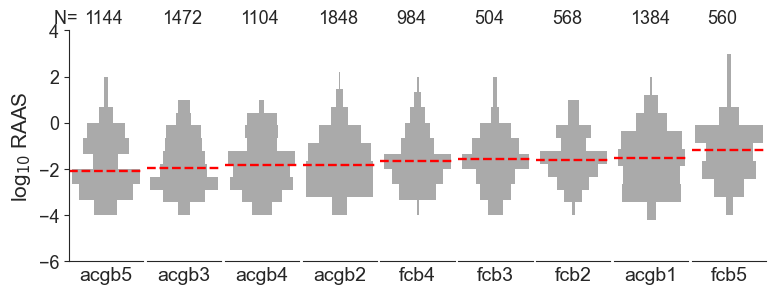

In [448]:
#RAAS distributions for shared SAAP (found in 6+ datasets)
fig,axes = plt.subplots(1,len(datasets),figsize=(len(datasets),3), sharey=True)
plt.subplots_adjust(wspace=0.05)

sns.set_style('ticks')
for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', bottom=False,labelbottom=False)
    if ax!=axes[0]:    
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)
        
# compute medians to sort datasets by
medians = [np.nanmedian(n6_saap_df.loc[n6_saap_df['Dataset']==ds,'Prec_RAAS'].values) for ds in datasets[:-1]]
med_sort_idx = list(np.argsort(medians))
med_sort_idx.append(max(med_sort_idx)+1)

# plot violin plots
for i,ds in enumerate(datasets):
    ax_idx = med_sort_idx.index(i)
    axes[ax_idx].set_xlabel(ds, fontsize=14)
    ratio_data = [x for x in n6_saap_df.loc[n6_saap_df['Dataset']==ds,'Prec_RAAS'].values if ~np.isnan(x) and ~np.isinf(x)]
    bihist(ratio_data, ratio_data, nbins=10,h=axes[ax_idx])
    if ax_idx==0:
        axes[ax_idx].annotate('N= ', (-0.2,1.03), xycoords='axes fraction', fontsize=13)

    axes[ax_idx].annotate(str(len(ratio_data)), (0.21,1.03), xycoords='axes fraction', fontsize=13)
    
    axes[ax_idx].plot(axes[ax_idx].get_xlim(), (np.median(ratio_data), np.median(ratio_data)), '--', color='red',linewidth=1.7)

axes[0].set_ylabel(r'log$_{10}$ RAAS', fontsize=15)
axes[0].tick_params('y',labelsize=13)
axes[0].set_yticks([-6,-4,-2,0,2,4]);

plt.savefig(PLOT_DIR+'Sample_level_RAAS_allDS_SharedSAAPin6.pdf', bbox_inches='tight')

# 4. Changes Associated with Disease